In [ ]:
import math
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA
import seaborn as sns # data visualization library  
import warnings
import time
# ignore all warnings
warnings.filterwarnings('ignore')

In [14]:
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/_deprecated_breast_cancer_wisconsin/_deprecated_breast_cancer_wisconsin.tsv.gz"
df = pd.read_csv(url, sep="\t", compression="gzip")
df.head()


,target,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
# rename columns to better understand the data
column_mapping = {
    'target': 'target',  
    '2': 'mean_radius',
    '3': 'mean_texture',
    '4': 'mean_perimeter',
    '5': 'mean_area',
    '6': 'mean_smoothness',
    '7': 'mean_compactness',
    '8': 'mean_concavity',
    '9': 'mean_concave_points',
    '10': 'mean_symmetry',
    '11': 'mean_fractal_dimension',
    '12': 'radius_error',
    '13': 'texture_error',
    '14': 'perimeter_error',
    '15': 'area_error',
    '16': 'smoothness_error',
    '17': 'compactness_error',
    '18': 'concavity_error',
    '19': 'concave_points_error',
    '20': 'symmetry_error',
    '21': 'fractal_dimension_error',
    '22': 'worst_radius',
    '23': 'worst_texture',
    '24': 'worst_perimeter',
    '25': 'worst_area',
    '26': 'worst_smoothness',
    '27': 'worst_compactness',
    '28': 'worst_concavity',
    '29': 'worst_concave_points',
    '30': 'worst_symmetry',
    '31': 'worst_fractal_dimension'
}

df_renamed = df.rename(columns=column_mapping)
df_renamed.head()

,target,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
data = df_renamed
# y includes our labels and x includes our features
y = data.target                          # M or B 
list = ['target']
x = data.drop(list,axis = 1 )
x.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Decision process using statistics

### 1. Skewness interpretation

**Skewness values:**
- **Skewness = 0**: Symmetric (ideal normal)
- **Skewness > 0**: Right-skewed (tail to the right)
- **Skewness < 0**: Left-skewed (tail to the left)

**Magnitude guidelines:**
- **|skewness| < 0.5**: Approximately symmetric
- **0.5 ≤ |skewness| < 1.0**: Slightly skewed
- **1.0 ≤ |skewness| < 2.0**: Moderately skewed
- **|skewness| ≥ 2.0**: Highly skewed

### 2. Decision logic

**Step 1: Check if binary**
- If only 2 unique values → **Bernoulli**
- Otherwise → continue

**Step 2: Check skewness**
- **|skewness| < 0.5** → Normal distribution (approximately symmetric)
- **|skewness| ≥ 0.5** → Normal distribution (right-skewed)

### 3. Why Normal even when skewed?

- **Uniform**: Flat/rectangular shape (not bell-shaped)
- **Bernoulli**: Discrete, only 2 values
- **Normal**: Continuous and bell-shaped (even if skewed)

Even if skewed, Normal is still the best match among these three.

### 4. Examples from your data

| Column | Skewness | Classification | Reason |
|--------|----------|----------------|--------|
| `mean_smoothness` | 0.46 | Normal (symmetric) | |skewness| < 0.5 |
| `mean_texture` | 0.65 | Normal (slightly right-skewed) | 0.5 ≤ skewness < 1.0 |
| `mean_area` | 1.64 | Normal (moderately right-skewed) | 1.0 ≤ skewness < 2.0 |
| `area_error` | 5.43 | Normal (highly right-skewed) | skewness ≥ 2.0 |

### 5. Your answer format

- **|skewness| < 0.5**: "Normal distribution (approximately symmetric)"
- **0.5 ≤ |skewness| < 1.0**: "Normal distribution (slightly right-skewed)"
- **|skewness| ≥ 1.0**: "Normal distribution (right-skewed)" or "Normal distribution (moderately/highly right-skewed)"

### Summary

1. Calculate skewness.
2. Use |skewness| < 0.5 to decide symmetric vs skewed.
3. All continuous columns are Normal (best match among the three options).
4. Skewness describes the shape, not the distribution type.

The key point: Normal is the distribution type; skewness describes how symmetric it is.

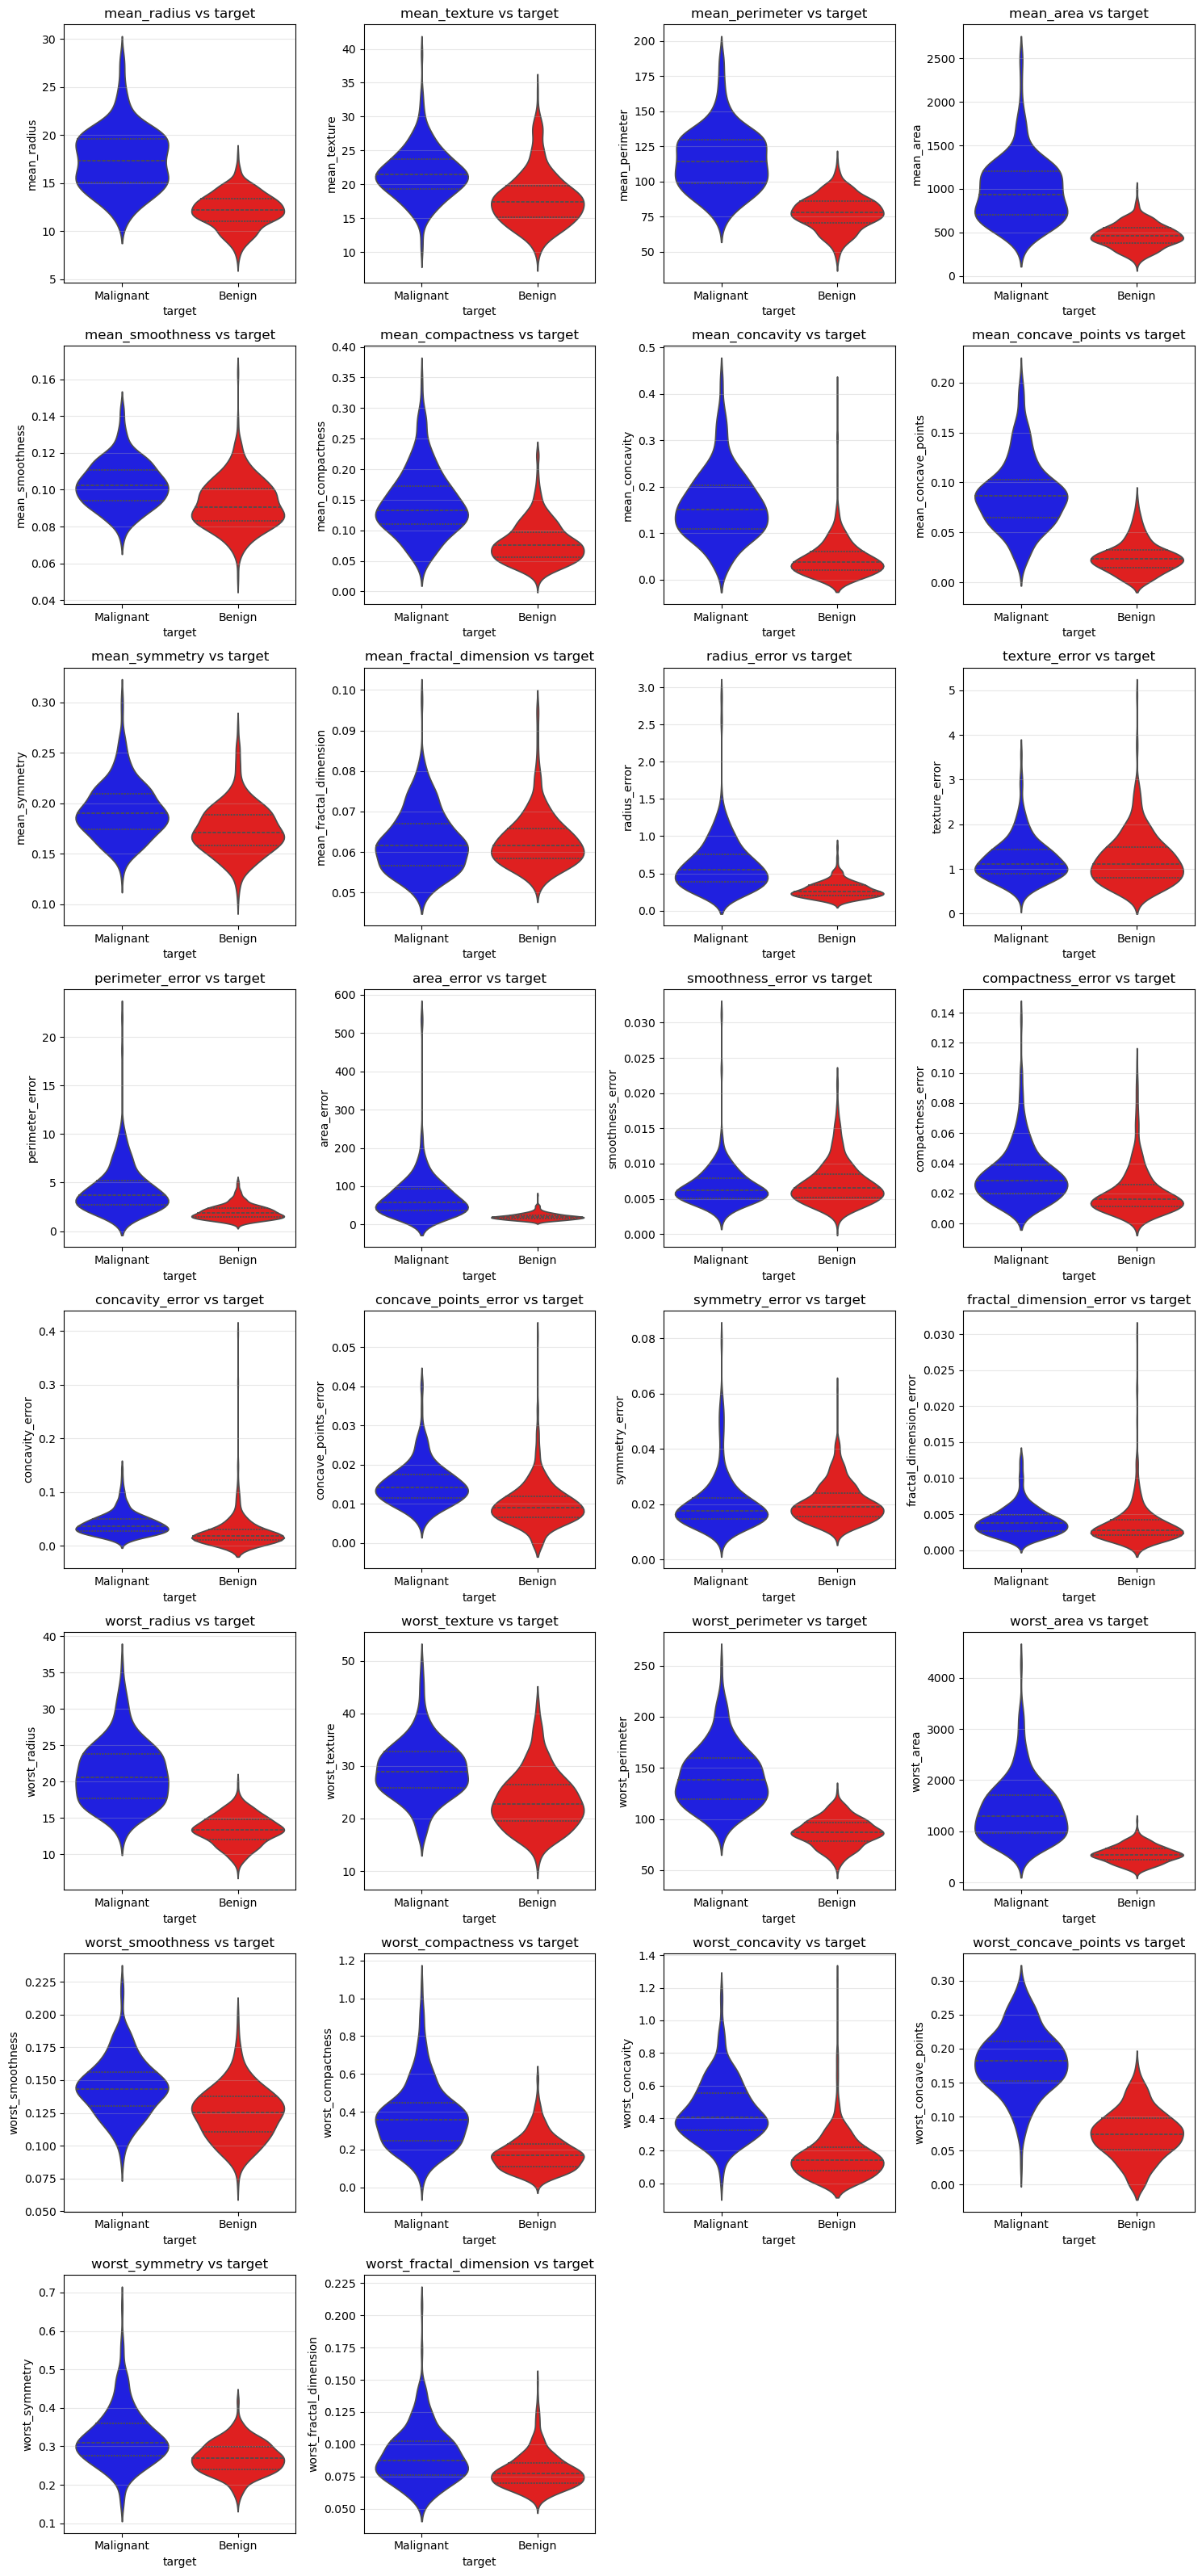

In [20]:
# YOUR CODE HERE
# Get all input columns (exclude target)
input_columns = [col for col in df_renamed.columns if col != 'target']

# Calculate number of subplots
num_inputs = len(input_columns)
n_cols = 4
n_rows = (num_inputs + n_cols - 1) // n_cols

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

# Plot each input column vs target using violin plots
for i, col in enumerate(input_columns):
    # Prepare data
    data = pd.DataFrame({
        'value': df_renamed[col],
        'target': df_renamed['target'].map({0: 'Benign', 1: 'Malignant'})
    })
    
    # Create violin plot
    sns.violinplot(x='target', y='value', data=data, ax=axes[i], 
                   palette=['blue', 'red'], inner='quart')
    
    axes[i].set_xlabel('target')
    axes[i].set_ylabel(col)
    axes[i].set_title(f'{col} vs target')
    axes[i].grid(True, alpha=0.3, axis='y')

# Hide unused subplots
for i in range(num_inputs, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

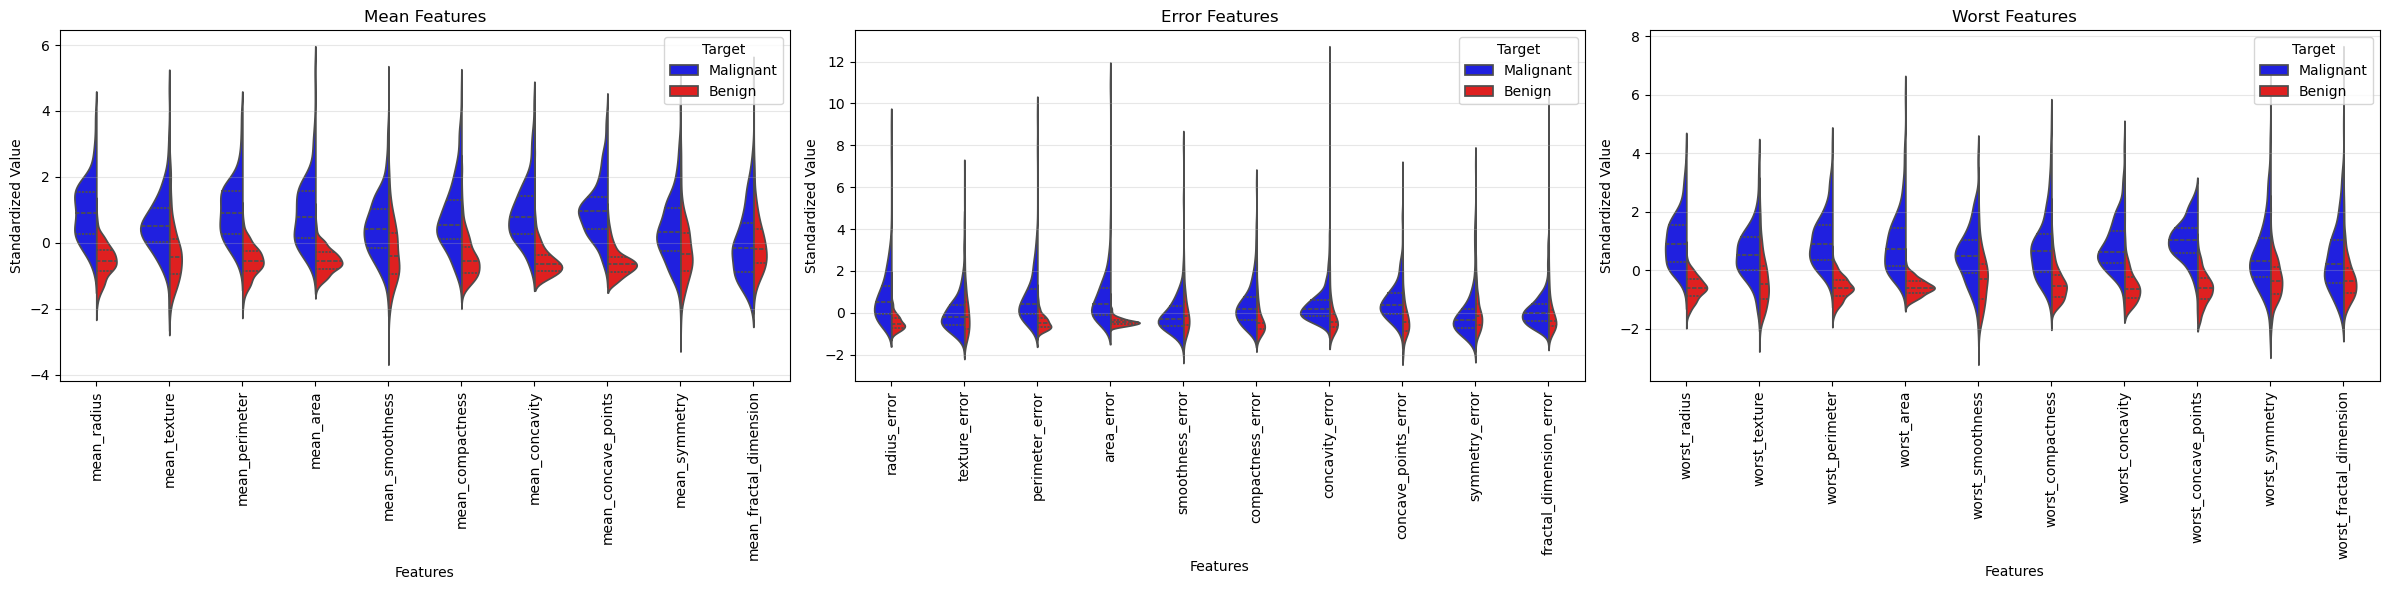

In [22]:
# YOUR CODE HERE
# Get all input columns (exclude target)
input_columns = [col for col in df_renamed.columns if col != 'target']

# Group features into categories
mean_features = [col for col in input_columns if col.startswith('mean_')]
error_features = [col for col in input_columns if col.endswith('_error')]
worst_features = [col for col in input_columns if col.startswith('worst_')]

# Create figure with 3 subplots (one for each group)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

groups = [
    (mean_features, 'Mean Features', axes[0]),
    (error_features, 'Error Features', axes[1]),
    (worst_features, 'Worst Features', axes[2])
]

for features, title, ax in groups:
    if not features:
        ax.axis('off')
        continue
    
    # Standardize the features
    data_standardized = (df_renamed[features] - df_renamed[features].mean()) / df_renamed[features].std()
    
    # Combine target with standardized features
    data = pd.concat([df_renamed[['target']], data_standardized], axis=1)
    
    # Melt data to long format
    data_melted = pd.melt(data, id_vars="target",
                          var_name="features",
                          value_name='value')
    
    # Map target to labels
    data_melted['target'] = data_melted['target'].map({0: 'Benign', 1: 'Malignant'})
    
    # Create violin plot
    sns.violinplot(x="features", y="value", hue="target", data=data_melted, 
                   split=True, inner="quart", palette=['blue', 'red'], ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel('Features')
    ax.set_ylabel('Standardized Value')
    ax.set_title(title)
    ax.legend(title='Target', loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

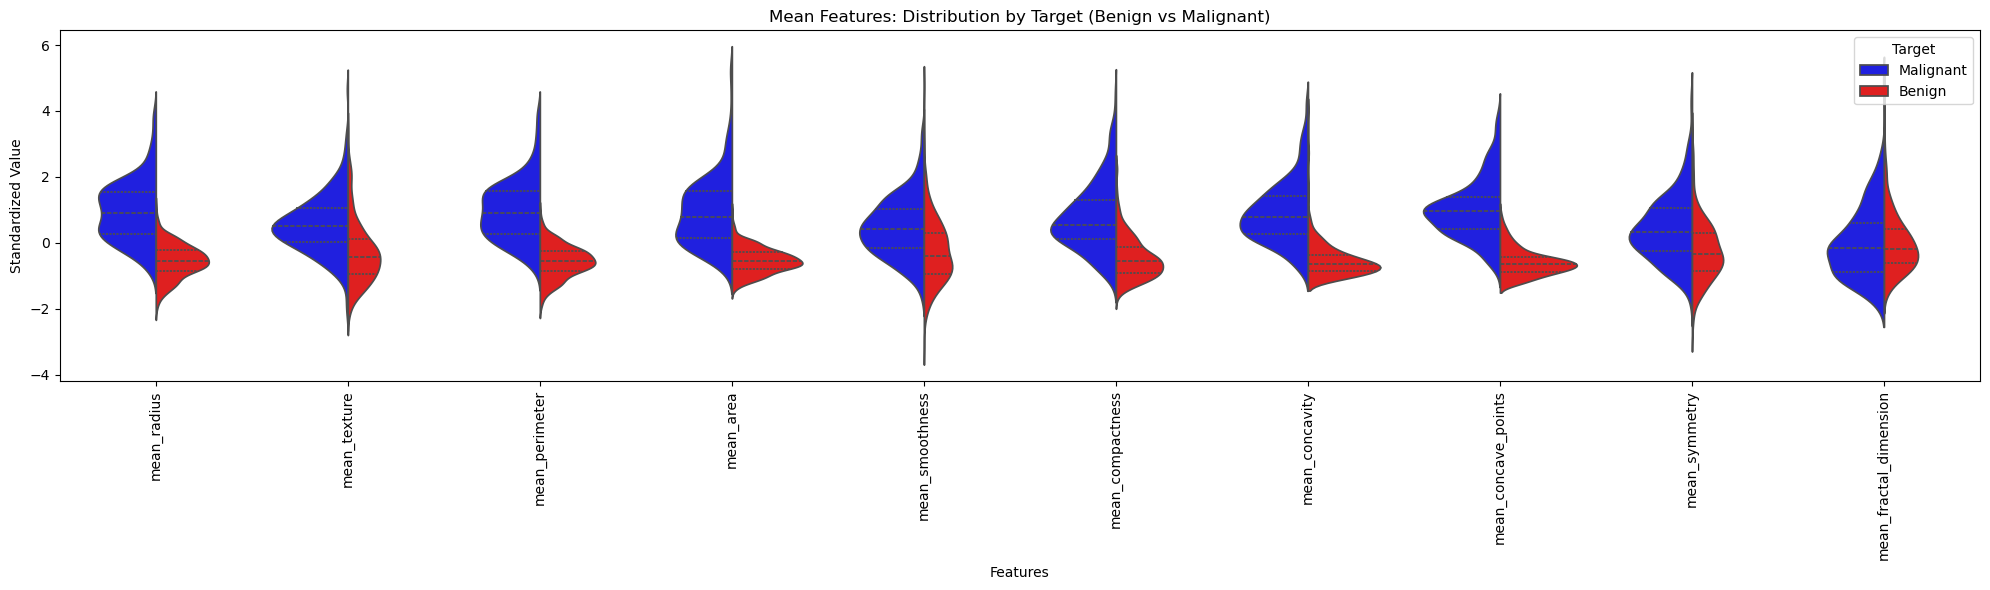

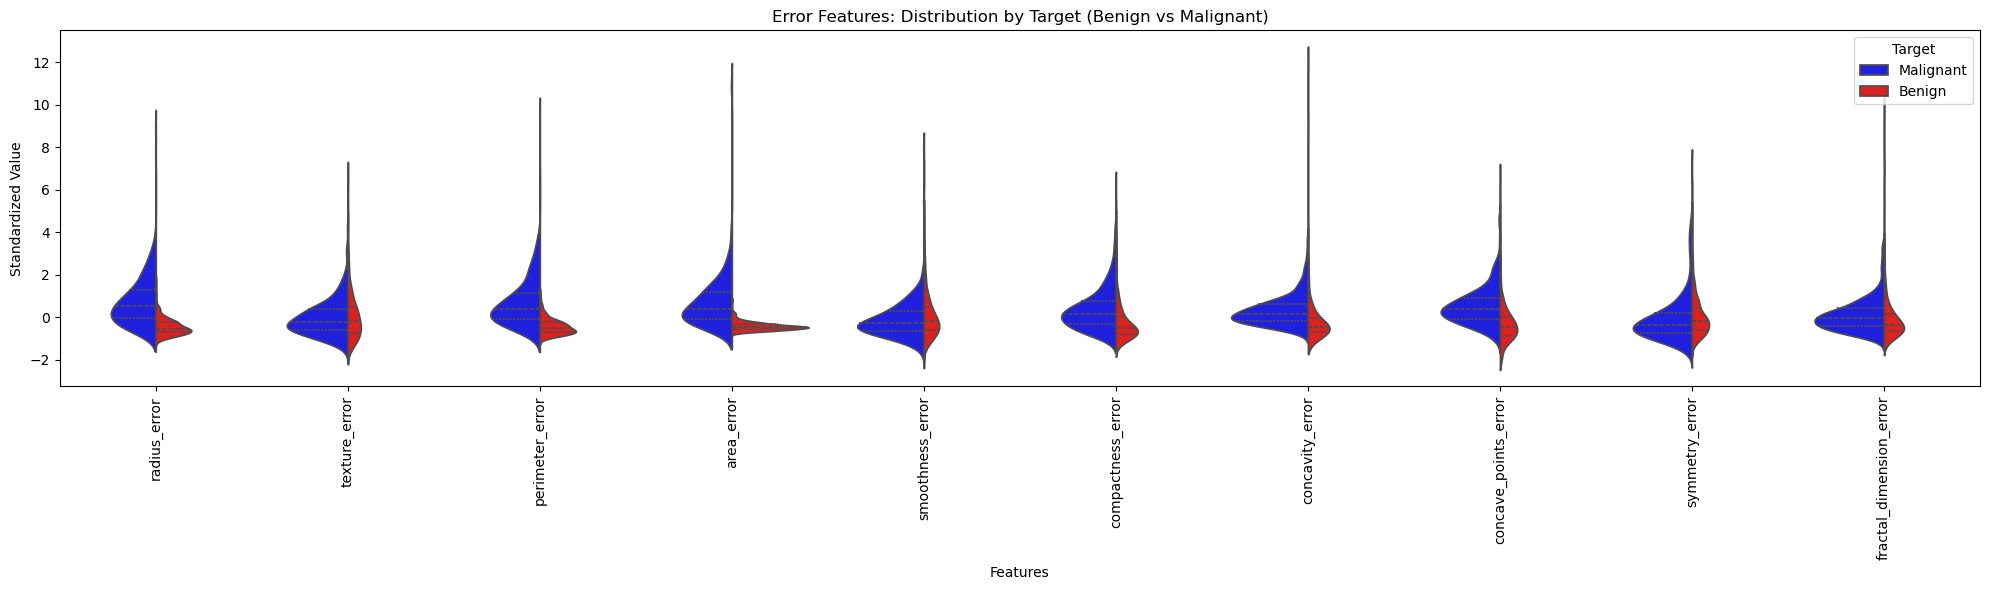

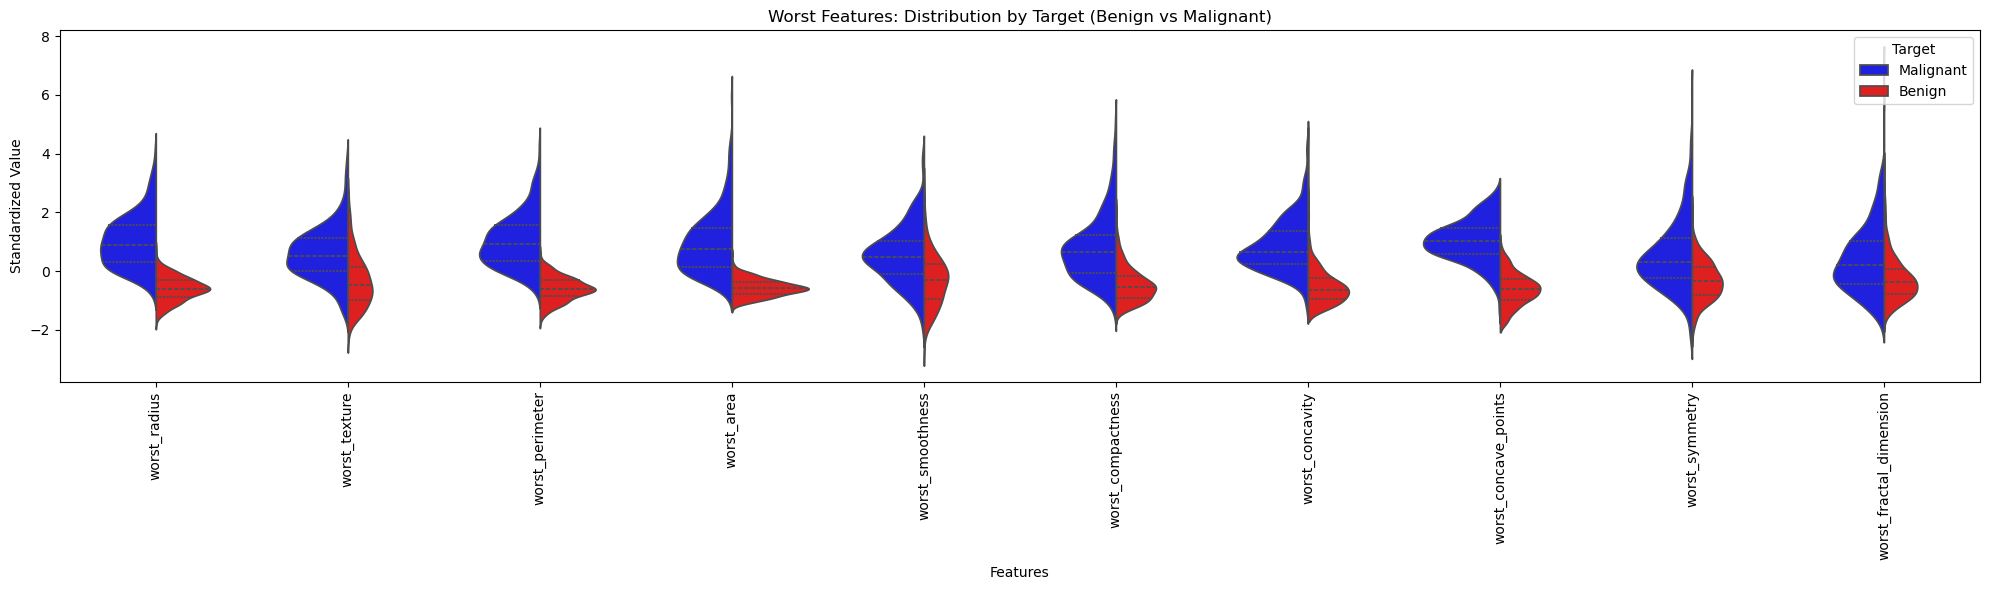

In [24]:
# YOUR CODE HERE
# Get all input columns (exclude target)
input_columns = [col for col in df_renamed.columns if col != 'target']

# Group features into categories
mean_features = [col for col in input_columns if col.startswith('mean_')]
error_features = [col for col in input_columns if col.endswith('_error')]
worst_features = [col for col in input_columns if col.startswith('worst_')]

# Standardize function
def standardize_and_plot(features, title):
    if not features:
        return
    
    # Standardize the features
    data_standardized = (df_renamed[features] - df_renamed[features].mean()) / df_renamed[features].std()
    
    # Combine target with standardized features
    data = pd.concat([df_renamed[['target']], data_standardized], axis=1)
    
    # Melt data to long format
    data_melted = pd.melt(data, id_vars="target",
                          var_name="features",
                          value_name='value')
    
    # Map target to labels
    data_melted['target'] = data_melted['target'].map({0: 'Benign', 1: 'Malignant'})
    
    # Create violin plot
    plt.figure(figsize=(20, 6))
    sns.violinplot(x="features", y="value", hue="target", data=data_melted, 
                   split=True, inner="quart", palette=['blue', 'red'])
    plt.xticks(rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Standardized Value')
    plt.title(f'{title} Features: Distribution by Target (Benign vs Malignant)')
    plt.legend(title='Target', loc='upper right')
    plt.tight_layout()
    plt.show()

# Plot each group
standardize_and_plot(mean_features, 'Mean')
standardize_and_plot(error_features, 'Error')
standardize_and_plot(worst_features, 'Worst')

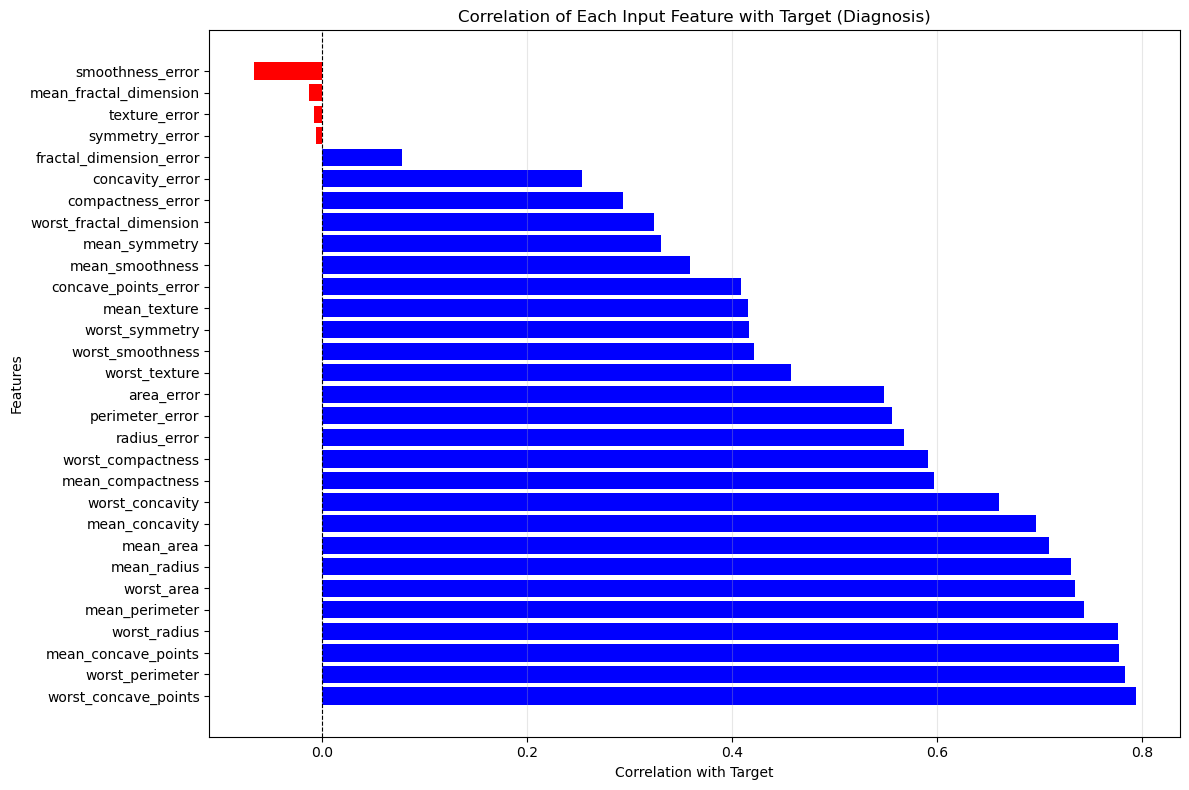

Correlation coefficients:
worst_concave_points          :  0.7936
worst_perimeter               :  0.7829
mean_concave_points           :  0.7766
worst_radius                  :  0.7765
mean_perimeter                :  0.7426
worst_area                    :  0.7338
mean_radius                   :  0.7300
mean_area                     :  0.7090
mean_concavity                :  0.6964
worst_concavity               :  0.6596
mean_compactness              :  0.5965
worst_compactness             :  0.5910
radius_error                  :  0.5671
perimeter_error               :  0.5561
area_error                    :  0.5482
worst_texture                 :  0.4569
worst_smoothness              :  0.4215
worst_symmetry                :  0.4163
mean_texture                  :  0.4152
concave_points_error          :  0.4080
mean_smoothness               :  0.3586
mean_symmetry                 :  0.3305
worst_fractal_dimension       :  0.3239
compactness_error             :  0.2930
concavity_erro

In [25]:
# Calculate correlation of each input column with target
input_columns = [col for col in df_renamed.columns if col != 'target']
correlations = df_renamed[input_columns].corrwith(df_renamed['target']).sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'blue' for x in correlations]
plt.barh(range(len(correlations)), correlations.values, color=colors)
plt.yticks(range(len(correlations)), correlations.index)
plt.xlabel('Correlation with Target')
plt.ylabel('Features')
plt.title('Correlation of Each Input Feature with Target (Diagnosis)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print correlation values
print("Correlation coefficients:")
for col, corr in correlations.items():
    print(f"{col:30s}: {corr:7.4f}")

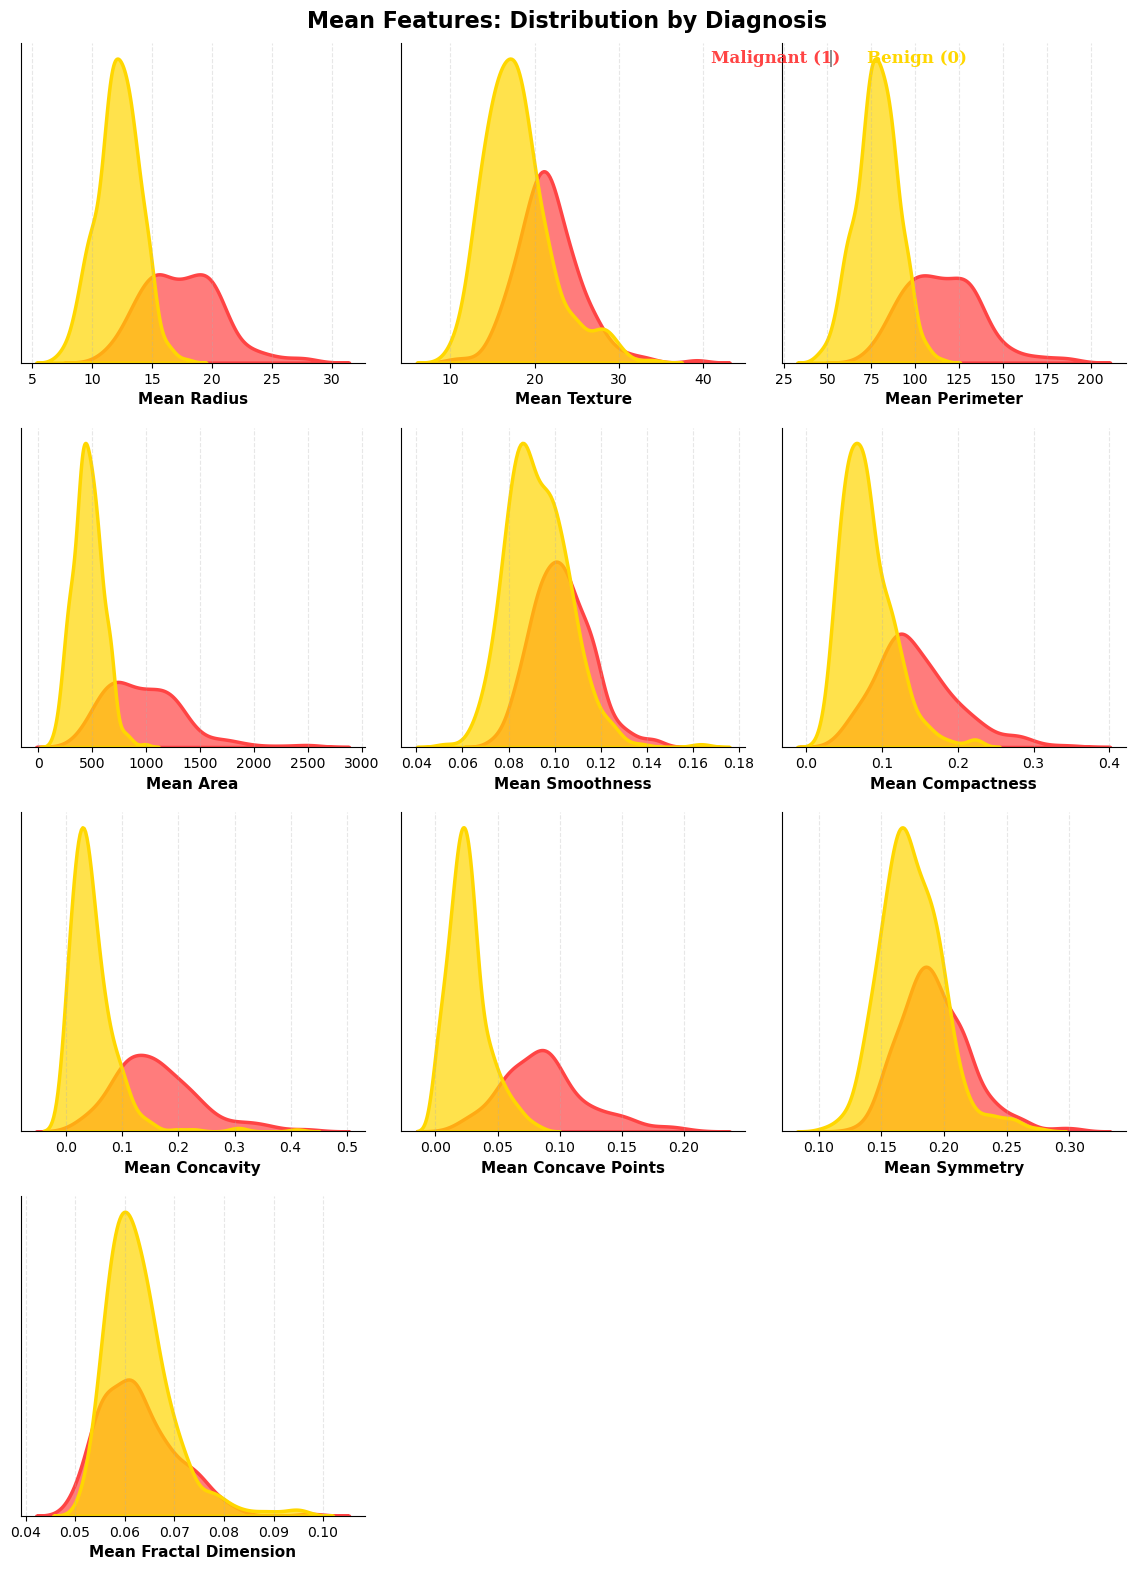

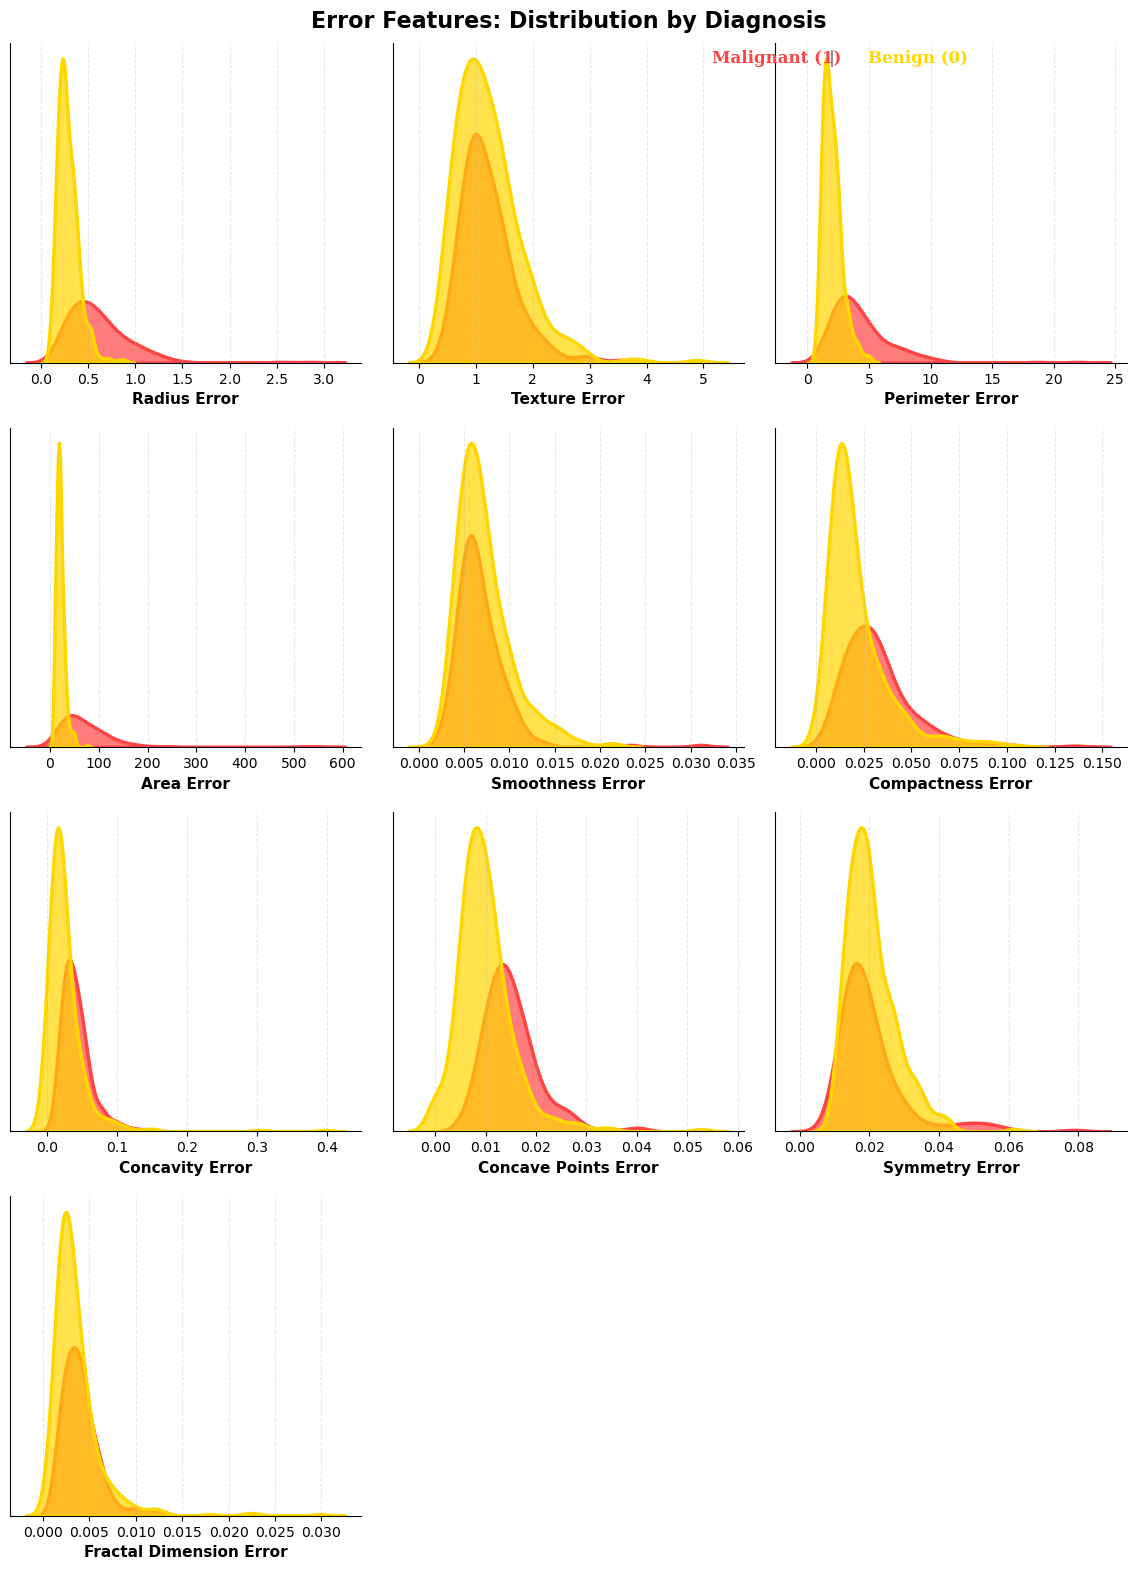

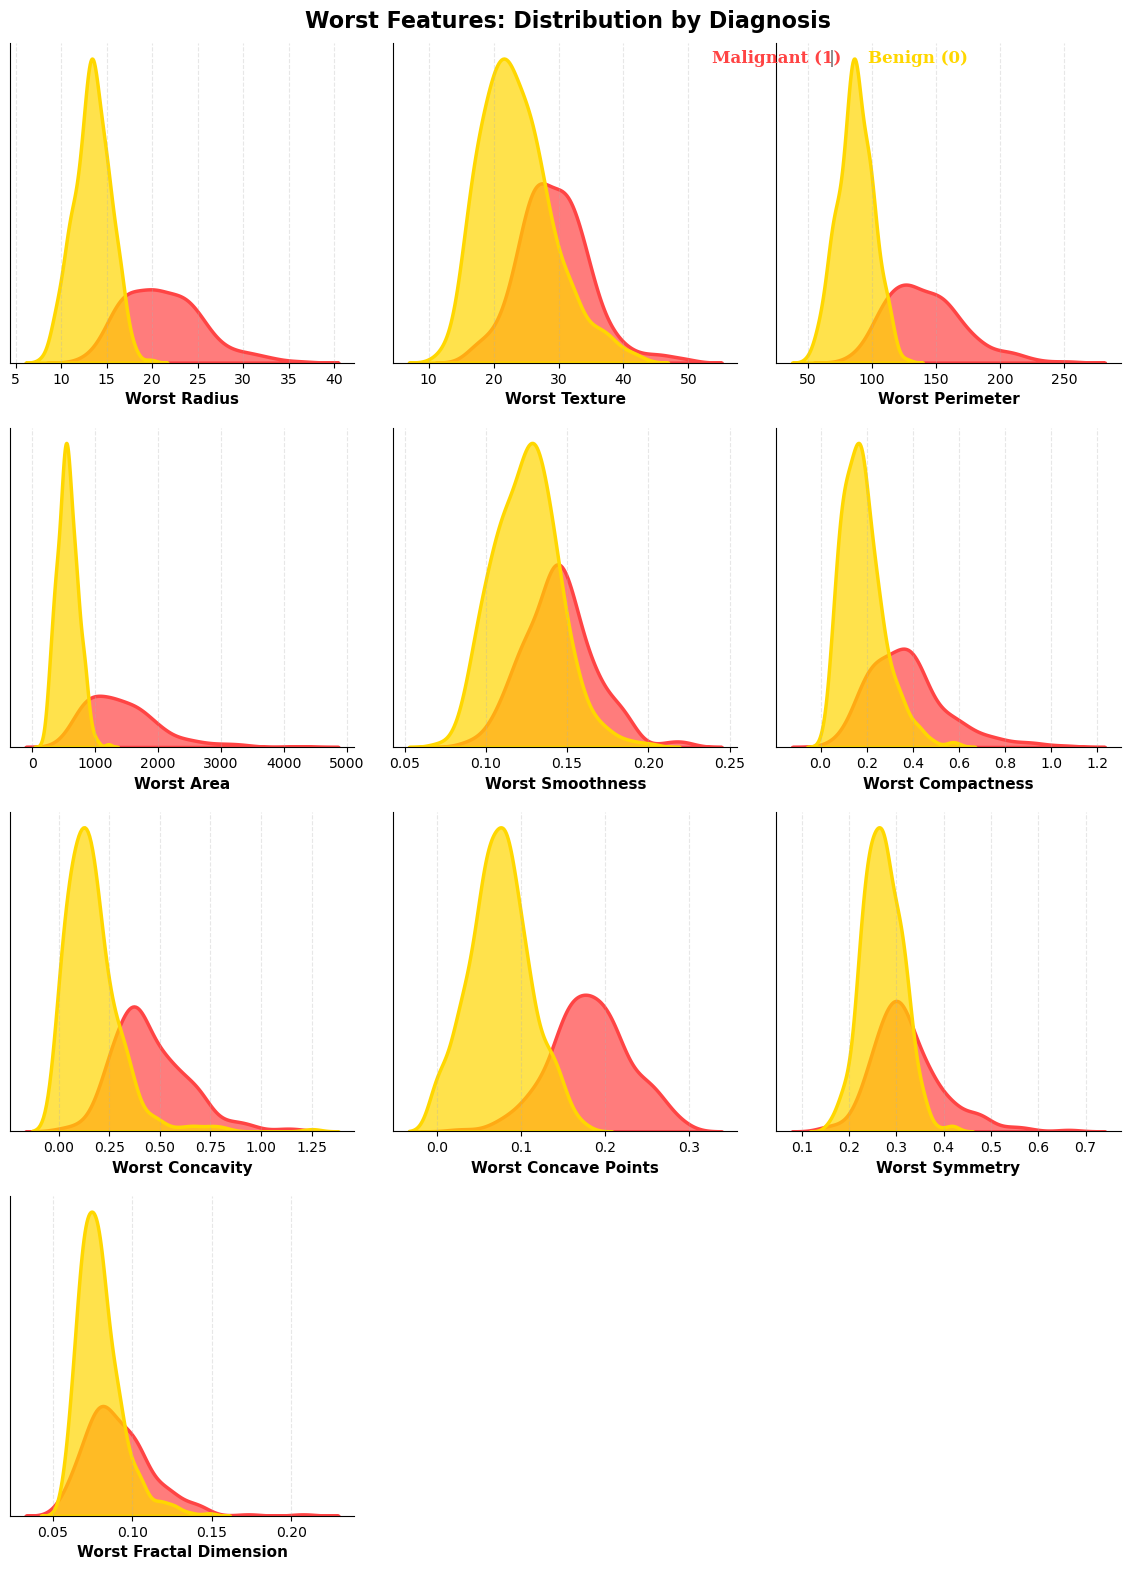

In [28]:
# YOUR CODE HERE
# Get all input columns (exclude target)
input_columns = [col for col in df_renamed.columns if col != 'target']

# Group features
mean_features = [col for col in input_columns if col.startswith('mean_')]
error_features = [col for col in input_columns if col.endswith('_error')]
worst_features = [col for col in input_columns if col.startswith('worst_')]

feature_groups = [
    ('Mean Features', mean_features),
    ('Error Features', error_features),
    ('Worst Features', worst_features)
]

# Nice color scheme: Yellow for benign, Red for malignant
colors = ['#FF4444', '#FFD700']  # Red for malignant (1), Gold/Yellow for benign (0)

for group_name, features in feature_groups:
    if not features:
        continue
    
    n_cols = 3
    n_rows = (len(features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4*n_rows), dpi=100)
    axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes.ravel()
    
    for col, ax in zip(features, axes):
        sns.kdeplot(data=df_renamed, x=col, hue='target', 
                    palette={0: colors[1], 1: colors[0]},  # 0=benign (yellow), 1=malignant (red)
                    ax=ax, fill=True, alpha=0.7, linewidth=2.5)
        xlabel = ' '.join([value.capitalize() for value in str(col).split('_')])
        ax.set_xlabel(xlabel, fontsize=11, weight='bold')
        ax.set_ylabel('Density', fontsize=11)
        ax.axes.get_yaxis().set_visible(False)
        ax.grid(True, alpha=0.3, axis='x', linestyle='--')
        ax.legend_.remove()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Hide unused subplots
    for i in range(len(features), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout(pad=3, h_pad=1.5, w_pad=1.5)
    
    # Add title and legend
    fig.suptitle(f'{group_name}: Distribution by Diagnosis', 
                 fontsize=16, weight='bold', y=0.995)
    
    # Add legend at the top
    fig.text(0.62, 0.97, "Malignant (1)", 
             {'font': 'serif', 'size': 12, 'weight': 'bold', 'color': colors[0]}, 
             ha='left', va='top')
    fig.text(0.72, 0.97, '|', {'font': 'serif', 'size': 12, 'weight': 'bold', 'color': 'gray'}, 
             ha='center', va='top')
    fig.text(0.75, 0.97, "Benign (0)", 
             {'font': 'serif', 'size': 12, 'weight': 'bold', 'color': colors[1]}, 
             ha='left', va='top')
    
    plt.show()

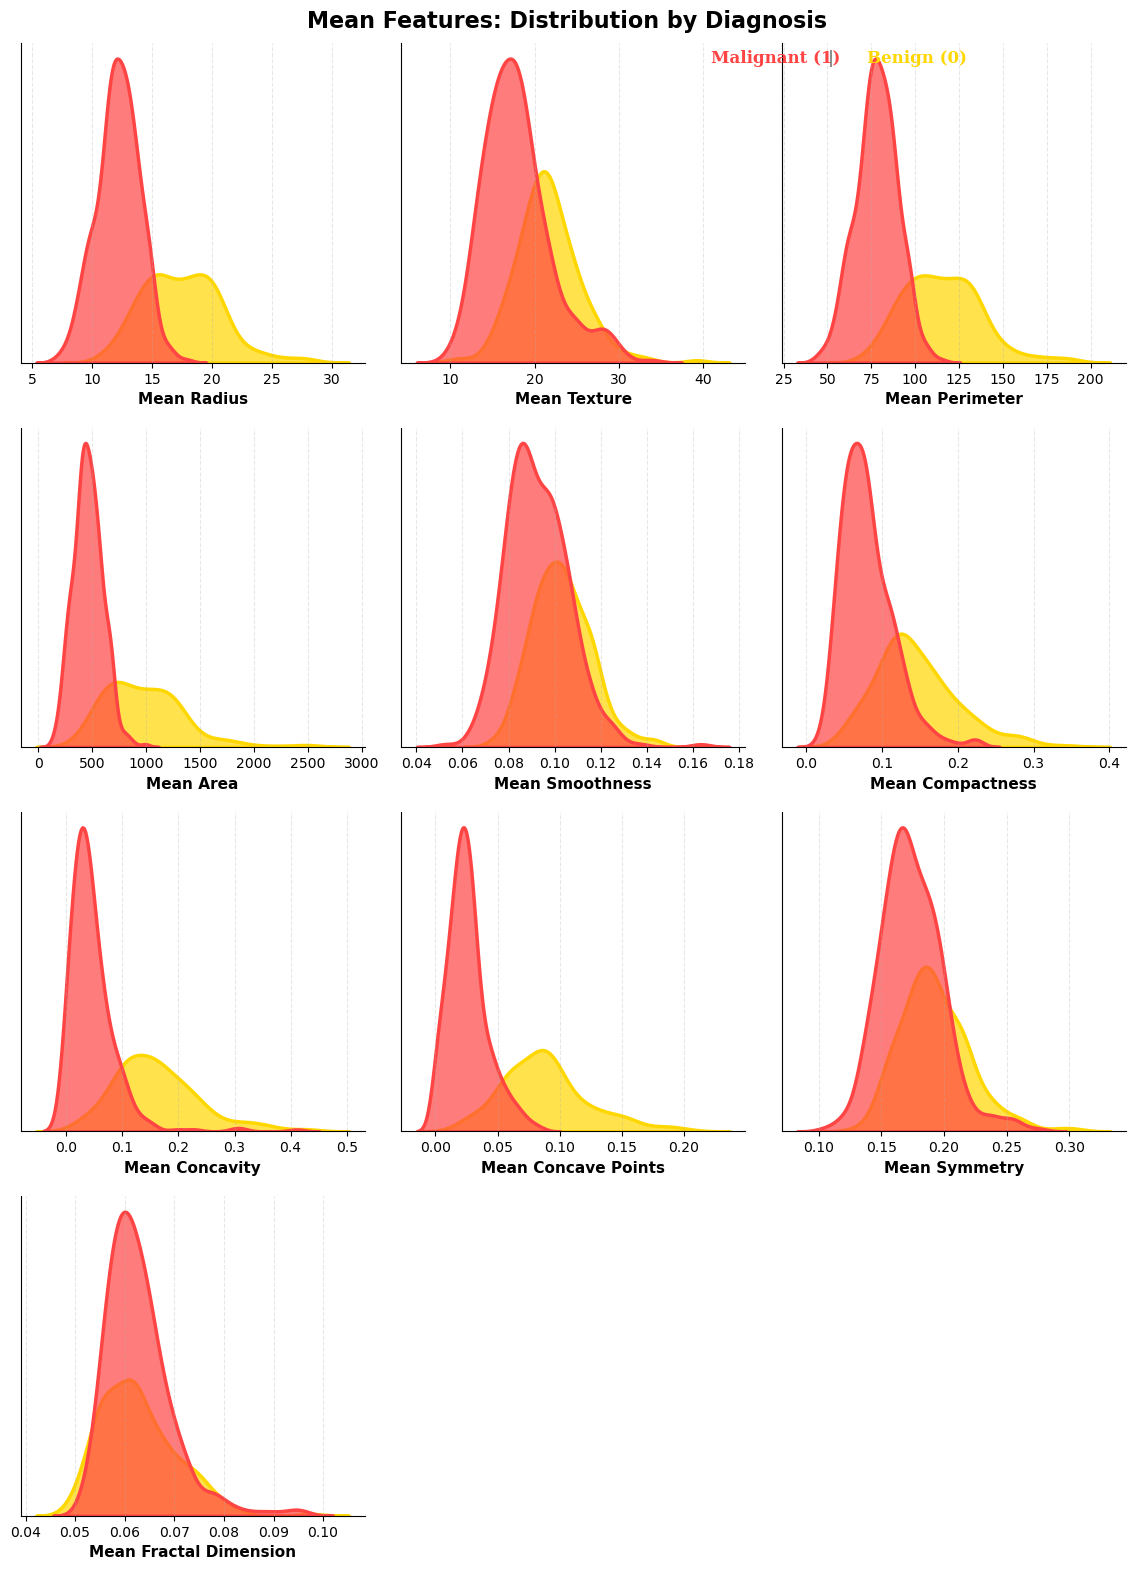

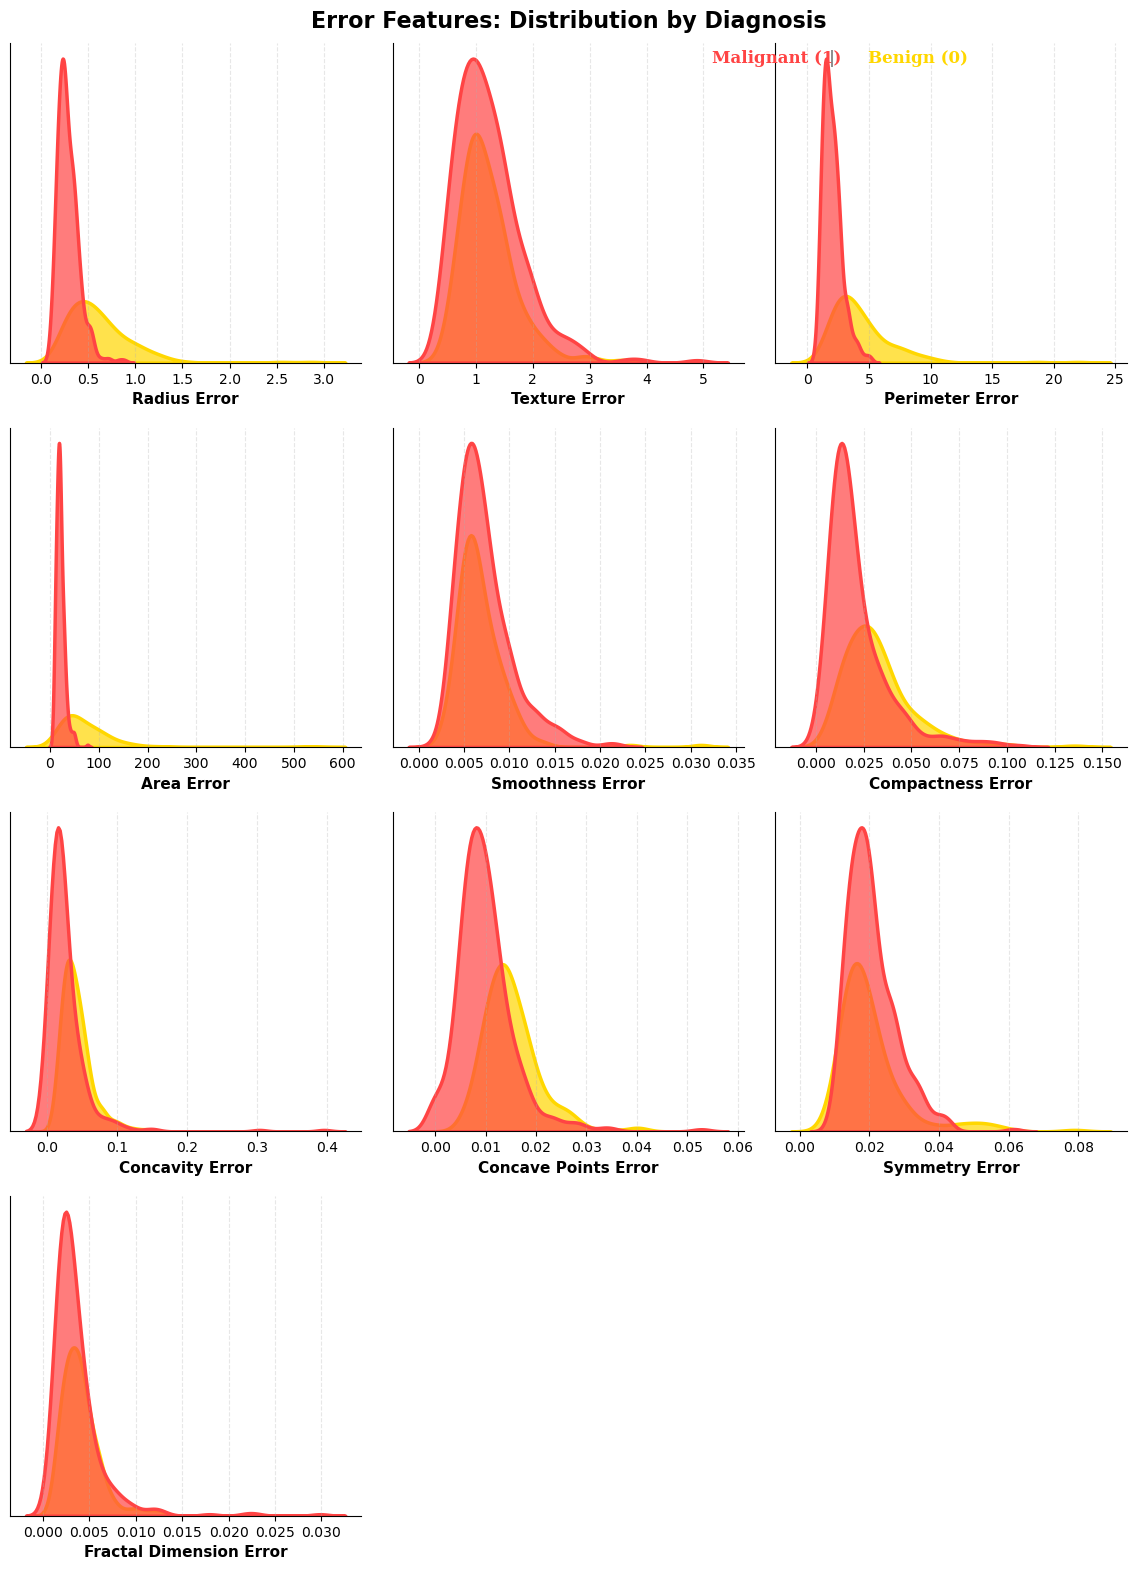

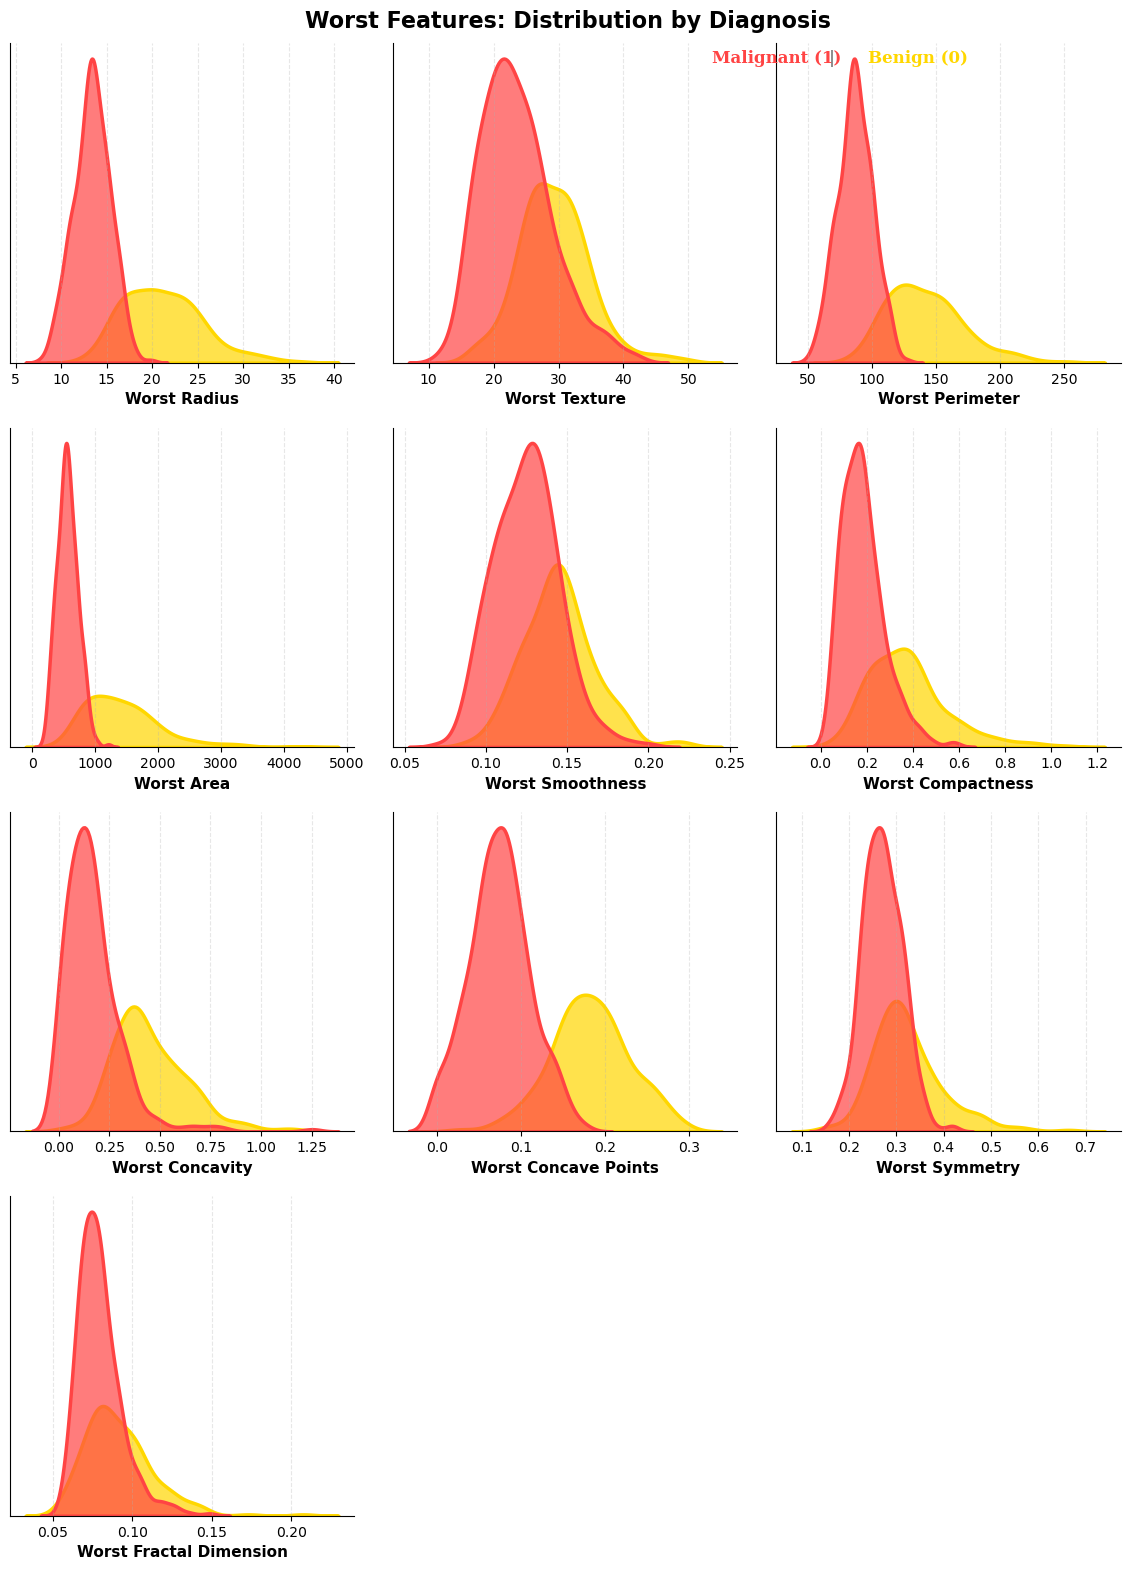

In [30]:
# YOUR CODE HERE
# Get all input columns (exclude target)
input_columns = [col for col in df_renamed.columns if col != 'target']

# Group features
mean_features = [col for col in input_columns if col.startswith('mean_')]
error_features = [col for col in input_columns if col.endswith('_error')]
worst_features = [col for col in input_columns if col.startswith('worst_')]

feature_groups = [
    ('Mean Features', mean_features),
    ('Error Features', error_features),
    ('Worst Features', worst_features)
]

# Nice color scheme
colors = ['#FF4444', '#FFD700']  # Red for malignant, Gold/Yellow for benign

for group_name, features in feature_groups:
    if not features:
        continue
    
    n_cols = 3
    n_rows = (len(features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4*n_rows), dpi=100)
    axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes.ravel()
    
    for col, ax in zip(features, axes):
        # Use palette as a list instead of dictionary - seaborn will map automatically
        sns.kdeplot(data=df_renamed, x=col, hue='target', 
                    palette=colors,  # Just pass list, seaborn handles the mapping
                    ax=ax, fill=True, alpha=0.7, linewidth=2.5)
        xlabel = ' '.join([value.capitalize() for value in str(col).split('_')])
        ax.set_xlabel(xlabel, fontsize=11, weight='bold')
        ax.set_ylabel('Density', fontsize=11)
        ax.axes.get_yaxis().set_visible(False)
        ax.grid(True, alpha=0.3, axis='x', linestyle='--')
        ax.legend_.remove()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Hide unused subplots
    for i in range(len(features), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout(pad=3, h_pad=1.5, w_pad=1.5)
    
    # Add title and legend
    fig.suptitle(f'{group_name}: Distribution by Diagnosis', 
                 fontsize=16, weight='bold', y=0.995)
    
    # Add legend at the top
    fig.text(0.62, 0.97, "Malignant (1)", 
             {'font': 'serif', 'size': 12, 'weight': 'bold', 'color': colors[0]}, 
             ha='left', va='top')
    fig.text(0.72, 0.97, '|', {'font': 'serif', 'size': 12, 'weight': 'bold', 'color': 'gray'}, 
             ha='center', va='top')
    fig.text(0.75, 0.97, "Benign (0)", 
             {'font': 'serif', 'size': 12, 'weight': 'bold', 'color': colors[1]}, 
             ha='left', va='top')
    
    plt.show()

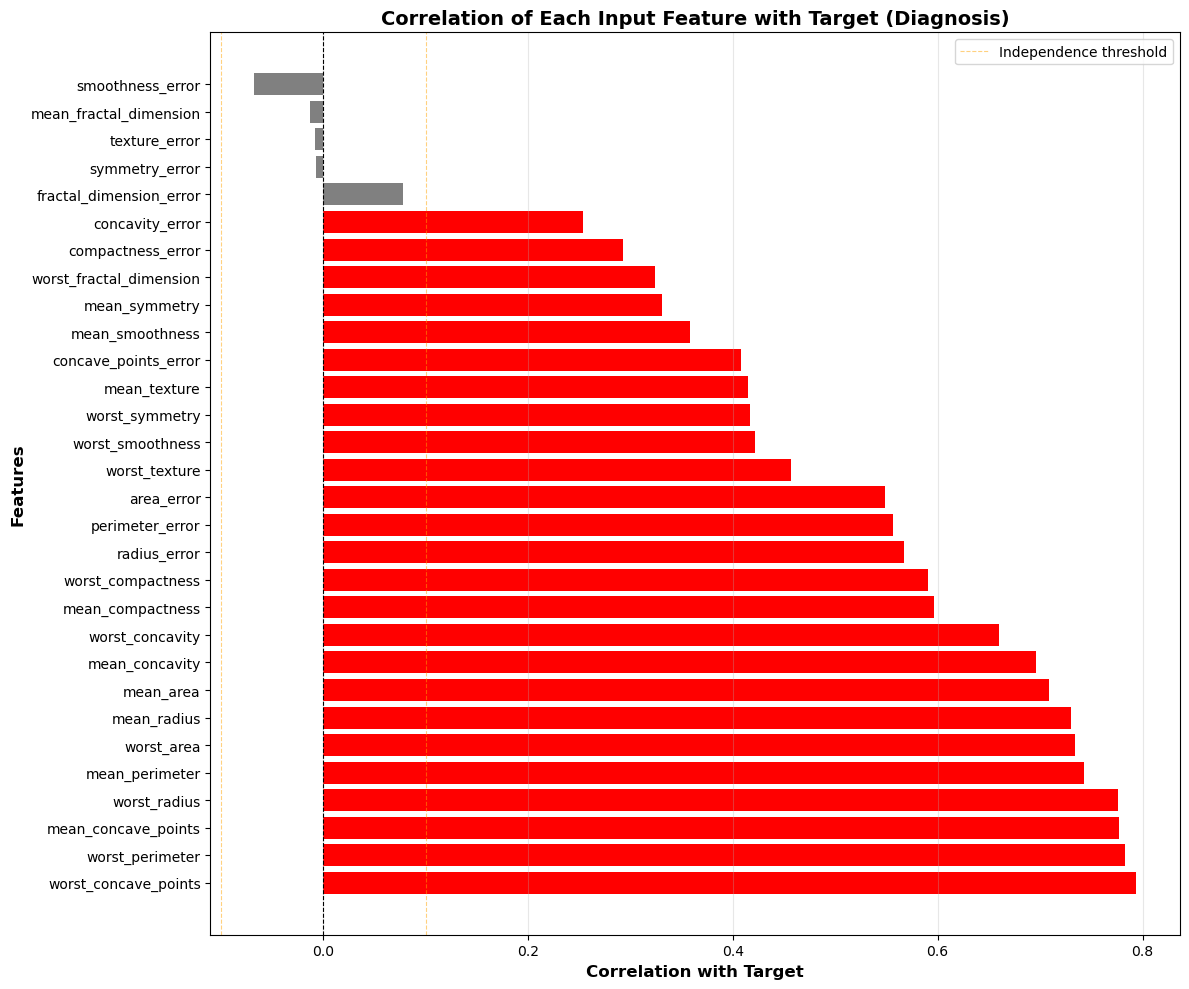

Correlation Analysis:
worst_concave_points          :  0.7936 -> NOT Independent
worst_perimeter               :  0.7829 -> NOT Independent
mean_concave_points           :  0.7766 -> NOT Independent
worst_radius                  :  0.7765 -> NOT Independent
mean_perimeter                :  0.7426 -> NOT Independent
worst_area                    :  0.7338 -> NOT Independent
mean_radius                   :  0.7300 -> NOT Independent
mean_area                     :  0.7090 -> NOT Independent
mean_concavity                :  0.6964 -> NOT Independent
worst_concavity               :  0.6596 -> NOT Independent
mean_compactness              :  0.5965 -> NOT Independent
worst_compactness             :  0.5910 -> NOT Independent
radius_error                  :  0.5671 -> NOT Independent
perimeter_error               :  0.5561 -> NOT Independent
area_error                    :  0.5482 -> NOT Independent
worst_texture                 :  0.4569 -> NOT Independent
worst_smoothness              :  0

In [31]:
# Calculate and visualize correlations
input_columns = [col for col in df_renamed.columns if col != 'target']
correlations = df_renamed[input_columns].corrwith(df_renamed['target']).sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(12, 10))
colors_bar = ['red' if abs(x) > 0.1 else 'gray' for x in correlations.values]
plt.barh(range(len(correlations)), correlations.values, color=colors_bar)
plt.yticks(range(len(correlations)), correlations.index)
plt.xlabel('Correlation with Target', fontsize=12, weight='bold')
plt.ylabel('Features', fontsize=12, weight='bold')
plt.title('Correlation of Each Input Feature with Target (Diagnosis)', 
          fontsize=14, weight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=0.1, color='orange', linestyle='--', linewidth=0.8, alpha=0.5, label='Independence threshold')
plt.axvline(x=-0.1, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print correlation table
print("Correlation Analysis:")
print("=" * 70)
for col, corr in correlations.items():
    status = "NOT Independent" if abs(corr) > 0.1 else "Independent"
    print(f"{col:30s}: {corr:7.4f} -> {status}")

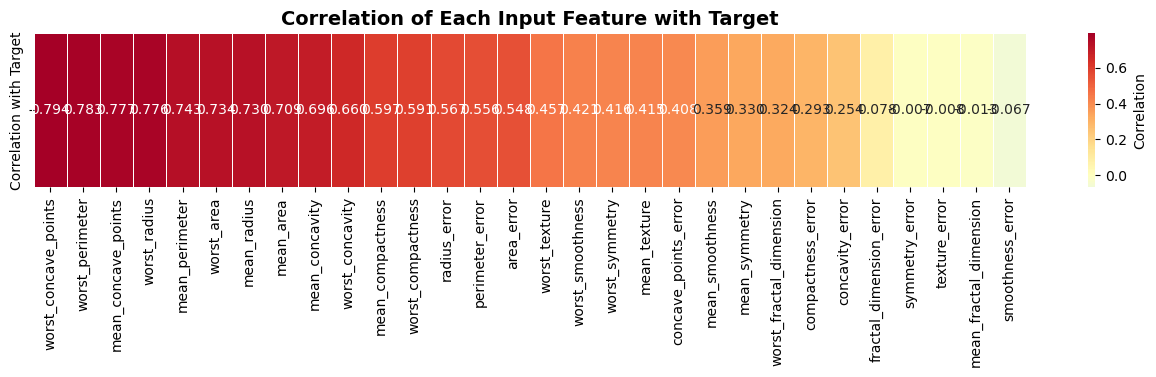

In [32]:
# Calculate correlations
input_columns = [col for col in df_renamed.columns if col != 'target']
correlations = df_renamed[input_columns].corrwith(df_renamed['target']).sort_values(ascending=False)

# Create heatmap (single row)
corr_matrix = correlations.values.reshape(1, -1)
fig, ax = plt.subplots(figsize=(16, 2))
sns.heatmap(corr_matrix, 
            xticklabels=correlations.index,
            yticklabels=['Correlation with Target'],
            annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            cbar_kws={"label": "Correlation"}, linewidths=0.5)
plt.xticks(rotation=90)
plt.title('Correlation of Each Input Feature with Target', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Calculate correlations
input_columns = [col for col in df_renamed.columns if col != 'target']
correlations = df_renamed[input_columns].corrwith(df_renamed['target']).sort_values(ascending=False)

# Create DataFrame with classification
corr_df = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    'Absolute Correlation': correlations.abs().values,
    'Independence Status': ['NOT Independent' if abs(corr) > 0.1 else 'Independent' 
                           for corr in correlations.values]
})

# Display
print("Correlation Analysis: Input Features vs Target")
print("=" * 80)
display(corr_df)

# Summary statistics
print("\nSummary:")
print(f"Total features: {len(corr_df)}")
print(f"Independent (|corr| < 0.1): {sum(corr_df['Independence Status'] == 'Independent')}")
print(f"NOT Independent (|corr| ≥ 0.1): {sum(corr_df['Independence Status'] == 'NOT Independent')}")

Correlation Analysis: Input Features vs Target


,Feature,Correlation,Absolute Correlation,Independence Status
0,worst_concave_points,0.793566,0.793566,NOT Independent
1,worst_perimeter,0.782914,0.782914,NOT Independent
2,mean_concave_points,0.776614,0.776614,NOT Independent
3,worst_radius,0.776454,0.776454,NOT Independent
4,mean_perimeter,0.742636,0.742636,NOT Independent
5,worst_area,0.733825,0.733825,NOT Independent
6,mean_radius,0.730029,0.730029,NOT Independent
7,mean_area,0.708984,0.708984,NOT Independent
8,mean_concavity,0.696360,0.696360,NOT Independent
9,worst_concavity,0.659610,0.659610,NOT Independent



Summary:
Total features: 30
Independent (|corr| < 0.1): 5
NOT Independent (|corr| ≥ 0.1): 25


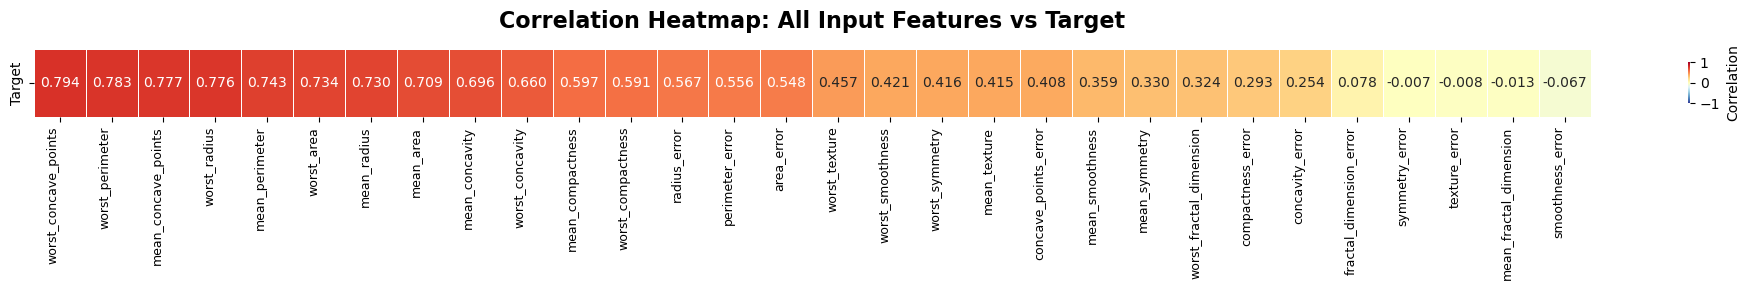


MEAN FEATURES


,Feature,Correlation,|Corr|,Status
0,mean_concave_points,0.7766,0.7766,NOT Independent
1,mean_perimeter,0.7426,0.7426,NOT Independent
2,mean_radius,0.7300,0.7300,NOT Independent
3,mean_area,0.7090,0.7090,NOT Independent
4,mean_concavity,0.6964,0.6964,NOT Independent
5,mean_compactness,0.5965,0.5965,NOT Independent
6,mean_texture,0.4152,0.4152,NOT Independent
7,mean_smoothness,0.3586,0.3586,NOT Independent
8,mean_symmetry,0.3305,0.3305,NOT Independent
9,mean_fractal_dimension,-0.0128,0.0128,Independent


Summary: 1 Independent, 9 NOT Independent


ERROR FEATURES


,Feature,Correlation,|Corr|,Status
0,radius_error,0.5671,0.5671,NOT Independent
1,perimeter_error,0.5561,0.5561,NOT Independent
2,area_error,0.5482,0.5482,NOT Independent
3,concave_points_error,0.4080,0.4080,NOT Independent
4,compactness_error,0.2930,0.2930,NOT Independent
5,concavity_error,0.2537,0.2537,NOT Independent
6,fractal_dimension_error,0.0780,0.0780,Independent
7,symmetry_error,-0.0065,0.0065,Independent
8,texture_error,-0.0083,0.0083,Independent
9,smoothness_error,-0.0670,0.0670,Independent


Summary: 4 Independent, 6 NOT Independent


WORST FEATURES


,Feature,Correlation,|Corr|,Status
0,worst_concave_points,0.7936,0.7936,NOT Independent
1,worst_perimeter,0.7829,0.7829,NOT Independent
2,worst_radius,0.7765,0.7765,NOT Independent
3,worst_area,0.7338,0.7338,NOT Independent
4,worst_concavity,0.6596,0.6596,NOT Independent
5,worst_compactness,0.5910,0.5910,NOT Independent
6,worst_texture,0.4569,0.4569,NOT Independent
7,worst_smoothness,0.4215,0.4215,NOT Independent
8,worst_symmetry,0.4163,0.4163,NOT Independent
9,worst_fractal_dimension,0.3239,0.3239,NOT Independent


Summary: 0 Independent, 10 NOT Independent



In [36]:
# Calculate correlations
input_columns = [col for col in df_renamed.columns if col != 'target']
correlations = df_renamed[input_columns].corrwith(df_renamed['target'])

# Group features
mean_features = [col for col in input_columns if col.startswith('mean_')]
error_features = [col for col in input_columns if col.endswith('_error')]
worst_features = [col for col in input_columns if col.startswith('worst_')]

feature_groups = [
    ('Mean Features', mean_features),
    ('Error Features', error_features),
    ('Worst Features', worst_features)
]

# 1. HEATMAP
corr_sorted = correlations.sort_values(ascending=False)
corr_matrix = corr_sorted.values.reshape(1, -1)
fig, ax = plt.subplots(figsize=(20, 3))
sns.heatmap(corr_matrix, 
            xticklabels=corr_sorted.index,
            yticklabels=['Target'],
            annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            cbar_kws={"label": "Correlation", "shrink": 0.6}, 
            linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.title('Correlation Heatmap: All Input Features vs Target', 
          fontsize=16, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# 2. GROUPED TABLES
for group_name, features in feature_groups:
    if not features:
        continue
    
    group_corr = correlations[features].sort_values(ascending=False)
    group_df = pd.DataFrame({
        'Feature': group_corr.index,
        'Correlation': group_corr.values,
        '|Corr|': group_corr.abs().values,
        'Status': ['NOT Independent' if abs(c) > 0.1 else 'Independent' for c in group_corr.values]
    })
    
    print(f"\n{'='*80}")
    print(f"{group_name.upper()}")
    print('='*80)
    display(group_df.style.format({
        'Correlation': '{:.4f}',
        '|Corr|': '{:.4f}'
    }).background_gradient(subset=['Correlation'], cmap='RdYlBu_r', vmin=-1, vmax=1))
    
    # Quick summary
    indep = sum(group_df['Status'] == 'Independent')
    not_indep = sum(group_df['Status'] == 'NOT Independent')
    print(f"Summary: {indep} Independent, {not_indep} NOT Independent\n")

Mean Squared Error: 0.052755


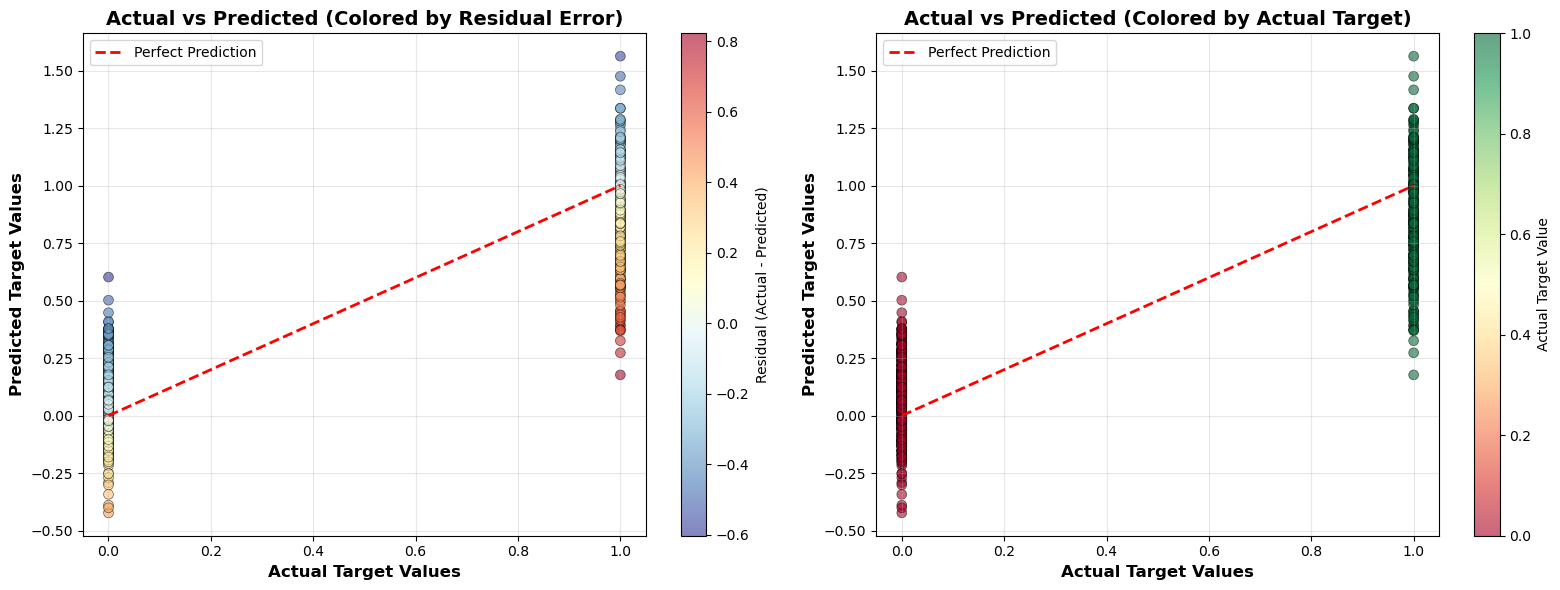


Model Statistics:
  Mean Squared Error: 0.052755
  Root Mean Squared Error: 0.229685
  Mean Absolute Error: 0.180576
  R² Score: 0.774325

Actual Target Range: [0.0, 1.0]
Predicted Target Range: [-0.423, 1.563]


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Prepare data
X = df_renamed.drop('target', axis=1)  # All input columns
y = df_renamed['target']  # Output column

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse:.6f}")

# Calculate residuals (error) for color coding
residuals = y - y_pred

# Create the plot with color coding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Color by residuals (error magnitude)
scatter1 = ax1.scatter(y, y_pred, c=residuals, cmap='RdYlBu_r', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Target Values', fontsize=12, weight='bold')
ax1.set_ylabel('Predicted Target Values', fontsize=12, weight='bold')
ax1.set_title('Actual vs Predicted (Colored by Residual Error)', fontsize=14, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Residual (Actual - Predicted)')

# Plot 2: Color by actual target value
scatter2 = ax2.scatter(y, y_pred, c=y, cmap='RdYlGn', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Target Values', fontsize=12, weight='bold')
ax2.set_ylabel('Predicted Target Values', fontsize=12, weight='bold')
ax2.set_title('Actual vs Predicted (Colored by Actual Target)', fontsize=14, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Actual Target Value')

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\nModel Statistics:")
print(f"  Mean Squared Error: {mse:.6f}")
print(f"  Root Mean Squared Error: {np.sqrt(mse):.6f}")
print(f"  Mean Absolute Error: {np.mean(np.abs(residuals)):.6f}")
print(f"  R² Score: {model.score(X, y):.6f}")
print(f"\nActual Target Range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Predicted Target Range: [{y_pred.min():.3f}, {y_pred.max():.3f}]")

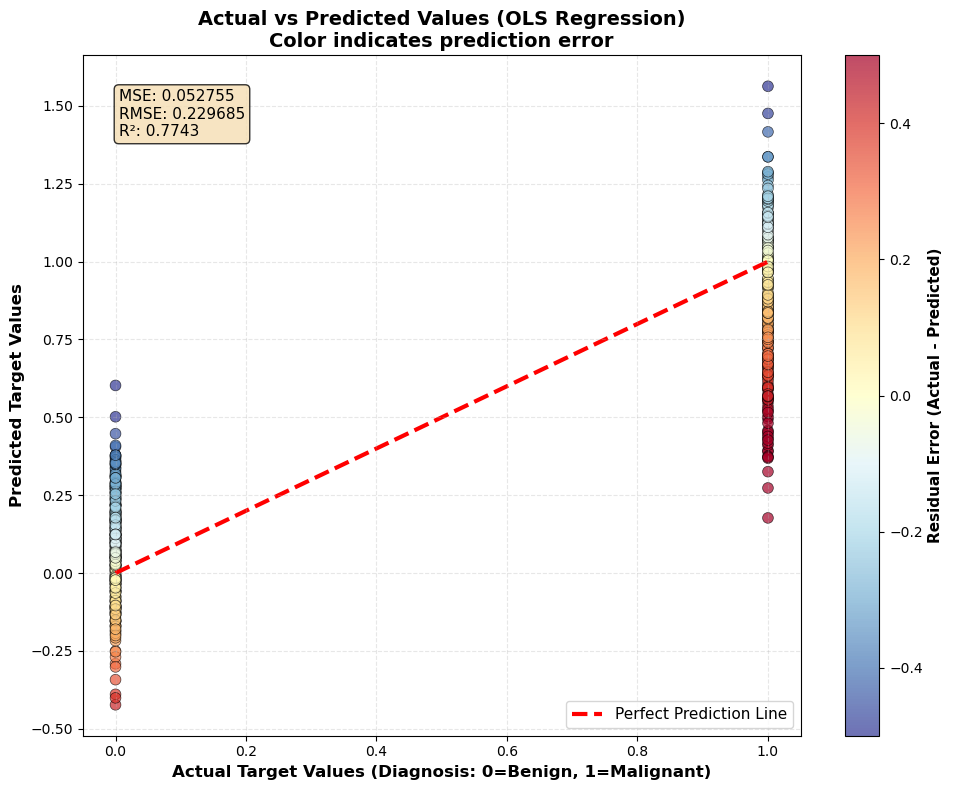

Mean Squared Error: 0.052755
Root Mean Squared Error: 0.229685
R² Score: 0.774325


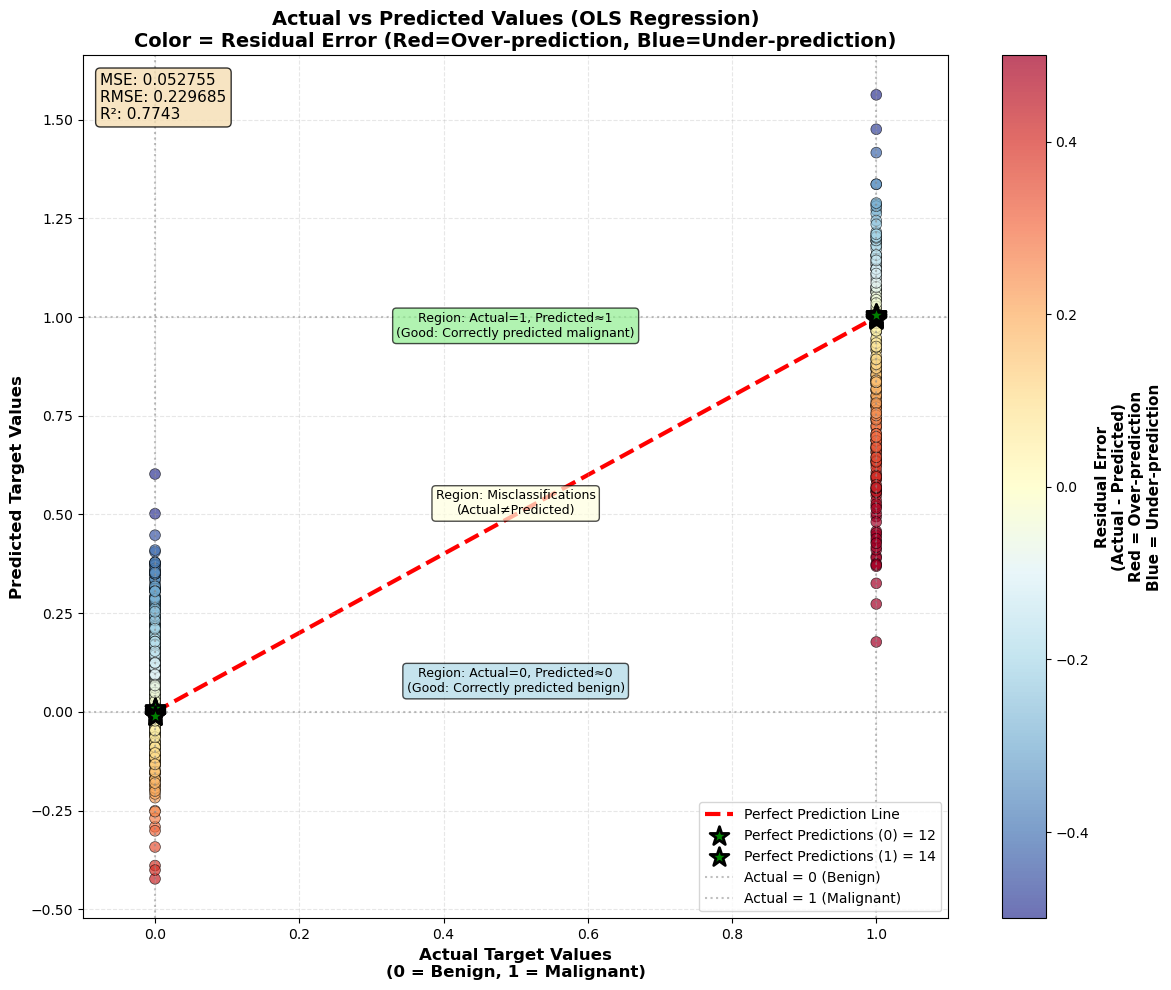

UNDERSTANDING THE PLOT

1. PERFECT PREDICTIONS:
   - For Actual=0 (Benign): Perfect prediction is at (0, 0)
   - For Actual=1 (Malignant): Perfect prediction is at (1, 1)
   - Green stars (*) mark points very close to perfect predictions
   - Perfect predictions for 0: 12 points
   - Perfect predictions for 1: 14 points

2. COLOR CODING (Residual Error = Actual - Predicted):
   - RED/YELLOW colors: Over-prediction (Predicted > Actual)
     → Model predicted higher value than actual
   - BLUE colors: Under-prediction (Predicted < Actual)
     → Model predicted lower value than actual
   - WHITE/YELLOW (near center): Small error (good predictions)

3. REGIONS:
   - Bottom-left (Actual≈0, Predicted≈0): Correctly predicted benign
   - Top-right (Actual≈1, Predicted≈1): Correctly predicted malignant
   - Bottom-right (Actual=0, Predicted>0.5): False positive (predicted malignant, actually benign)
   - Top-left (Actual=1, Predicted<0.5): False negative (predicted benign, actually malignant)


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Prepare data
X = df_renamed.drop('target', axis=1)
y = df_renamed['target']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
residuals = y - y_pred

# Create enhanced plot with better explanations
fig, ax = plt.subplots(figsize=(12, 10))

# Color code by residual magnitude
scatter = ax.scatter(y, y_pred, c=residuals, cmap='RdYlBu_r', 
                     alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                     vmin=-0.5, vmax=0.5)

# Perfect prediction line (red dashed line)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, 
        label='Perfect Prediction Line', zorder=1)

# Mark perfect prediction points explicitly
# For binary classification, perfect predictions are at (0,0) and (1,1)
perfect_0 = (y == 0) & (np.abs(y_pred - 0) < 0.01)  # Points near (0,0)
perfect_1 = (y == 1) & (np.abs(y_pred - 1) < 0.01)  # Points near (1,1)

if perfect_0.sum() > 0:
    ax.scatter(y[perfect_0], y_pred[perfect_0], c='green', s=200, 
               marker='*', edgecolors='black', linewidth=2, 
               label=f'Perfect Predictions (0) = {perfect_0.sum()}', zorder=3)

if perfect_1.sum() > 0:
    ax.scatter(y[perfect_1], y_pred[perfect_1], c='green', s=200, 
               marker='*', edgecolors='black', linewidth=2, 
               label=f'Perfect Predictions (1) = {perfect_1.sum()}', zorder=3)

# Add annotations for key regions
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Actual = 0 (Benign)')
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5, label='Actual = 1 (Malignant)')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

# Add text boxes explaining regions
ax.text(0.5, 0.05, 'Region: Actual=0, Predicted≈0\n(Good: Correctly predicted benign)', 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
        ha='center', fontsize=9)
ax.text(0.5, 0.95, 'Region: Actual=1, Predicted≈1\n(Good: Correctly predicted malignant)', 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        ha='center', fontsize=9)
ax.text(0.5, 0.5, 'Region: Misclassifications\n(Actual≠Predicted)', 
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
        ha='center', fontsize=9)

# Statistics box
stats_text = f'MSE: {mse:.6f}\nRMSE: {np.sqrt(mse):.6f}\nR²: {model.score(X, y):.4f}'
ax.text(0.02, 0.98, stats_text,
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Actual Target Values\n(0 = Benign, 1 = Malignant)', 
              fontsize=12, weight='bold')
ax.set_ylabel('Predicted Target Values', fontsize=12, weight='bold')
ax.set_title('Actual vs Predicted Values (OLS Regression)\n' + 
             'Color = Residual Error (Red=Over-prediction, Blue=Under-prediction)', 
             fontsize=14, weight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([y_pred.min()-0.1, y_pred.max()+0.1])

# Colorbar with explanation
cbar = plt.colorbar(scatter, ax=ax, label='Residual Error')
cbar.ax.set_ylabel('Residual Error\n(Actual - Predicted)\n' +
                   'Red = Over-prediction\nBlue = Under-prediction', 
                   fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# Print detailed explanation
print("=" * 80)
print("UNDERSTANDING THE PLOT")
print("=" * 80)
print("\n1. PERFECT PREDICTIONS:")
print("   - For Actual=0 (Benign): Perfect prediction is at (0, 0)")
print("   - For Actual=1 (Malignant): Perfect prediction is at (1, 1)")
print("   - Green stars (*) mark points very close to perfect predictions")
print(f"   - Perfect predictions for 0: {perfect_0.sum()} points")
print(f"   - Perfect predictions for 1: {perfect_1.sum()} points")

print("\n2. COLOR CODING (Residual Error = Actual - Predicted):")
print("   - RED/YELLOW colors: Over-prediction (Predicted > Actual)")
print("     → Model predicted higher value than actual")
print("   - BLUE colors: Under-prediction (Predicted < Actual)")
print("     → Model predicted lower value than actual")
print("   - WHITE/YELLOW (near center): Small error (good predictions)")

print("\n3. REGIONS:")
print("   - Bottom-left (Actual≈0, Predicted≈0): Correctly predicted benign")
print("   - Top-right (Actual≈1, Predicted≈1): Correctly predicted malignant")
print("   - Bottom-right (Actual=0, Predicted>0.5): False positive (predicted malignant, actually benign)")
print("   - Top-left (Actual=1, Predicted<0.5): False negative (predicted benign, actually malignant)")

print("\n4. THE RED DASHED LINE:")
print("   - This is the 'Perfect Prediction Line'")
print("   - Points ON this line have: Predicted = Actual")
print("   - For binary classification, perfect points are at (0,0) and (1,1)")
print("   - Points close to this line = good predictions")
print("   - Points far from this line = poor predictions")

print("\n5. STATISTICS:")
print(f"   - Mean Squared Error: {mse:.6f}")
print(f"   - Root Mean Squared Error: {np.sqrt(mse):.6f}")
print(f"   - R² Score: {model.score(X, y):.4f}")
print("=" * 80)

PROBLEM 6: Finding Best Single-Feature Model

Best Single-Feature Model:
  Feature: worst_concave_points
  MSE: 0.086552
  R²: 0.629747

Problem 5 Model (All Features):
  MSE: 0.052755
  R²: 0.774325

Comparison:
  MSE Improvement: -64.06%
  (Lower is better - single feature is -64.06% worse)

Top 5 Single-Feature Models:
--------------------------------------------------------------------------------
Rank   Feature                                      MSE         R²
--------------------------------------------------------------------------------
28     worst_concave_points                    0.086552     0.6297
23     worst_perimeter                         0.090478     0.6130
8      mean_concave_points                     0.092775     0.6031
21     worst_radius                            0.092833     0.6029
3      mean_perimeter                          0.104842     0.5515


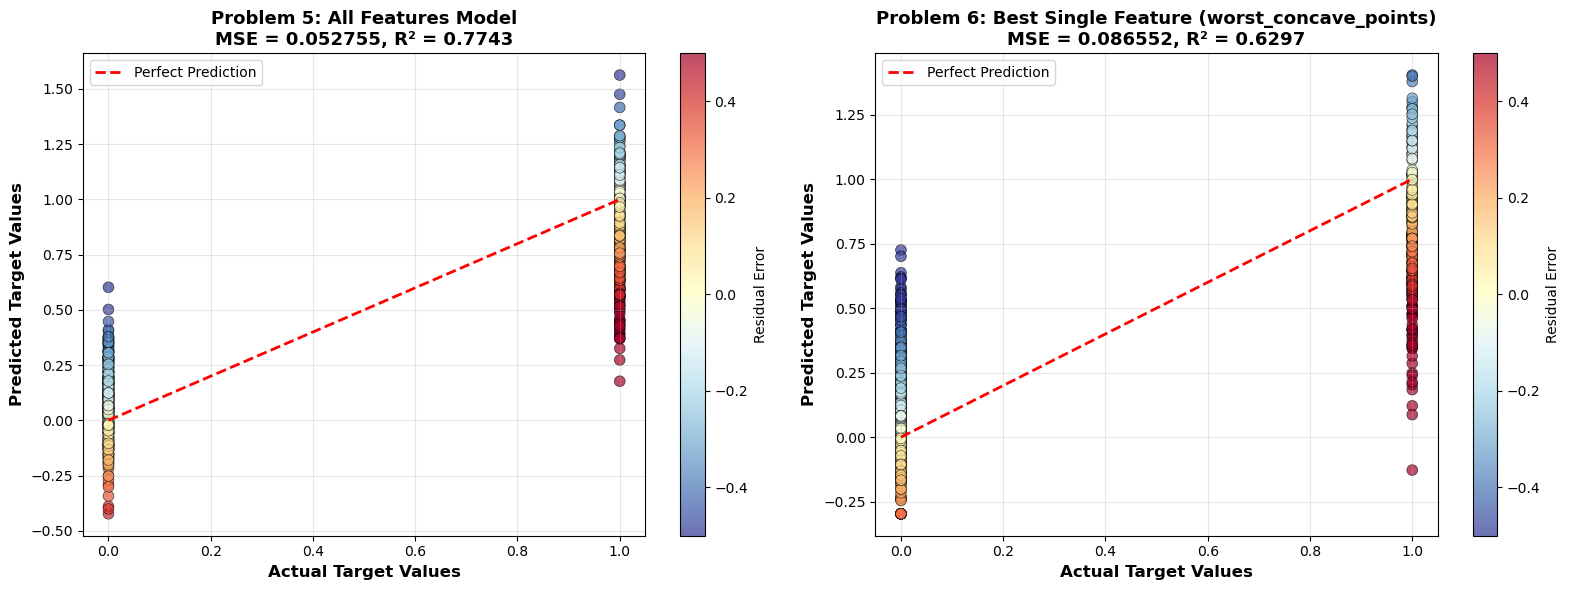

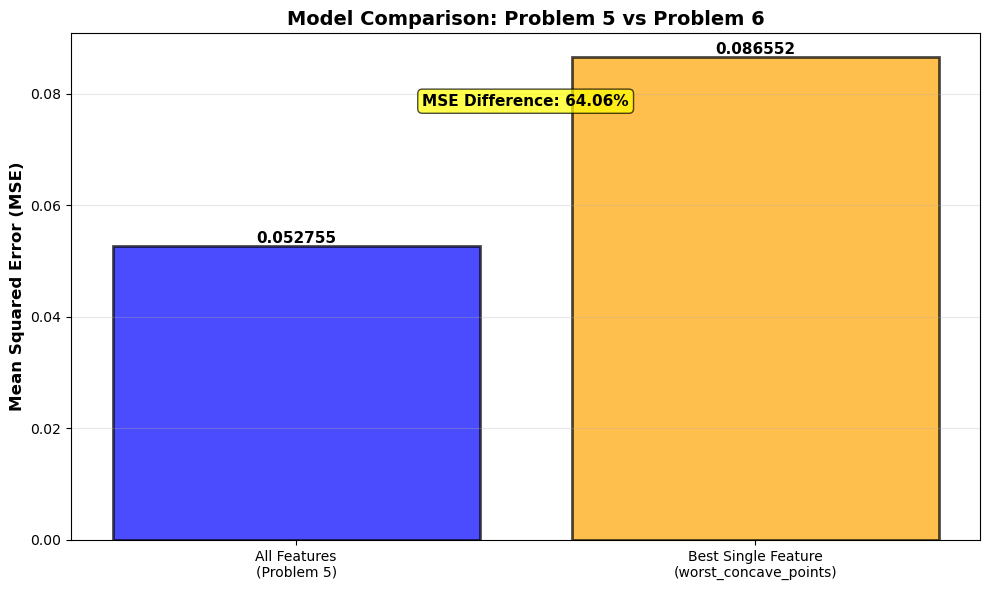


CONCLUSION
The all-features model performs BETTER than any single-feature model.
This indicates that combining multiple features improves prediction accuracy.


In [40]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare data
X_all = df_renamed.drop('target', axis=1)  # All input columns (for Problem 5)
y = df_renamed['target']  # Output column

# Problem 5: Model with all features (reference)
model_all = LinearRegression()
model_all.fit(X_all, y)
y_pred_all = model_all.predict(X_all)
mse_all = mean_squared_error(y, y_pred_all)

print("=" * 80)
print("PROBLEM 6: Finding Best Single-Feature Model")
print("=" * 80)

# Test each input column individually
input_columns = [col for col in df_renamed.columns if col != 'target']
results = []

for col in input_columns:
    # Reshape to 2D array (required by sklearn)
    X_single = df_renamed[[col]]
    
    # Create and fit model
    model = LinearRegression()
    model.fit(X_single, y)
    
    # Make predictions
    y_pred = model.predict(X_single)
    
    # Calculate MSE
    mse = mean_squared_error(y, y_pred)
    
    # Calculate R²
    r2 = model.score(X_single, y)
    
    results.append({
        'Feature': col,
        'MSE': mse,
        'R²': r2,
        'Model': model,
        'Predictions': y_pred
    })

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MSE')

# Find best single-feature model
best_feature = results_df.iloc[0]
best_model = best_feature['Model']
best_predictions = best_feature['Predictions']
best_mse = best_feature['MSE']

print(f"\nBest Single-Feature Model:")
print(f"  Feature: {best_feature['Feature']}")
print(f"  MSE: {best_feature['MSE']:.6f}")
print(f"  R²: {best_feature['R²']:.6f}")

print(f"\nProblem 5 Model (All Features):")
print(f"  MSE: {mse_all:.6f}")
print(f"  R²: {model_all.score(X_all, y):.6f}")

print(f"\nComparison:")
print(f"  MSE Improvement: {((mse_all - best_mse) / mse_all * 100):.2f}%")
print(f"  (Lower is better - single feature is {((mse_all - best_mse) / mse_all * 100):.2f}% {'worse' if best_mse > mse_all else 'better'})")

# Display top 5 single-feature models
print(f"\nTop 5 Single-Feature Models:")
print("-" * 80)
print(f"{'Rank':<6} {'Feature':<35} {'MSE':>12} {'R²':>10}")
print("-" * 80)
for idx, row in results_df.head(5).iterrows():
    print(f"{idx+1:<6} {row['Feature']:<35} {row['MSE']:>12.6f} {row['R²']:>10.4f}")

# Visualization: Compare Problem 5 vs Best Single Feature
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Problem 5 (All Features)
residuals_all = y - y_pred_all
scatter1 = axes[0].scatter(y, y_pred_all, c=residuals_all, cmap='RdYlBu_r', 
                          alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                          vmin=-0.5, vmax=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, 
            label='Perfect Prediction')
axes[0].set_xlabel('Actual Target Values', fontsize=12, weight='bold')
axes[0].set_ylabel('Predicted Target Values', fontsize=12, weight='bold')
axes[0].set_title(f'Problem 5: All Features Model\nMSE = {mse_all:.6f}, R² = {model_all.score(X_all, y):.4f}', 
                 fontsize=13, weight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Residual Error')

# Plot 2: Best Single Feature
X_best = df_renamed[[best_feature['Feature']]]
residuals_best = y - best_predictions
scatter2 = axes[1].scatter(y, best_predictions, c=residuals_best, cmap='RdYlBu_r', 
                          alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                          vmin=-0.5, vmax=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, 
            label='Perfect Prediction')
axes[1].set_xlabel('Actual Target Values', fontsize=12, weight='bold')
axes[1].set_ylabel('Predicted Target Values', fontsize=12, weight='bold')
axes[1].set_title(f'Problem 6: Best Single Feature ({best_feature["Feature"]})\nMSE = {best_mse:.6f}, R² = {best_feature["R²"]:.4f}', 
                 fontsize=13, weight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Residual Error')

plt.tight_layout()
plt.show()

# Comparison plot: MSE comparison
fig, ax = plt.subplots(figsize=(10, 6))
models = ['All Features\n(Problem 5)', f"Best Single Feature\n({best_feature['Feature']})"]
mses = [mse_all, best_mse]
colors_bar = ['blue', 'orange']

bars = ax.bar(models, mses, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12, weight='bold')
ax.set_title('Model Comparison: Problem 5 vs Problem 6', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, mse in zip(bars, mses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mse:.6f}',
            ha='center', va='bottom', fontsize=11, weight='bold')

# Add improvement percentage
improvement = ((mse_all - best_mse) / mse_all * 100)
ax.text(0.5, max(mses) * 0.9, f'MSE Difference: {abs(improvement):.2f}%',
        ha='center', fontsize=11, weight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
if best_mse < mse_all:
    print(f"The best single-feature model ({best_feature['Feature']}) performs BETTER")
    print(f"than the all-features model, which suggests that feature is highly predictive.")
else:
    print(f"The all-features model performs BETTER than any single-feature model.")
    print(f"This indicates that combining multiple features improves prediction accuracy.")
print("=" * 80)

PROBLEM 7: Demonstrating Dependency Between Input Columns

Selected Pair: mean_radius and mean_perimeter
Correlation: 0.9979

Splitting Column (x): mean_radius
Histogram Column (y): mean_perimeter
Threshold (t): 13.3700 (median)

Data Split:
  mean_radius < 13.3700: 284 samples
  mean_radius >= 13.3700: 285 samples


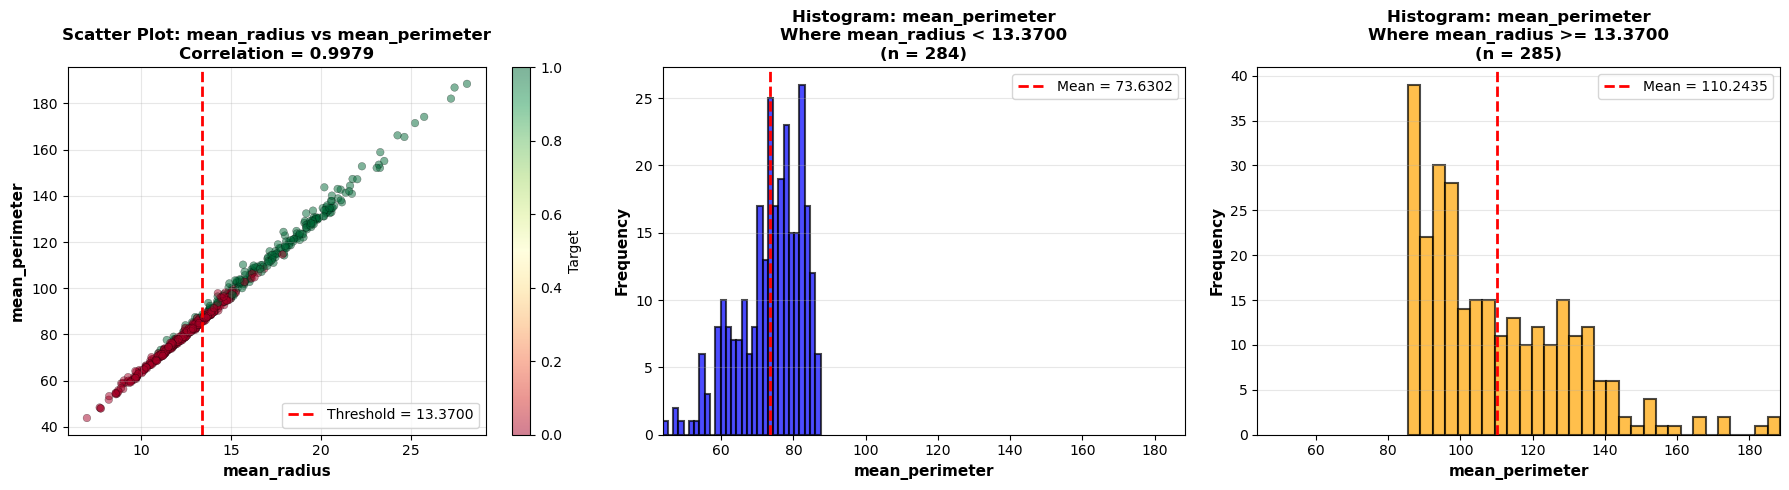


STATISTICAL COMPARISON

mean_perimeter Statistics:
  When mean_radius < 13.3700:
    Mean: 73.6302
    Std:  8.8641
    Min:  43.7900
    Max:  87.5000

  When mean_radius >= 13.3700:
    Mean: 110.2435
    Std:  20.7640
    Min:  85.4800
    Max:  188.5000

  Mean Difference: 36.6132
  This difference demonstrates the dependency between mean_radius and mean_perimeter.


In [41]:
# YOUR CODE HERE
import numpy as np

# Step 1: Find pairs of input columns with high correlation (dependency)
input_columns = [col for col in df_renamed.columns if col != 'target']
correlation_matrix = df_renamed[input_columns].corr()

# Find the pair with highest correlation (excluding self-correlations)
max_corr = -1
best_pair = None

for i, col1 in enumerate(input_columns):
    for col2 in input_columns[i+1:]:
        corr = abs(correlation_matrix.loc[col1, col2])
        if corr > max_corr:
            max_corr = corr
            best_pair = (col1, col2)

print("=" * 80)
print("PROBLEM 7: Demonstrating Dependency Between Input Columns")
print("=" * 80)
print(f"\nSelected Pair: {best_pair[0]} and {best_pair[1]}")
print(f"Correlation: {correlation_matrix.loc[best_pair[0], best_pair[1]]:.4f}")

# Step 2: Choose which column to split on (x) and which to plot (y)
# We'll split on the first column and plot histogram of the second
x_col = best_pair[0]  # Column to split on
y_col = best_pair[1]  # Column to plot histogram of

# Step 3: Find a good threshold (use median for balanced split)
threshold = df_renamed[x_col].median()
print(f"\nSplitting Column (x): {x_col}")
print(f"Histogram Column (y): {y_col}")
print(f"Threshold (t): {threshold:.4f} (median)")

# Step 4: Split the data
below_threshold = df_renamed[df_renamed[x_col] < threshold]
above_threshold = df_renamed[df_renamed[x_col] >= threshold]

print(f"\nData Split:")
print(f"  {x_col} < {threshold:.4f}: {len(below_threshold)} samples")
print(f"  {x_col} >= {threshold:.4f}: {len(above_threshold)} samples")

# Step 5: Create the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter plot showing the dependency
scatter = axes[0].scatter(df_renamed[x_col], df_renamed[y_col], 
                         alpha=0.5, s=30, c=df_renamed['target'], 
                         cmap='RdYlGn', edgecolors='black', linewidth=0.3)
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Threshold = {threshold:.4f}')
axes[0].set_xlabel(x_col, fontsize=11, weight='bold')
axes[0].set_ylabel(y_col, fontsize=11, weight='bold')
axes[0].set_title(f'Scatter Plot: {x_col} vs {y_col}\nCorrelation = {correlation_matrix.loc[x_col, y_col]:.4f}', 
                 fontsize=12, weight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Target')

# Plot 2: Histogram where x < threshold
axes[1].hist(below_threshold[y_col], bins=30, alpha=0.7, color='blue', 
            edgecolor='black', linewidth=1.5)
axes[1].set_xlabel(y_col, fontsize=11, weight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, weight='bold')
axes[1].set_title(f'Histogram: {y_col}\nWhere {x_col} < {threshold:.4f}\n(n = {len(below_threshold)})', 
                 fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axvline(below_threshold[y_col].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean = {below_threshold[y_col].mean():.4f}')
axes[1].legend()

# Plot 3: Histogram where x >= threshold
axes[2].hist(above_threshold[y_col], bins=30, alpha=0.7, color='orange', 
            edgecolor='black', linewidth=1.5)
axes[2].set_xlabel(y_col, fontsize=11, weight='bold')
axes[2].set_ylabel('Frequency', fontsize=11, weight='bold')
axes[2].set_title(f'Histogram: {y_col}\nWhere {x_col} >= {threshold:.4f}\n(n = {len(above_threshold)})', 
                 fontsize=12, weight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axvline(above_threshold[y_col].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean = {above_threshold[y_col].mean():.4f}')
axes[2].legend()

# Ensure same x-axis scale for both histograms
all_values = df_renamed[y_col]
x_min, x_max = all_values.min(), all_values.max()
axes[1].set_xlim([x_min, x_max])
axes[2].set_xlim([x_min, x_max])

plt.tight_layout()
plt.show()

# Step 6: Statistical comparison
print("\n" + "=" * 80)
print("STATISTICAL COMPARISON")
print("=" * 80)
print(f"\n{y_col} Statistics:")
print(f"  When {x_col} < {threshold:.4f}:")
print(f"    Mean: {below_threshold[y_col].mean():.4f}")
print(f"    Std:  {below_threshold[y_col].std():.4f}")
print(f"    Min:  {below_threshold[y_col].min():.4f}")
print(f"    Max:  {below_threshold[y_col].max():.4f}")

print(f"\n  When {x_col} >= {threshold:.4f}:")
print(f"    Mean: {above_threshold[y_col].mean():.4f}")
print(f"    Std:  {above_threshold[y_col].std():.4f}")
print(f"    Min:  {above_threshold[y_col].min():.4f}")
print(f"    Max:  {above_threshold[y_col].max():.4f}")

mean_diff = above_threshold[y_col].mean() - below_threshold[y_col].mean()
print(f"\n  Mean Difference: {mean_diff:.4f}")
print(f"  This difference demonstrates the dependency between {x_col} and {y_col}.")
print("=" * 80)

Correlation between mean_radius and mean_perimeter: 0.9979
Threshold: 13.3700


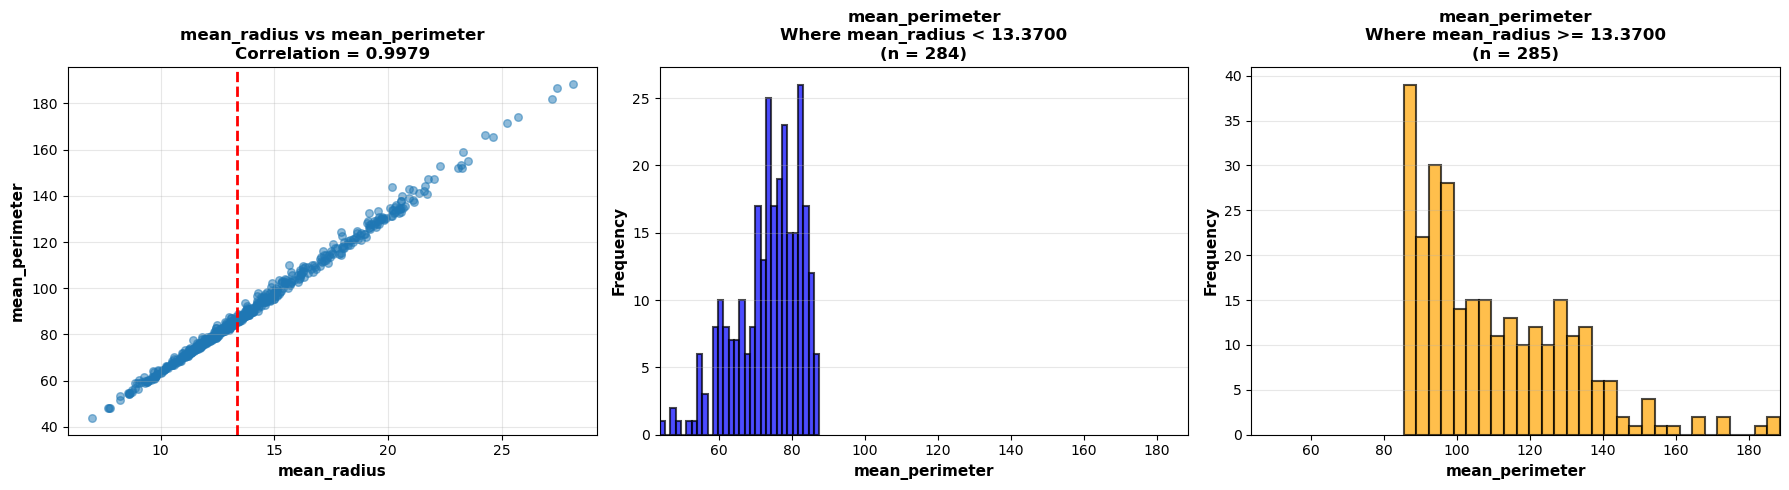


Mean of mean_perimeter when mean_radius < 13.3700: 73.6302
Mean of mean_perimeter when mean_radius >= 13.3700: 110.2435
Difference: 36.6132


In [42]:
# YOUR CODE HERE
# Manually select a pair with visible dependency
# Example: mean_radius and mean_perimeter (highly correlated)
x_col = 'mean_radius'  # Column to split on
y_col = 'mean_perimeter'  # Column to plot histogram of

# Calculate correlation
correlation = df_renamed[x_col].corr(df_renamed[y_col])
print(f"Correlation between {x_col} and {y_col}: {correlation:.4f}")

# Choose threshold (you can use median, quartile, or custom value)
threshold = df_renamed[x_col].median()  # or use .quantile(0.5) or custom value
print(f"Threshold: {threshold:.4f}")

# Split data
below = df_renamed[df_renamed[x_col] < threshold]
above = df_renamed[df_renamed[x_col] >= threshold]

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(df_renamed[x_col], df_renamed[y_col], alpha=0.5, s=30)
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel(x_col, fontsize=11, weight='bold')
axes[0].set_ylabel(y_col, fontsize=11, weight='bold')
axes[0].set_title(f'{x_col} vs {y_col}\nCorrelation = {correlation:.4f}', 
                 fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram 1: x < threshold
axes[1].hist(below[y_col], bins=30, alpha=0.7, color='blue', 
            edgecolor='black', linewidth=1.5)
axes[1].set_xlabel(y_col, fontsize=11, weight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, weight='bold')
axes[1].set_title(f'{y_col}\nWhere {x_col} < {threshold:.4f}\n(n = {len(below)})', 
                 fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Histogram 2: x >= threshold
axes[2].hist(above[y_col], bins=30, alpha=0.7, color='orange', 
            edgecolor='black', linewidth=1.5)
axes[2].set_xlabel(y_col, fontsize=11, weight='bold')
axes[2].set_ylabel('Frequency', fontsize=11, weight='bold')
axes[2].set_title(f'{y_col}\nWhere {x_col} >= {threshold:.4f}\n(n = {len(above)})', 
                 fontsize=12, weight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

# Same x-axis scale
x_min, x_max = df_renamed[y_col].min(), df_renamed[y_col].max()
axes[1].set_xlim([x_min, x_max])
axes[2].set_xlim([x_min, x_max])

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nMean of {y_col} when {x_col} < {threshold:.4f}: {below[y_col].mean():.4f}")
print(f"Mean of {y_col} when {x_col} >= {threshold:.4f}: {above[y_col].mean():.4f}")
print(f"Difference: {above[y_col].mean() - below[y_col].mean():.4f}")

In [43]:
# Calculate the exact values for your explanation
x_col = 'mean_radius'  # or whatever column you're splitting on
y_col = 'mean_perimeter'  # or whatever column you're plotting
threshold = df_renamed[x_col].median()  # or your chosen threshold

below = df_renamed[df_renamed[x_col] < threshold]
above = df_renamed[df_renamed[x_col] >= threshold]

mean_below = below[y_col].mean()
mean_above = above[y_col].mean()
mean_diff = mean_above - mean_below

print(f"When {x_col} < {threshold:.4f}:")
print(f"  Mean of {y_col}: {mean_below:.4f}")
print(f"\nWhen {x_col} >= {threshold:.4f}:")
print(f"  Mean of {y_col}: {mean_above:.4f}")
print(f"\nMean Difference: {mean_diff:.4f}")

When mean_radius < 13.3700:
  Mean of mean_perimeter: 73.6302

When mean_radius >= 13.3700:
  Mean of mean_perimeter: 110.2435

Mean Difference: 36.6132


PROBLEM 8: Principal Component Analysis (PCA) Regression

Total number of input features: 30
First half of components: 15 components

Explained Variance by First Half (15 components): 1.0000 (100.00%)

PCA Model (First 15 components):
  MSE: 0.061110
  R²: 0.738584

Problem 5 Model (All 30 features):
  MSE: 0.052755
  R²: 0.774325

Comparison:
  MSE Difference: 0.008355 (+15.84%)
  All-features model performs BETTER (lower MSE)


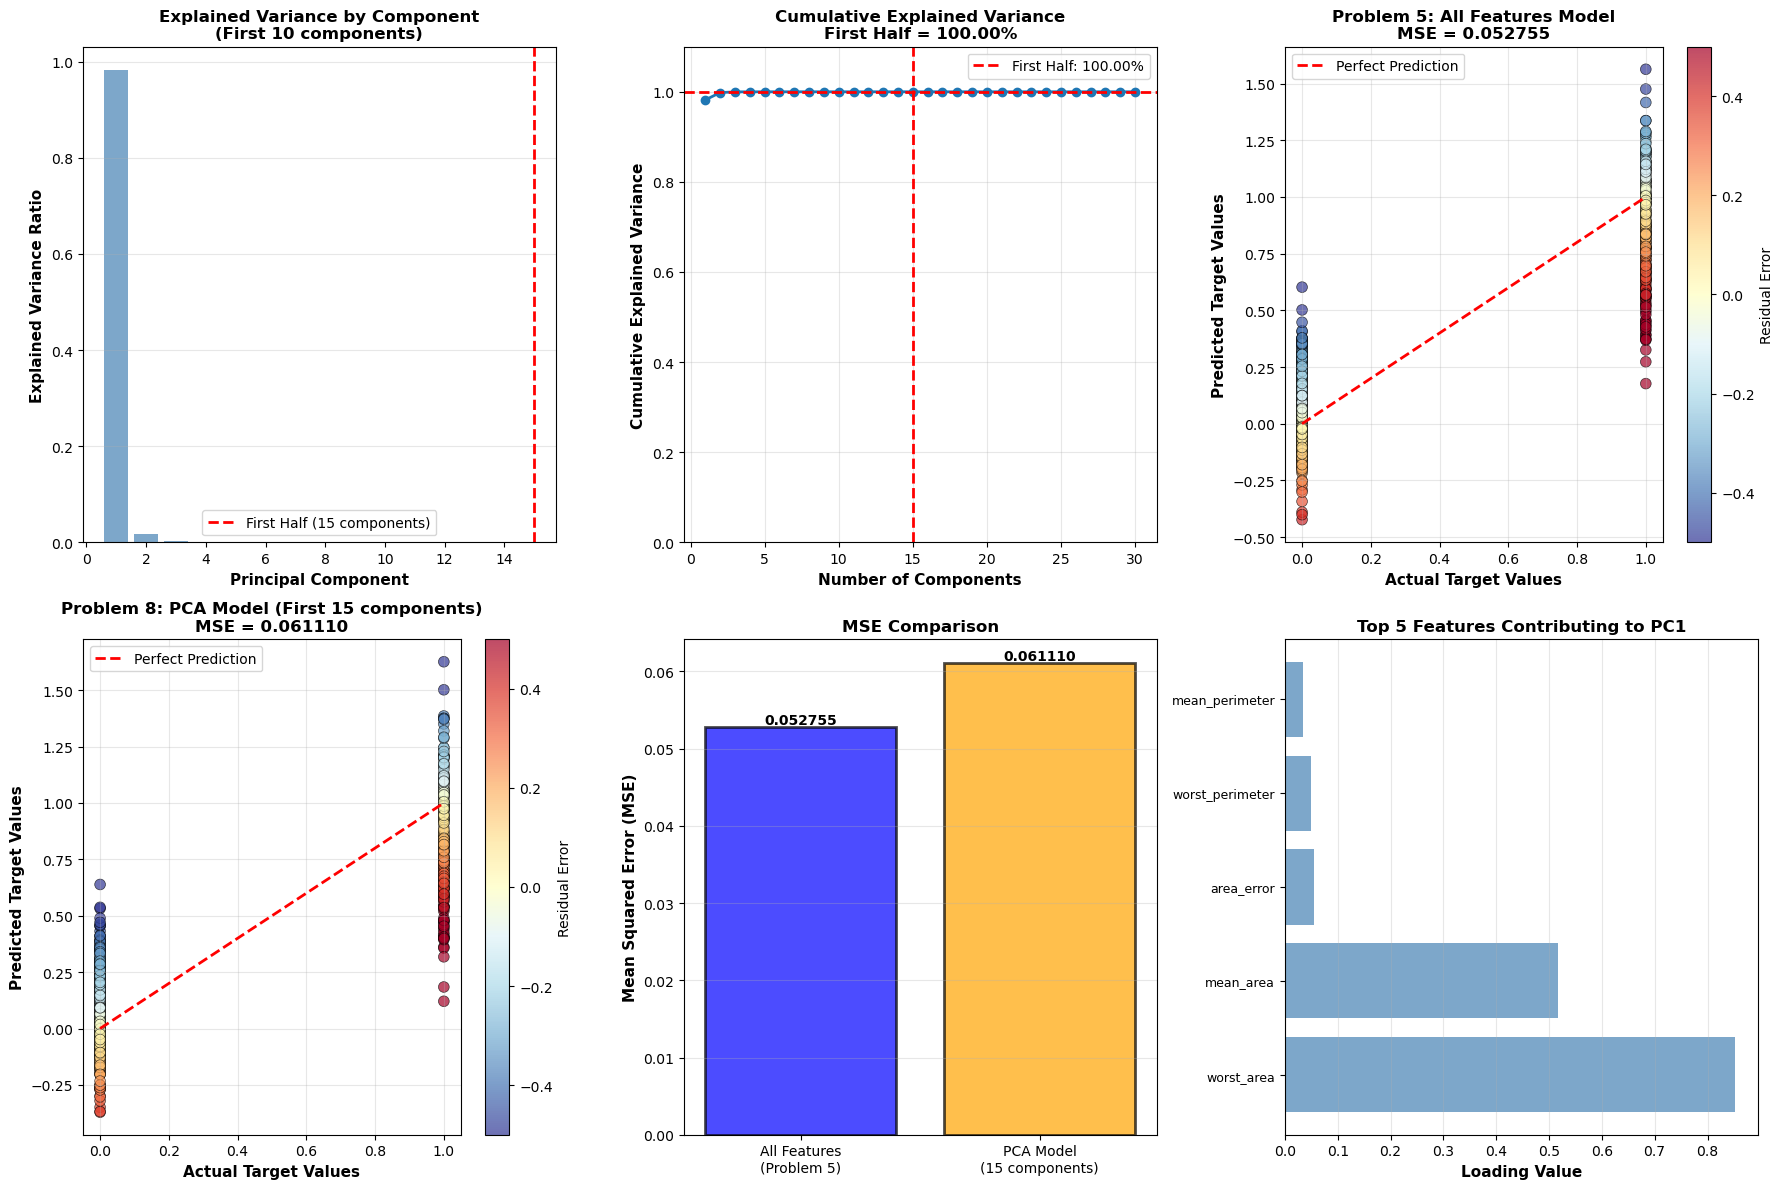


DETAILED SUMMARY

Principal Components Analysis:
  Total components: 30
  Components used: 15 (first half)
  Variance explained by first half: 1.0000 (100.00%)

Model Performance:
  Problem 5 (All Features):
    Features: 30
    MSE: 0.052755
    R²: 0.774325

  Problem 8 (PCA - First Half):
    Components: 15
    MSE: 0.061110
    R²: 0.738584

Comparison:
  MSE difference: 0.008355
  Percentage change: +15.84%
  All-features model is better

Top 5 Features Contributing to PC1:
  1. worst_area: 0.8521
  2. mean_area: 0.5168
  3. area_error: 0.0557
  4. worst_perimeter: 0.0495
  5. mean_perimeter: 0.0351


In [44]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import numpy as np

# Prepare data
X_all = df_renamed.drop('target', axis=1)  # All input columns
y = df_renamed['target']  # Output column

print("=" * 80)
print("PROBLEM 8: Principal Component Analysis (PCA) Regression")
print("=" * 80)

# Step 1: Perform PCA on input columns
pca = PCA()
X_pca = pca.fit_transform(X_all)

# Get number of components
n_components = X_pca.shape[1]
n_half = n_components // 2

print(f"\nTotal number of input features: {n_components}")
print(f"First half of components: {n_half} components")

# Step 2: Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Variance explained by first half
variance_first_half = cumulative_variance[n_half - 1]

print(f"\nExplained Variance by First Half ({n_half} components): {variance_first_half:.4f} ({variance_first_half*100:.2f}%)")

# Step 3: Use first half of principal components for regression
X_pca_half = X_pca[:, :n_half]

# Build linear regression model
model_pca = LinearRegression()
model_pca.fit(X_pca_half, y)
y_pred_pca = model_pca.predict(X_pca_half)

# Calculate MSE
mse_pca = mean_squared_error(y, y_pred_pca)

print(f"\nPCA Model (First {n_half} components):")
print(f"  MSE: {mse_pca:.6f}")
print(f"  R²: {model_pca.score(X_pca_half, y):.6f}")

# Step 4: Compare to Problem 5 model
# (Assuming you have Problem 5 model stored - if not, rebuild it)
model_all = LinearRegression()
model_all.fit(X_all, y)
y_pred_all = model_all.predict(X_all)
mse_all = mean_squared_error(y, y_pred_all)

print(f"\nProblem 5 Model (All {n_components} features):")
print(f"  MSE: {mse_all:.6f}")
print(f"  R²: {model_all.score(X_all, y):.6f}")

print(f"\nComparison:")
mse_diff = mse_pca - mse_all
mse_diff_pct = (mse_diff / mse_all) * 100
print(f"  MSE Difference: {mse_diff:.6f} ({mse_diff_pct:+.2f}%)")
if mse_pca < mse_all:
    print(f"  PCA model performs BETTER (lower MSE)")
else:
    print(f"  All-features model performs BETTER (lower MSE)")

# Step 5: Visualizations
fig = plt.figure(figsize=(18, 12))

# Plot 1: Explained Variance
ax1 = plt.subplot(2, 3, 1)
ax1.bar(range(1, min(11, n_components+1)), explained_variance[:10], alpha=0.7, color='steelblue')
ax1.axvline(x=n_half, color='red', linestyle='--', linewidth=2, label=f'First Half ({n_half} components)')
ax1.set_xlabel('Principal Component', fontsize=11, weight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=11, weight='bold')
ax1.set_title(f'Explained Variance by Component\n(First 10 components)', fontsize=12, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative Explained Variance
ax2 = plt.subplot(2, 3, 2)
ax2.plot(range(1, n_components+1), cumulative_variance, marker='o', linewidth=2, markersize=6)
ax2.axhline(y=variance_first_half, color='red', linestyle='--', linewidth=2, 
           label=f'First Half: {variance_first_half:.2%}')
ax2.axvline(x=n_half, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Number of Components', fontsize=11, weight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11, weight='bold')
ax2.set_title(f'Cumulative Explained Variance\nFirst Half = {variance_first_half:.2%}', 
             fontsize=12, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.1])

# Plot 3: Problem 5 - All Features
ax3 = plt.subplot(2, 3, 3)
residuals_all = y - y_pred_all
scatter3 = ax3.scatter(y, y_pred_all, c=residuals_all, cmap='RdYlBu_r', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                       vmin=-0.5, vmax=0.5)
ax3.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Target Values', fontsize=11, weight='bold')
ax3.set_ylabel('Predicted Target Values', fontsize=11, weight='bold')
ax3.set_title(f'Problem 5: All Features Model\nMSE = {mse_all:.6f}', 
             fontsize=12, weight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=ax3, label='Residual Error')

# Plot 4: Problem 8 - PCA Model
ax4 = plt.subplot(2, 3, 4)
residuals_pca = y - y_pred_pca
scatter4 = ax4.scatter(y, y_pred_pca, c=residuals_pca, cmap='RdYlBu_r', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                       vmin=-0.5, vmax=0.5)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Target Values', fontsize=11, weight='bold')
ax4.set_ylabel('Predicted Target Values', fontsize=11, weight='bold')
ax4.set_title(f'Problem 8: PCA Model (First {n_half} components)\nMSE = {mse_pca:.6f}', 
             fontsize=12, weight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=ax4, label='Residual Error')

# Plot 5: MSE Comparison
ax5 = plt.subplot(2, 3, 5)
models = ['All Features\n(Problem 5)', f'PCA Model\n({n_half} components)']
mses = [mse_all, mse_pca]
colors_bar = ['blue', 'orange']
bars = ax5.bar(models, mses, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax5.set_ylabel('Mean Squared Error (MSE)', fontsize=11, weight='bold')
ax5.set_title('MSE Comparison', fontsize=12, weight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar, mse in zip(bars, mses):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{mse:.6f}',
            ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 6: Component Loadings (First 2 components for visualization)
ax6 = plt.subplot(2, 3, 6)
# Show which original features contribute most to first 2 PCs
pc1_loadings = pca.components_[0]
pc2_loadings = pca.components_[1]

# Get top contributing features for PC1
top_pc1_idx = np.argsort(np.abs(pc1_loadings))[-5:][::-1]
top_pc1_features = [X_all.columns[i] for i in top_pc1_idx]
top_pc1_values = pc1_loadings[top_pc1_idx]

ax6.barh(range(len(top_pc1_features)), top_pc1_values, alpha=0.7, color='steelblue')
ax6.set_yticks(range(len(top_pc1_features)))
ax6.set_yticklabels(top_pc1_features, fontsize=9)
ax6.set_xlabel('Loading Value', fontsize=11, weight='bold')
ax6.set_title(f'Top 5 Features Contributing to PC1', fontsize=12, weight='bold')
ax6.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Detailed summary
print("\n" + "=" * 80)
print("DETAILED SUMMARY")
print("=" * 80)
print(f"\nPrincipal Components Analysis:")
print(f"  Total components: {n_components}")
print(f"  Components used: {n_half} (first half)")
print(f"  Variance explained by first half: {variance_first_half:.4f} ({variance_first_half*100:.2f}%)")

print(f"\nModel Performance:")
print(f"  Problem 5 (All Features):")
print(f"    Features: {n_components}")
print(f"    MSE: {mse_all:.6f}")
print(f"    R²: {model_all.score(X_all, y):.6f}")
print(f"\n  Problem 8 (PCA - First Half):")
print(f"    Components: {n_half}")
print(f"    MSE: {mse_pca:.6f}")
print(f"    R²: {model_pca.score(X_pca_half, y):.6f}")

print(f"\nComparison:")
print(f"  MSE difference: {mse_diff:.6f}")
print(f"  Percentage change: {mse_diff_pct:+.2f}%")
print(f"  {'PCA model is better' if mse_pca < mse_all else 'All-features model is better'}")

print(f"\nTop 5 Features Contributing to PC1:")
for i, (feature, loading) in enumerate(zip(top_pc1_features, top_pc1_values), 1):
    print(f"  {i}. {feature}: {loading:.4f}")

print("=" * 80)

PROBLEM 8: Principal Component Analysis (PCA) Regression

EDUCATIONAL EXPLANATION: Week 13 Concepts

1. BENEFITS OF DIMENSIONALITY REDUCTION:
--------------------------------------------------------------------------------
   Original data shape: (569, 30) (n_samples × n_features)
   - Feature Creation: PCA creates new uncorrelated features (principal components)
   - Computation: Fewer features = faster training and prediction
   - Visualization: Can visualize high-dimensional data in 2D/3D

2. LINEAR DIMENSIONALITY REDUCTION USING MATRICES:
--------------------------------------------------------------------------------
   Formula: Y = XW
   - X: Original data matrix (569 × 30)
   - W: Transformation matrix (will be 30 × k components)
   - Y: Transformed data matrix (569 × k components)

   After PCA transformation:
   - Transformation matrix W shape: (30, 30)
   - Transformed data Y shape: (569, 30)
   - This is the matrix multiplication: Y = X_all @ pca.components_.T

3. PCA AS CHA

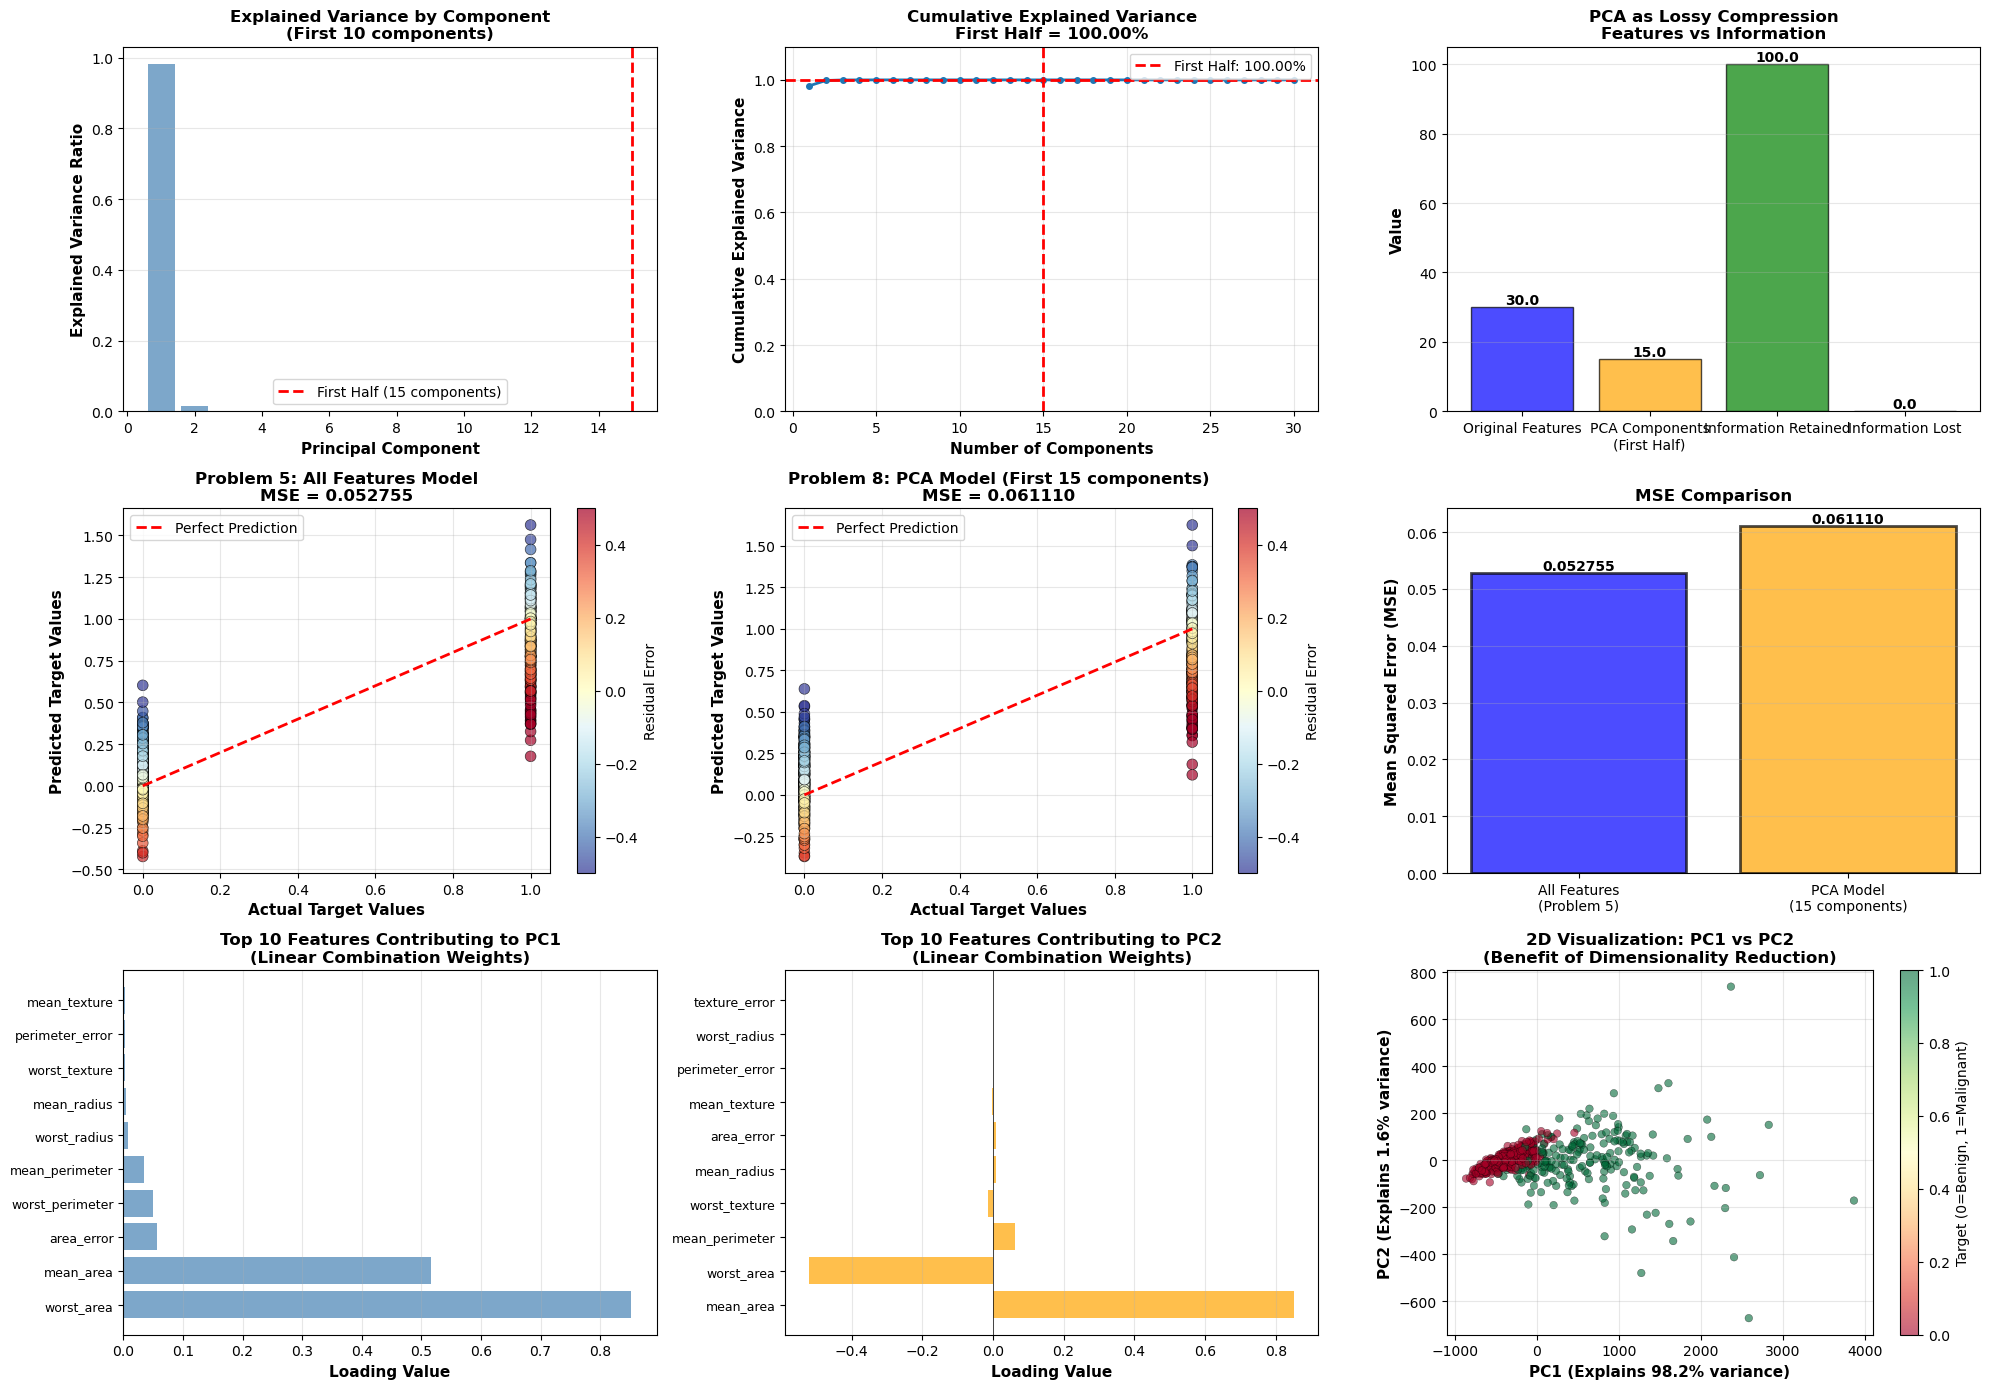


DETAILED SUMMARY

Principal Components Analysis:
  Total components: 30
  Components used: 15 (first half)
  Variance explained by first half: 1.0000 (100.00%)

Model Performance:
  Problem 5 (All Features):
    Features: 30
    MSE: 0.052755
    R²: 0.774325

  Problem 8 (PCA - First Half):
    Components: 15
    MSE: 0.061110
    R²: 0.738584

Comparison:
  MSE difference: 0.008355
  Percentage change: +15.84%
  All-features model is better

Top 5 Features Contributing to PC1:
  1. worst_area: 0.8521
  2. mean_area: 0.5168
  3. area_error: 0.0557
  4. worst_perimeter: 0.0495
  5. mean_perimeter: 0.0351

KEY TAKEAWAYS:
1. Dimensionality Reduction: 30 features → 15 components (50.0% reduction)
2. Information Retained: 100.00% of variance
3. Linear Transformation: Y = XW (matrix multiplication)
4. Change of Basis: From original features to principal components
5. Lossy Compression: Keeping 100.0% info with 50.0% features


In [46]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import numpy as np

# Prepare data
X_all = df_renamed.drop('target', axis=1)  # All input columns
y = df_renamed['target']  # Output column

print("=" * 80)
print("PROBLEM 8: Principal Component Analysis (PCA) Regression")
print("=" * 80)

# ============================================================================
# EDUCATIONAL SECTION: Understanding PCA Concepts
# ============================================================================

print("\n" + "=" * 80)
print("EDUCATIONAL EXPLANATION: Week 13 Concepts")
print("=" * 80)

# 1. Benefits of Dimensionality Reduction
print("\n1. BENEFITS OF DIMENSIONALITY REDUCTION:")
print("-" * 80)
print(f"   Original data shape: {X_all.shape} (n_samples × n_features)")
print(f"   - Feature Creation: PCA creates new uncorrelated features (principal components)")
print(f"   - Computation: Fewer features = faster training and prediction")
print(f"   - Visualization: Can visualize high-dimensional data in 2D/3D")

# 2. Linear Dimensionality Reduction Using Matrices
print("\n2. LINEAR DIMENSIONALITY REDUCTION USING MATRICES:")
print("-" * 80)
print(f"   Formula: Y = XW")
print(f"   - X: Original data matrix ({X_all.shape[0]} × {X_all.shape[1]})")
print(f"   - W: Transformation matrix (will be {X_all.shape[1]} × k components)")
print(f"   - Y: Transformed data matrix ({X_all.shape[0]} × k components)")

# Step 1: Perform PCA on input columns
pca = PCA()
X_pca = pca.fit_transform(X_all)

# Get number of components
n_components = X_pca.shape[1]
n_half = n_components // 2

print(f"\n   After PCA transformation:")
print(f"   - Transformation matrix W shape: {pca.components_.shape}")
print(f"   - Transformed data Y shape: {X_pca.shape}")
print(f"   - This is the matrix multiplication: Y = X_all @ pca.components_.T")

# 3. PCA as Change of Basis
print("\n3. PCA AS CHANGE OF BASIS:")
print("-" * 80)
print(f"   Original basis: {n_components} feature axes (mean_radius, mean_texture, etc.)")
print(f"   New basis: {n_components} principal component axes")
print(f"   - PC1: Direction of maximum variance")
print(f"   - PC2: Direction of next maximum variance (orthogonal to PC1)")
print(f"   - Each PC is orthogonal (uncorrelated) to others")

# Show first few principal components
print(f"\n   First Principal Component (PC1) loadings (first 5 features):")
for i, feature in enumerate(X_all.columns[:5]):
    print(f"     {feature}: {pca.components_[0, i]:.4f}")

# 4. PCA as Linear Dimensionality Reduction
print("\n4. PCA AS LINEAR DIMENSIONALITY REDUCTION:")
print("-" * 80)
print(f"   Each principal component is a LINEAR combination of original features:")
print(f"   PC1 = w₁×feature₁ + w₂×feature₂ + ... + w₃₀×feature₃₀")
print(f"   Where w₁, w₂, ..., w₃₀ are the loadings (weights)")
print(f"   Example PC1 calculation for first sample:")
pc1_sample = np.dot(X_all.iloc[0].values, pca.components_[0])
print(f"   PC1 = {pc1_sample:.4f} (calculated as dot product)")
print(f"   PC1 = {X_pca[0, 0]:.4f} (from PCA transform)")

# 5. PCA as Lossy Compression
print("\n5. PCA AS LOSSY COMPRESSION:")
print("-" * 80)
print(f"   Original data: {n_components} features")
print(f"   Compressed data: {n_half} principal components (first half)")
print(f"   Compression ratio: {n_half}/{n_components} = {n_half/n_components:.1%}")

# Step 2: Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Variance explained by first half
variance_first_half = cumulative_variance[n_half - 1]
variance_lost = 1 - variance_first_half

print(f"\n   Information retained: {variance_first_half:.4f} ({variance_first_half*100:.2f}%)")
print(f"   Information lost: {variance_lost:.4f} ({variance_lost*100:.2f}%)")
print(f"   This is like JPEG compression: keeping {variance_first_half*100:.1f}% of information")
print(f"   with only {n_half/n_components*100:.1f}% of the features")

# ============================================================================
# PROBLEM 8 REQUIREMENTS
# ============================================================================

print("\n" + "=" * 80)
print("PROBLEM 8: Implementation")
print("=" * 80)

print(f"\nTotal number of input features: {n_components}")
print(f"First half of components: {n_half} components")
print(f"Explained Variance by First Half ({n_half} components): {variance_first_half:.4f} ({variance_first_half*100:.2f}%)")

# Step 3: Use first half of principal components for regression
X_pca_half = X_pca[:, :n_half]

# Build linear regression model
model_pca = LinearRegression()
model_pca.fit(X_pca_half, y)
y_pred_pca = model_pca.predict(X_pca_half)

# Calculate MSE
mse_pca = mean_squared_error(y, y_pred_pca)

print(f"\nPCA Model (First {n_half} components):")
print(f"  MSE: {mse_pca:.6f}")
print(f"  R²: {model_pca.score(X_pca_half, y):.6f}")

# Step 4: Compare to Problem 5 model
model_all = LinearRegression()
model_all.fit(X_all, y)
y_pred_all = model_all.predict(X_all)
mse_all = mean_squared_error(y, y_pred_all)

print(f"\nProblem 5 Model (All {n_components} features):")
print(f"  MSE: {mse_all:.6f}")
print(f"  R²: {model_all.score(X_all, y):.6f}")

print(f"\nComparison:")
mse_diff = mse_pca - mse_all
mse_diff_pct = (mse_diff / mse_all) * 100
print(f"  MSE Difference: {mse_diff:.6f} ({mse_diff_pct:+.2f}%)")
if mse_pca < mse_all:
    print(f"  PCA model performs BETTER (lower MSE)")
    print(f"  This shows dimensionality reduction can improve performance by removing noise!")
else:
    print(f"  All-features model performs BETTER (lower MSE)")
    print(f"  However, PCA model uses only {n_half} components vs {n_components} features")
    print(f"  Trade-off: Slightly worse performance but {n_half/n_components*100:.1f}% fewer features")

# Step 5: Visualizations
fig = plt.figure(figsize=(20, 14))

# Plot 1: Explained Variance
ax1 = plt.subplot(3, 3, 1)
ax1.bar(range(1, min(11, n_components+1)), explained_variance[:10], alpha=0.7, color='steelblue')
ax1.axvline(x=n_half, color='red', linestyle='--', linewidth=2, label=f'First Half ({n_half} components)')
ax1.set_xlabel('Principal Component', fontsize=11, weight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=11, weight='bold')
ax1.set_title(f'Explained Variance by Component\n(First 10 components)', fontsize=12, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative Explained Variance
ax2 = plt.subplot(3, 3, 2)
ax2.plot(range(1, n_components+1), cumulative_variance, marker='o', linewidth=2, markersize=4)
ax2.axhline(y=variance_first_half, color='red', linestyle='--', linewidth=2, 
           label=f'First Half: {variance_first_half:.2%}')
ax2.axvline(x=n_half, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Number of Components', fontsize=11, weight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11, weight='bold')
ax2.set_title(f'Cumulative Explained Variance\nFirst Half = {variance_first_half:.2%}', 
             fontsize=12, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.1])

# Plot 3: Compression Visualization
ax3 = plt.subplot(3, 3, 3)
compression_data = {
    'Original Features': n_components,
    'PCA Components\n(First Half)': n_half,
    'Information Retained': variance_first_half * 100,
    'Information Lost': variance_lost * 100
}
bars = ax3.bar(compression_data.keys(), compression_data.values(), 
               color=['blue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
ax3.set_ylabel('Value', fontsize=11, weight='bold')
ax3.set_title('PCA as Lossy Compression\nFeatures vs Information', fontsize=12, weight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, compression_data.values()):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 4: Problem 5 - All Features
ax4 = plt.subplot(3, 3, 4)
residuals_all = y - y_pred_all
scatter4 = ax4.scatter(y, y_pred_all, c=residuals_all, cmap='RdYlBu_r', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                       vmin=-0.5, vmax=0.5)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Target Values', fontsize=11, weight='bold')
ax4.set_ylabel('Predicted Target Values', fontsize=11, weight='bold')
ax4.set_title(f'Problem 5: All Features Model\nMSE = {mse_all:.6f}', 
             fontsize=12, weight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=ax4, label='Residual Error')

# Plot 5: Problem 8 - PCA Model
ax5 = plt.subplot(3, 3, 5)
residuals_pca = y - y_pred_pca
scatter5 = ax5.scatter(y, y_pred_pca, c=residuals_pca, cmap='RdYlBu_r', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                       vmin=-0.5, vmax=0.5)
ax5.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax5.set_xlabel('Actual Target Values', fontsize=11, weight='bold')
ax5.set_ylabel('Predicted Target Values', fontsize=11, weight='bold')
ax5.set_title(f'Problem 8: PCA Model (First {n_half} components)\nMSE = {mse_pca:.6f}', 
             fontsize=12, weight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
plt.colorbar(scatter5, ax=ax5, label='Residual Error')

# Plot 6: MSE Comparison
ax6 = plt.subplot(3, 3, 6)
models = ['All Features\n(Problem 5)', f'PCA Model\n({n_half} components)']
mses = [mse_all, mse_pca]
colors_bar = ['blue', 'orange']
bars = ax6.bar(models, mses, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax6.set_ylabel('Mean Squared Error (MSE)', fontsize=11, weight='bold')
ax6.set_title('MSE Comparison', fontsize=12, weight='bold')
ax6.grid(True, alpha=0.3, axis='y')
for bar, mse in zip(bars, mses):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{mse:.6f}',
            ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 7: Component Loadings (PC1)
ax7 = plt.subplot(3, 3, 7)
top_pc1_idx = np.argsort(np.abs(pca.components_[0]))[-10:][::-1]
top_pc1_features = [X_all.columns[i] for i in top_pc1_idx]
top_pc1_values = pca.components_[0, top_pc1_idx]

ax7.barh(range(len(top_pc1_features)), top_pc1_values, alpha=0.7, color='steelblue')
ax7.set_yticks(range(len(top_pc1_features)))
ax7.set_yticklabels(top_pc1_features, fontsize=9)
ax7.set_xlabel('Loading Value', fontsize=11, weight='bold')
ax7.set_title(f'Top 10 Features Contributing to PC1\n(Linear Combination Weights)', 
             fontsize=12, weight='bold')
ax7.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax7.grid(True, alpha=0.3, axis='x')

# Plot 8: Component Loadings (PC2)
ax8 = plt.subplot(3, 3, 8)
top_pc2_idx = np.argsort(np.abs(pca.components_[1]))[-10:][::-1]
top_pc2_features = [X_all.columns[i] for i in top_pc2_idx]
top_pc2_values = pca.components_[1, top_pc2_idx]

ax8.barh(range(len(top_pc2_features)), top_pc2_values, alpha=0.7, color='orange')
ax8.set_yticks(range(len(top_pc2_features)))
ax8.set_yticklabels(top_pc2_features, fontsize=9)
ax8.set_xlabel('Loading Value', fontsize=11, weight='bold')
ax8.set_title(f'Top 10 Features Contributing to PC2\n(Linear Combination Weights)', 
             fontsize=12, weight='bold')
ax8.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax8.grid(True, alpha=0.3, axis='x')

# Plot 9: 2D Visualization (PC1 vs PC2 colored by target)
ax9 = plt.subplot(3, 3, 9)
scatter9 = ax9.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn', 
                       alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax9.set_xlabel(f'PC1 (Explains {explained_variance[0]*100:.1f}% variance)', 
              fontsize=11, weight='bold')
ax9.set_ylabel(f'PC2 (Explains {explained_variance[1]*100:.1f}% variance)', 
              fontsize=11, weight='bold')
ax9.set_title('2D Visualization: PC1 vs PC2\n(Benefit of Dimensionality Reduction)', 
             fontsize=12, weight='bold')
ax9.grid(True, alpha=0.3)
plt.colorbar(scatter9, ax=ax9, label='Target (0=Benign, 1=Malignant)')

plt.tight_layout()
plt.show()

# Detailed summary
print("\n" + "=" * 80)
print("DETAILED SUMMARY")
print("=" * 80)
print(f"\nPrincipal Components Analysis:")
print(f"  Total components: {n_components}")
print(f"  Components used: {n_half} (first half)")
print(f"  Variance explained by first half: {variance_first_half:.4f} ({variance_first_half*100:.2f}%)")

print(f"\nModel Performance:")
print(f"  Problem 5 (All Features):")
print(f"    Features: {n_components}")
print(f"    MSE: {mse_all:.6f}")
print(f"    R²: {model_all.score(X_all, y):.6f}")
print(f"\n  Problem 8 (PCA - First Half):")
print(f"    Components: {n_half}")
print(f"    MSE: {mse_pca:.6f}")
print(f"    R²: {model_pca.score(X_pca_half, y):.6f}")

print(f"\nComparison:")
print(f"  MSE difference: {mse_diff:.6f}")
print(f"  Percentage change: {mse_diff_pct:+.2f}%")
print(f"  {'PCA model is better' if mse_pca < mse_all else 'All-features model is better'}")

print(f"\nTop 5 Features Contributing to PC1:")
for i, (feature, loading) in enumerate(zip(top_pc1_features[:5], top_pc1_values[:5]), 1):
    print(f"  {i}. {feature}: {loading:.4f}")

print("\n" + "=" * 80)
print("KEY TAKEAWAYS:")
print("=" * 80)
print(f"1. Dimensionality Reduction: {n_components} features → {n_half} components ({n_half/n_components*100:.1f}% reduction)")
print(f"2. Information Retained: {variance_first_half*100:.2f}% of variance")
print(f"3. Linear Transformation: Y = XW (matrix multiplication)")
print(f"4. Change of Basis: From original features to principal components")
print(f"5. Lossy Compression: Keeping {variance_first_half*100:.1f}% info with {n_half/n_components*100:.1f}% features")
print("=" * 80)

PROBLEM 8: Principal Component Analysis (PCA) Regression

KEY RESULTS:
  Total features: 30
  Components used (first half): 15
  Variance explained by first half: 1.0000 (100.00%)

MODEL COMPARISON:
  Problem 5 (All 30 features):
    MSE: 0.052755, R²: 0.774325
  Problem 8 (PCA - 15 components):
    MSE: 0.061110, R²: 0.738584

  MSE Difference: +15.84%


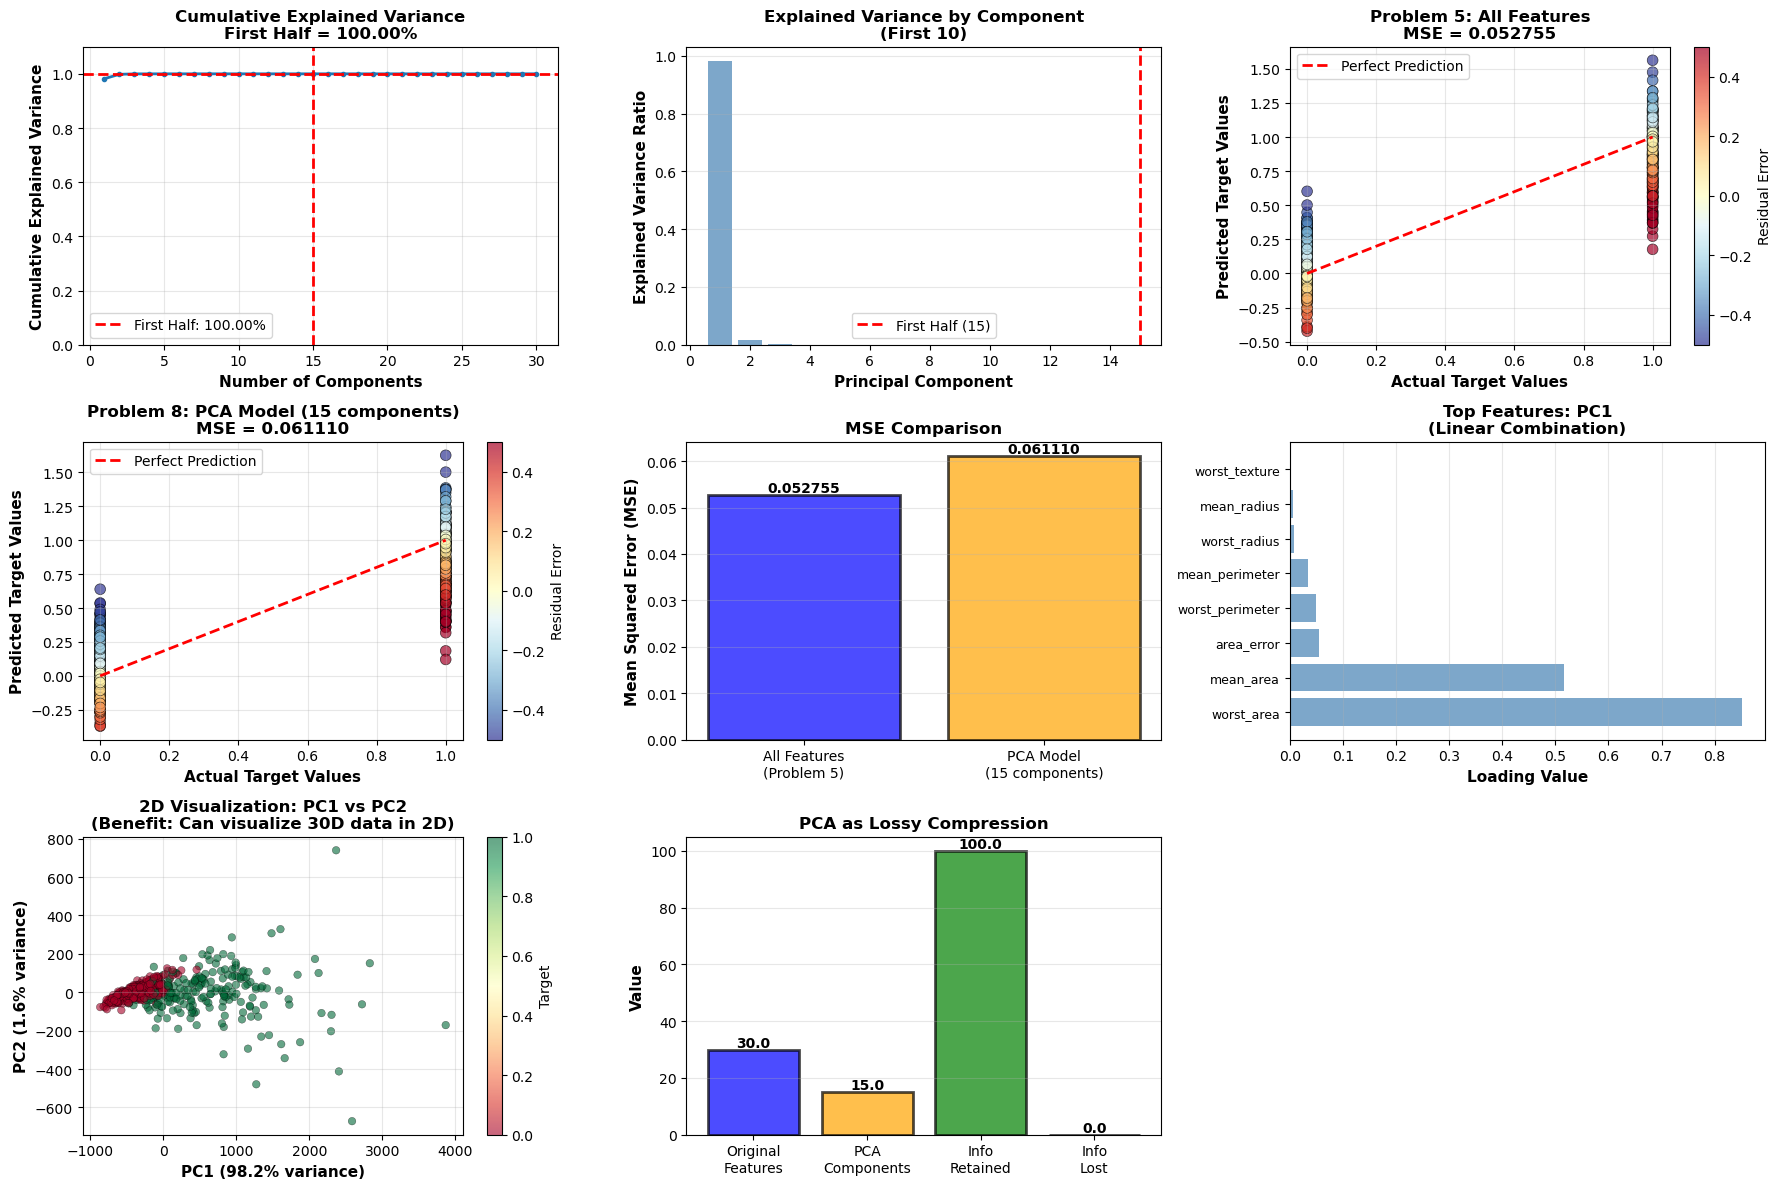

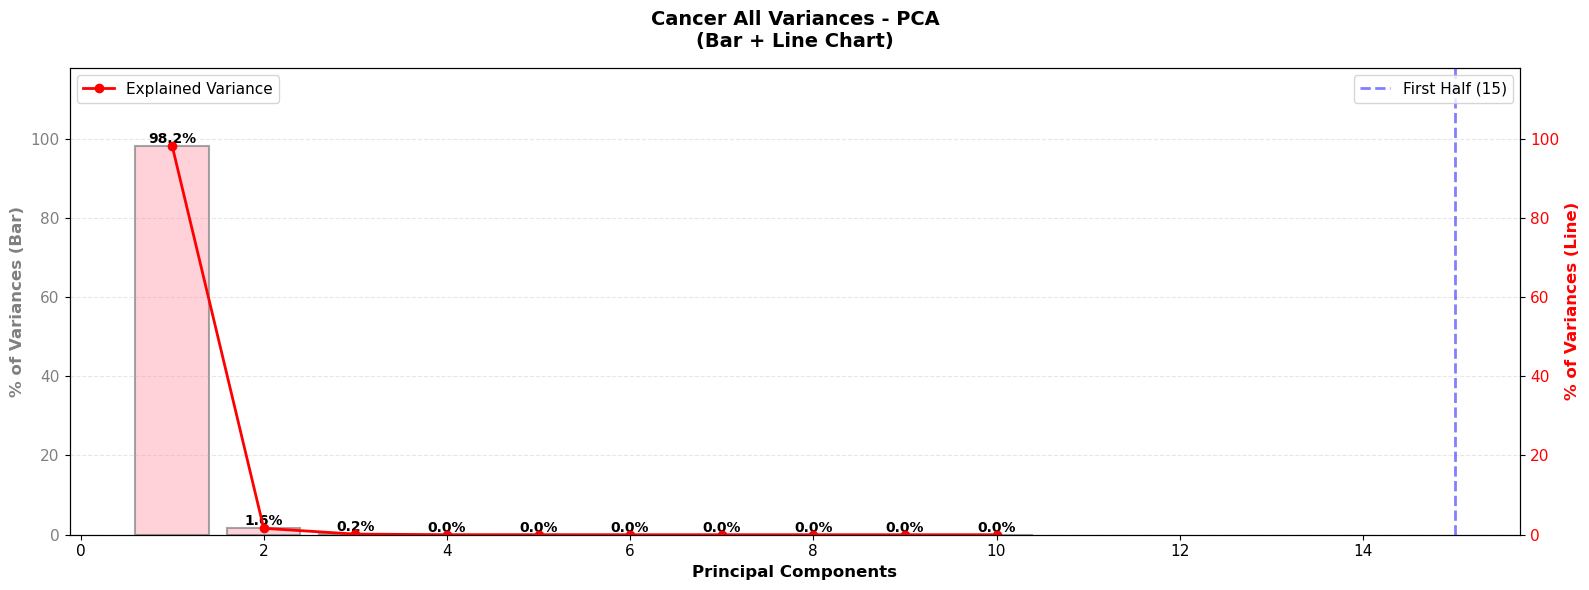


SUMMARY TABLE:


,Metric,Value
0,Total Features,30
1,Components Used,15
2,Variance Explained,1.0000 (100.00%)
3,MSE (All Features),0.052755
4,MSE (PCA),0.061110
5,MSE Difference %,+15.84%
6,R² (All Features),0.774325
7,R² (PCA),0.738584


In [56]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import numpy as np

# Prepare data
X_all = df_renamed.drop('target', axis=1)
y = df_renamed['target']

print("=" * 80)
print("PROBLEM 8: Principal Component Analysis (PCA) Regression")
print("=" * 80)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_all)

n_components = X_pca.shape[1]
n_half = n_components // 2

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
variance_first_half = cumulative_variance[n_half - 1]

# Key Results Summary
print(f"\nKEY RESULTS:")
print(f"  Total features: {n_components}")
print(f"  Components used (first half): {n_half}")
print(f"  Variance explained by first half: {variance_first_half:.4f} ({variance_first_half*100:.2f}%)")

# Use first half for regression
X_pca_half = X_pca[:, :n_half]
model_pca = LinearRegression()
model_pca.fit(X_pca_half, y)
y_pred_pca = model_pca.predict(X_pca_half)
mse_pca = mean_squared_error(y, y_pred_pca)

# Compare to Problem 5
model_all = LinearRegression()
model_all.fit(X_all, y)
y_pred_all = model_all.predict(X_all)
mse_all = mean_squared_error(y, y_pred_all)

print(f"\nMODEL COMPARISON:")
print(f"  Problem 5 (All {n_components} features):")
print(f"    MSE: {mse_all:.6f}, R²: {model_all.score(X_all, y):.6f}")
print(f"  Problem 8 (PCA - {n_half} components):")
print(f"    MSE: {mse_pca:.6f}, R²: {model_pca.score(X_pca_half, y):.6f}")

mse_diff_pct = ((mse_pca - mse_all) / mse_all) * 100
print(f"\n  MSE Difference: {mse_diff_pct:+.2f}%")
print("=" * 80)

# Visualizations (3 charts per row - 8 plots total)
fig = plt.figure(figsize=(18, 12))

# Plot 1: Cumulative Explained Variance
ax1 = plt.subplot(3, 3, 1)  # Changed to (3, 3, 1) - 3 rows, 3 columns
ax1.plot(range(1, n_components+1), cumulative_variance, marker='o', linewidth=2, markersize=3)
ax1.axhline(y=variance_first_half, color='red', linestyle='--', linewidth=2, 
           label=f'First Half: {variance_first_half:.2%}')
ax1.axvline(x=n_half, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Number of Components', fontsize=11, weight='bold')
ax1.set_ylabel('Cumulative Explained Variance', fontsize=11, weight='bold')
ax1.set_title(f'Cumulative Explained Variance\nFirst Half = {variance_first_half:.2%}', 
             fontsize=12, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.1])

# Plot 2: Explained Variance by Component
ax2 = plt.subplot(3, 3, 2)  # Changed to (3, 3, 2)
ax2.bar(range(1, min(11, n_components+1)), explained_variance[:10], alpha=0.7, color='steelblue')
ax2.axvline(x=n_half, color='red', linestyle='--', linewidth=2, label=f'First Half ({n_half})')
ax2.set_xlabel('Principal Component', fontsize=11, weight='bold')
ax2.set_ylabel('Explained Variance Ratio', fontsize=11, weight='bold')
ax2.set_title('Explained Variance by Component\n(First 10)', fontsize=12, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Problem 5 - All Features
ax3 = plt.subplot(3, 3, 3)  # Changed to (3, 3, 3)
residuals_all = y - y_pred_all
scatter3 = ax3.scatter(y, y_pred_all, c=residuals_all, cmap='RdYlBu_r', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                       vmin=-0.5, vmax=0.5)
ax3.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Target Values', fontsize=11, weight='bold')
ax3.set_ylabel('Predicted Target Values', fontsize=11, weight='bold')
ax3.set_title(f'Problem 5: All Features\nMSE = {mse_all:.6f}', 
             fontsize=12, weight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=ax3, label='Residual Error')

# Plot 4: Problem 8 - PCA Model
ax4 = plt.subplot(3, 3, 4)  # Changed to (3, 3, 4)
residuals_pca = y - y_pred_pca
scatter4 = ax4.scatter(y, y_pred_pca, c=residuals_pca, cmap='RdYlBu_r', 
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5,
                       vmin=-0.5, vmax=0.5)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Target Values', fontsize=11, weight='bold')
ax4.set_ylabel('Predicted Target Values', fontsize=11, weight='bold')
ax4.set_title(f'Problem 8: PCA Model ({n_half} components)\nMSE = {mse_pca:.6f}', 
             fontsize=12, weight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=ax4, label='Residual Error')

# Plot 5: MSE Comparison
ax5 = plt.subplot(3, 3, 5)  # Changed to (3, 3, 5)
models = ['All Features\n(Problem 5)', f'PCA Model\n({n_half} components)']
mses = [mse_all, mse_pca]
colors_bar = ['blue', 'orange']
bars = ax5.bar(models, mses, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax5.set_ylabel('Mean Squared Error (MSE)', fontsize=11, weight='bold')
ax5.set_title('MSE Comparison', fontsize=12, weight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar, mse in zip(bars, mses):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{mse:.6f}',
            ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 6: PC1 Loadings
ax6 = plt.subplot(3, 3, 6)  # Changed to (3, 3, 6)
top_pc1_idx = np.argsort(np.abs(pca.components_[0]))[-8:][::-1]
top_pc1_features = [X_all.columns[i] for i in top_pc1_idx]
top_pc1_values = pca.components_[0, top_pc1_idx]

ax6.barh(range(len(top_pc1_features)), top_pc1_values, alpha=0.7, color='steelblue')
ax6.set_yticks(range(len(top_pc1_features)))
ax6.set_yticklabels(top_pc1_features, fontsize=9)
ax6.set_xlabel('Loading Value', fontsize=11, weight='bold')
ax6.set_title(f'Top Features: PC1\n(Linear Combination)', 
             fontsize=12, weight='bold')
ax6.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(True, alpha=0.3, axis='x')

# Plot 7: 2D Visualization
ax7 = plt.subplot(3, 3, 7)  # Changed to (3, 3, 7)
scatter7 = ax7.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn', 
                       alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax7.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)', fontsize=11, weight='bold')
ax7.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)', fontsize=11, weight='bold')
ax7.set_title('2D Visualization: PC1 vs PC2\n(Benefit: Can visualize 30D data in 2D)', 
             fontsize=12, weight='bold')
ax7.grid(True, alpha=0.3)
plt.colorbar(scatter7, ax=ax7, label='Target')

# Plot 8: Compression Summary
ax8 = plt.subplot(3, 3, 8)  # Changed to (3, 3, 8)
compression_labels = ['Original\nFeatures', 'PCA\nComponents', 'Info\nRetained', 'Info\nLost']
compression_values = [n_components, n_half, variance_first_half*100, (1-variance_first_half)*100]
colors_comp = ['blue', 'orange', 'green', 'red']
bars8 = ax8.bar(compression_labels, compression_values, color=colors_comp, 
                alpha=0.7, edgecolor='black', linewidth=2)
ax8.set_ylabel('Value', fontsize=11, weight='bold')
ax8.set_title('PCA as Lossy Compression', fontsize=12, weight='bold')
ax8.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars8, compression_values):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=10, weight='bold')

ax9_empty = plt.subplot(3, 3, 9)
ax9_empty.axis('off')

plt.tight_layout()
plt.show()

# Chart 9: Separate figure with full width
fig9 = plt.figure(figsize=(16, 6))

# Create dual y-axes
ax9_bar = fig9.add_subplot(111)
ax9_line = ax9_bar.twinx()

# Bar chart (explained variance per component)
bars = ax9_bar.bar(range(1, min(11, n_components+1)), 
                    explained_variance[:10] * 100,
                    alpha=0.7, color='pink', edgecolor='grey', linewidth=1.5)

# Line chart (explained variance as line)
line = ax9_line.plot(range(1, min(11, n_components+1)), 
                     explained_variance[:10] * 100,
                     marker='o', linewidth=2, color='red', markersize=6, label='Explained Variance')

# Mark first half
ax9_bar.axvline(x=n_half, color='blue', linestyle='--', linewidth=2, 
                alpha=0.5, label=f'First Half ({n_half})')

# Labels and titles
ax9_bar.set_xlabel('Principal Components', fontsize=12, weight='bold')
ax9_bar.set_ylabel('% of Variances (Bar)', fontsize=12, weight='bold', color='grey')
ax9_line.set_ylabel('% of Variances (Line)', fontsize=12, weight='bold', color='red')
ax9_bar.set_title('Cancer All Variances - PCA\n(Bar + Line Chart)', 
                 fontsize=14, weight='bold', pad=15)

# Set y-limits
max_val = max(explained_variance[:10] * 100) * 1.2
ax9_bar.set_ylim([0, max_val])
ax9_line.set_ylim([0, max_val])

# Add labels on bars (like addlabels=TRUE)
for i, (bar, var) in enumerate(zip(bars, explained_variance[:10])):
    height = bar.get_height()
    ax9_bar.text(bar.get_x() + bar.get_width()/2., height,
                f'{var*100:.1f}%',
                ha='center', va='bottom', fontsize=10, weight='bold')

# Grid and styling
ax9_bar.grid(True, alpha=0.3, axis='y', linestyle='--')
ax9_bar.tick_params(axis='y', labelcolor='grey', labelsize=11)
ax9_line.tick_params(axis='y', labelcolor='red', labelsize=11)
ax9_bar.tick_params(axis='x', labelsize=11)
ax9_bar.legend(loc='upper right', fontsize=11)
ax9_line.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# Create summary DataFrame (more concise than printing)
summary_df = pd.DataFrame({
    'Metric': ['Total Features', 'Components Used', 'Variance Explained', 
               'MSE (All Features)', 'MSE (PCA)', 'MSE Difference %', 
               'R² (All Features)', 'R² (PCA)'],
    'Value': [n_components, n_half, f'{variance_first_half:.4f} ({variance_first_half*100:.2f}%)',
              f'{mse_all:.6f}', f'{mse_pca:.6f}', f'{mse_diff_pct:+.2f}%',
              f'{model_all.score(X_all, y):.6f}', f'{model_pca.score(X_pca_half, y):.6f}']
})

print("\nSUMMARY TABLE:")
display(summary_df)

PROBLEM 9: Highest Correlation Pair and PCA Reflection

Highest Correlation Pair:
  Feature 1: mean_radius
  Feature 2: mean_perimeter
  Correlation: 0.997855

How Correlation is Reflected in Principal Components:
--------------------------------------------------------------------------------
Both features contribute to the following principal components:


,PC,mean_radius_loading,mean_perimeter_loading,Same_Direction,Combined_Magnitude
0,6,0.131213,0.840324,True,0.971537
1,9,0.350549,-0.132828,False,0.483377



  Principal Component 6 shows strongest combined contribution:
    mean_radius loading: 0.1312
    mean_perimeter loading: 0.8403
    Same direction: True


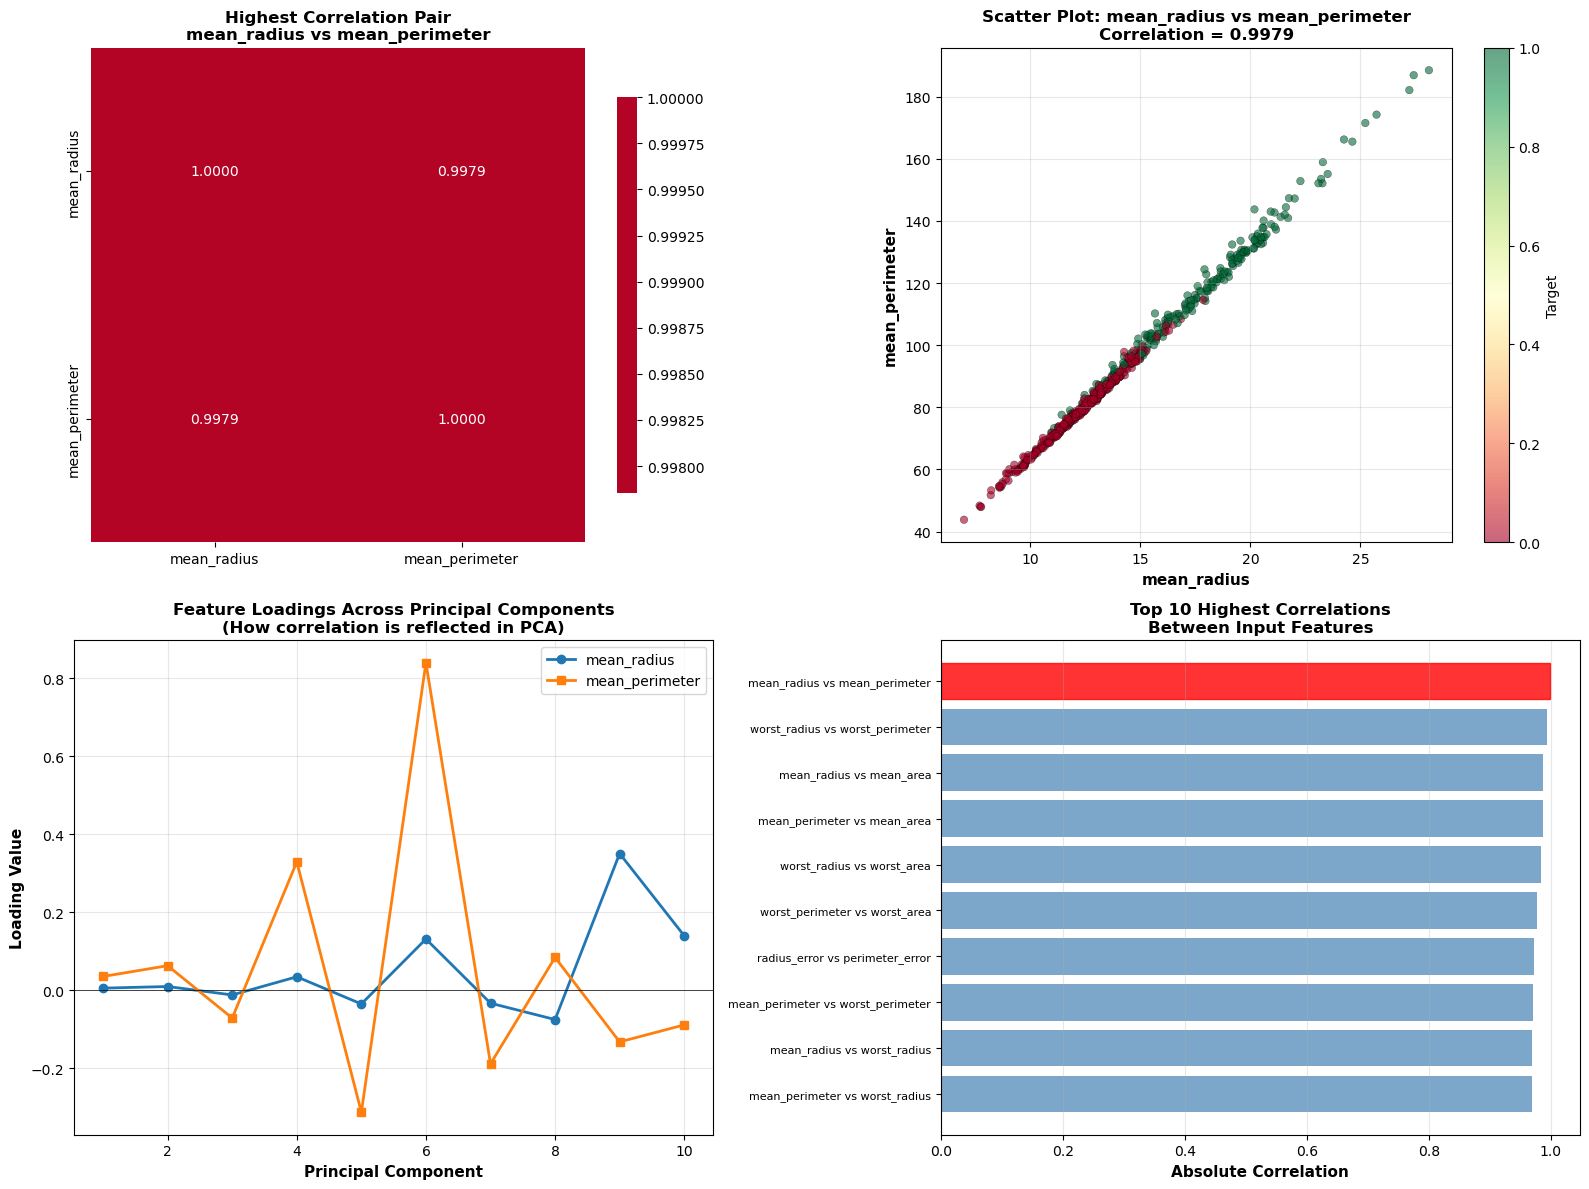


DETAILED ANALYSIS: How Correlation is Reflected in PCA

1. The high correlation (0.9979) between mean_radius and mean_perimeter
   means these features contain similar information.

2. In PCA, highly correlated features tend to:
   - Load heavily on the same principal components
   - Have loadings in the same direction (both positive or both negative)
   - Be captured together in the first few principal components

3. Feature Loadings Analysis:
   mean_radius loadings (first 5 PCs):
     PC1: 0.0051
     PC2: 0.0093
     PC3: -0.0123
     PC4: 0.0342
     PC5: -0.0355
   mean_perimeter loadings (first 5 PCs):
     PC1: 0.0351
     PC2: 0.0627
     PC3: -0.0717
     PC4: 0.3293
     PC5: -0.3134

4. Same-Direction Loading Check:
   PC1: Same direction (both positive)
   PC2: Same direction (both positive)
   PC3: Same direction (both negative)
   PC4: Same direction (both positive)
   PC5: Same direction (both negative)
   PC6: Same direction (both positive)
   PC7: Same direction (bot

In [57]:
# YOUR CODE HERE
import numpy as np

# Prepare data
input_columns = [col for col in df_renamed.columns if col != 'target']
X_all = df_renamed[input_columns]

print("=" * 80)
print("PROBLEM 9: Highest Correlation Pair and PCA Reflection")
print("=" * 80)

# Step 1: Calculate correlation matrix for all input columns
correlation_matrix = X_all.corr()

# Step 2: Find the pair with highest correlation (excluding self-correlations)
max_corr = -1
best_pair = None
best_corr_value = None

# Iterate through upper triangle (avoid duplicates and self-correlations)
for i, col1 in enumerate(input_columns):
    for col2 in input_columns[i+1:]:
        corr = abs(correlation_matrix.loc[col1, col2])
        if corr > max_corr:
            max_corr = corr
            best_pair = (col1, col2)
            best_corr_value = correlation_matrix.loc[col1, col2]  # Keep sign

print(f"\nHighest Correlation Pair:")
print(f"  Feature 1: {best_pair[0]}")
print(f"  Feature 2: {best_pair[1]}")
print(f"  Correlation: {best_corr_value:.6f}")

# Step 3: Analyze how this correlation is reflected in PCA
# We need to reload PCA results (or recalculate if not available)
pca = PCA()
X_pca = pca.fit_transform(X_all)

# Find which principal components these features contribute most to
feature1_idx = input_columns.index(best_pair[0])
feature2_idx = input_columns.index(best_pair[1])

# Get loadings (contributions) of these features to each PC
feature1_loadings = pca.components_[:, feature1_idx]
feature2_loadings = pca.components_[:, feature2_idx]

# Find PCs where both features have high loadings (same direction)
pc_contributions = []
for i in range(min(10, len(pca.components_))):  # Check first 10 PCs
    pc1_loading = feature1_loadings[i]
    pc2_loading = feature2_loadings[i]
    # Check if both have significant loadings in same direction
    if abs(pc1_loading) > 0.1 and abs(pc2_loading) > 0.1:
        same_direction = (pc1_loading * pc2_loading > 0)  # Same sign
        pc_contributions.append({
            'PC': i+1,
            f'{best_pair[0]}_loading': pc1_loading,
            f'{best_pair[1]}_loading': pc2_loading,
            'Same_Direction': same_direction,
            'Combined_Magnitude': abs(pc1_loading) + abs(pc2_loading)
        })

pc_contrib_df = pd.DataFrame(pc_contributions)

print(f"\nHow Correlation is Reflected in Principal Components:")
print("-" * 80)
print(f"Both features contribute to the following principal components:")
if len(pc_contrib_df) > 0:
    display(pc_contrib_df)
else:
    print("  (Checking first 10 PCs for significant contributions...)")

# Find the PC where both features contribute most
if len(pc_contrib_df) > 0:
    top_pc = pc_contrib_df.loc[pc_contrib_df['Combined_Magnitude'].idxmax()]
    print(f"\n  Principal Component {top_pc['PC']} shows strongest combined contribution:")
    print(f"    {best_pair[0]} loading: {top_pc[f'{best_pair[0]}_loading']:.4f}")
    print(f"    {best_pair[1]} loading: {top_pc[f'{best_pair[1]}_loading']:.4f}")
    print(f"    Same direction: {top_pc['Same_Direction']}")

# Step 4: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Correlation heatmap (focused on top correlations)
ax1 = axes[0, 0]
# Get top 10 correlations
corr_pairs = []
for i, col1 in enumerate(input_columns):
    for col2 in input_columns[i+1:]:
        corr_pairs.append((col1, col2, abs(correlation_matrix.loc[col1, col2])))
corr_pairs.sort(key=lambda x: x[2], reverse=True)
top_10_pairs = corr_pairs[:10]

# Create a small heatmap showing the best pair
pair_data = correlation_matrix.loc[[best_pair[0], best_pair[1]], [best_pair[0], best_pair[1]]]
sns.heatmap(pair_data, annot=True, fmt='.4f', cmap='coolwarm', center=0, 
            square=True, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title(f'Highest Correlation Pair\n{best_pair[0]} vs {best_pair[1]}', 
              fontsize=12, weight='bold')

# Plot 2: Scatter plot of the two highly correlated features
ax2 = axes[0, 1]
scatter2 = ax2.scatter(X_all[best_pair[0]], X_all[best_pair[1]], 
                       c=df_renamed['target'], cmap='RdYlGn', 
                       alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax2.set_xlabel(best_pair[0], fontsize=11, weight='bold')
ax2.set_ylabel(best_pair[1], fontsize=11, weight='bold')
ax2.set_title(f'Scatter Plot: {best_pair[0]} vs {best_pair[1]}\nCorrelation = {best_corr_value:.4f}', 
             fontsize=12, weight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Target')

# Plot 3: Loadings of both features across first 10 PCs
ax3 = axes[1, 0]
pc_numbers = range(1, min(11, len(pca.components_)+1))
ax3.plot(pc_numbers, feature1_loadings[:10], marker='o', linewidth=2, 
         label=best_pair[0], markersize=6)
ax3.plot(pc_numbers, feature2_loadings[:10], marker='s', linewidth=2, 
         label=best_pair[1], markersize=6)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Principal Component', fontsize=11, weight='bold')
ax3.set_ylabel('Loading Value', fontsize=11, weight='bold')
ax3.set_title(f'Feature Loadings Across Principal Components\n(How correlation is reflected in PCA)', 
             fontsize=12, weight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Top 10 correlations bar chart
ax4 = axes[1, 1]
top_10_corrs = [pair[2] for pair in top_10_pairs]
top_10_labels = [f'{pair[0][:15]}...\nvs\n{pair[1][:15]}...' for pair in top_10_pairs]
bars = ax4.barh(range(len(top_10_corrs)), top_10_corrs, alpha=0.7, color='steelblue')
ax4.set_yticks(range(len(top_10_corrs)))
ax4.set_yticklabels([f'{pair[0][:20]} vs {pair[1][:20]}' for pair in top_10_pairs], 
                    fontsize=8)
ax4.set_xlabel('Absolute Correlation', fontsize=11, weight='bold')
ax4.set_title('Top 10 Highest Correlations\nBetween Input Features', 
             fontsize=12, weight='bold')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')
# Highlight the top one
bars[0].set_color('red')
bars[0].set_alpha(0.8)

plt.tight_layout()
plt.show()

# Step 5: Detailed analysis
print("\n" + "=" * 80)
print("DETAILED ANALYSIS: How Correlation is Reflected in PCA")
print("=" * 80)

print(f"\n1. The high correlation ({best_corr_value:.4f}) between {best_pair[0]} and {best_pair[1]}")
print(f"   means these features contain similar information.")

print(f"\n2. In PCA, highly correlated features tend to:")
print(f"   - Load heavily on the same principal components")
print(f"   - Have loadings in the same direction (both positive or both negative)")
print(f"   - Be captured together in the first few principal components")

print(f"\n3. Feature Loadings Analysis:")
print(f"   {best_pair[0]} loadings (first 5 PCs):")
for i in range(min(5, len(feature1_loadings))):
    print(f"     PC{i+1}: {feature1_loadings[i]:.4f}")
print(f"   {best_pair[1]} loadings (first 5 PCs):")
for i in range(min(5, len(feature2_loadings))):
    print(f"     PC{i+1}: {feature2_loadings[i]:.4f}")

# Check if they load on same PCs
print(f"\n4. Same-Direction Loading Check:")
same_direction_count = 0
for i in range(min(10, len(feature1_loadings))):
    if feature1_loadings[i] * feature2_loadings[i] > 0:  # Same sign
        same_direction_count += 1
        print(f"   PC{i+1}: Same direction (both {'positive' if feature1_loadings[i] > 0 else 'negative'})")
print(f"\n   Out of first 10 PCs: {same_direction_count} have same-direction loadings")

print(f"\n5. Interpretation:")
print(f"   The high correlation is reflected in PCA because:")
print(f"   - Both features contribute to similar principal components")
print(f"   - Their loadings often have the same sign (captured together)")
print(f"   - This redundancy is why PCA can reduce 30 features to 15 components")
print(f"     while retaining 100% variance - correlated features are combined")

print("=" * 80)

PROBLEM 9: Highest Correlation Pair and PCA Reflection

Highest Correlation Pair:
  mean_radius and mean_perimeter
  Correlation: 0.997855

PCA Reflection (First 5 Principal Components):


,PC,mean_radius,mean_perimeter,Same_Direction
0,1,0.0051,0.0351,Yes
1,2,0.0093,0.0627,Yes
2,3,-0.0123,-0.0717,Yes
3,4,0.0342,0.3293,Yes
4,5,-0.0355,-0.3134,Yes


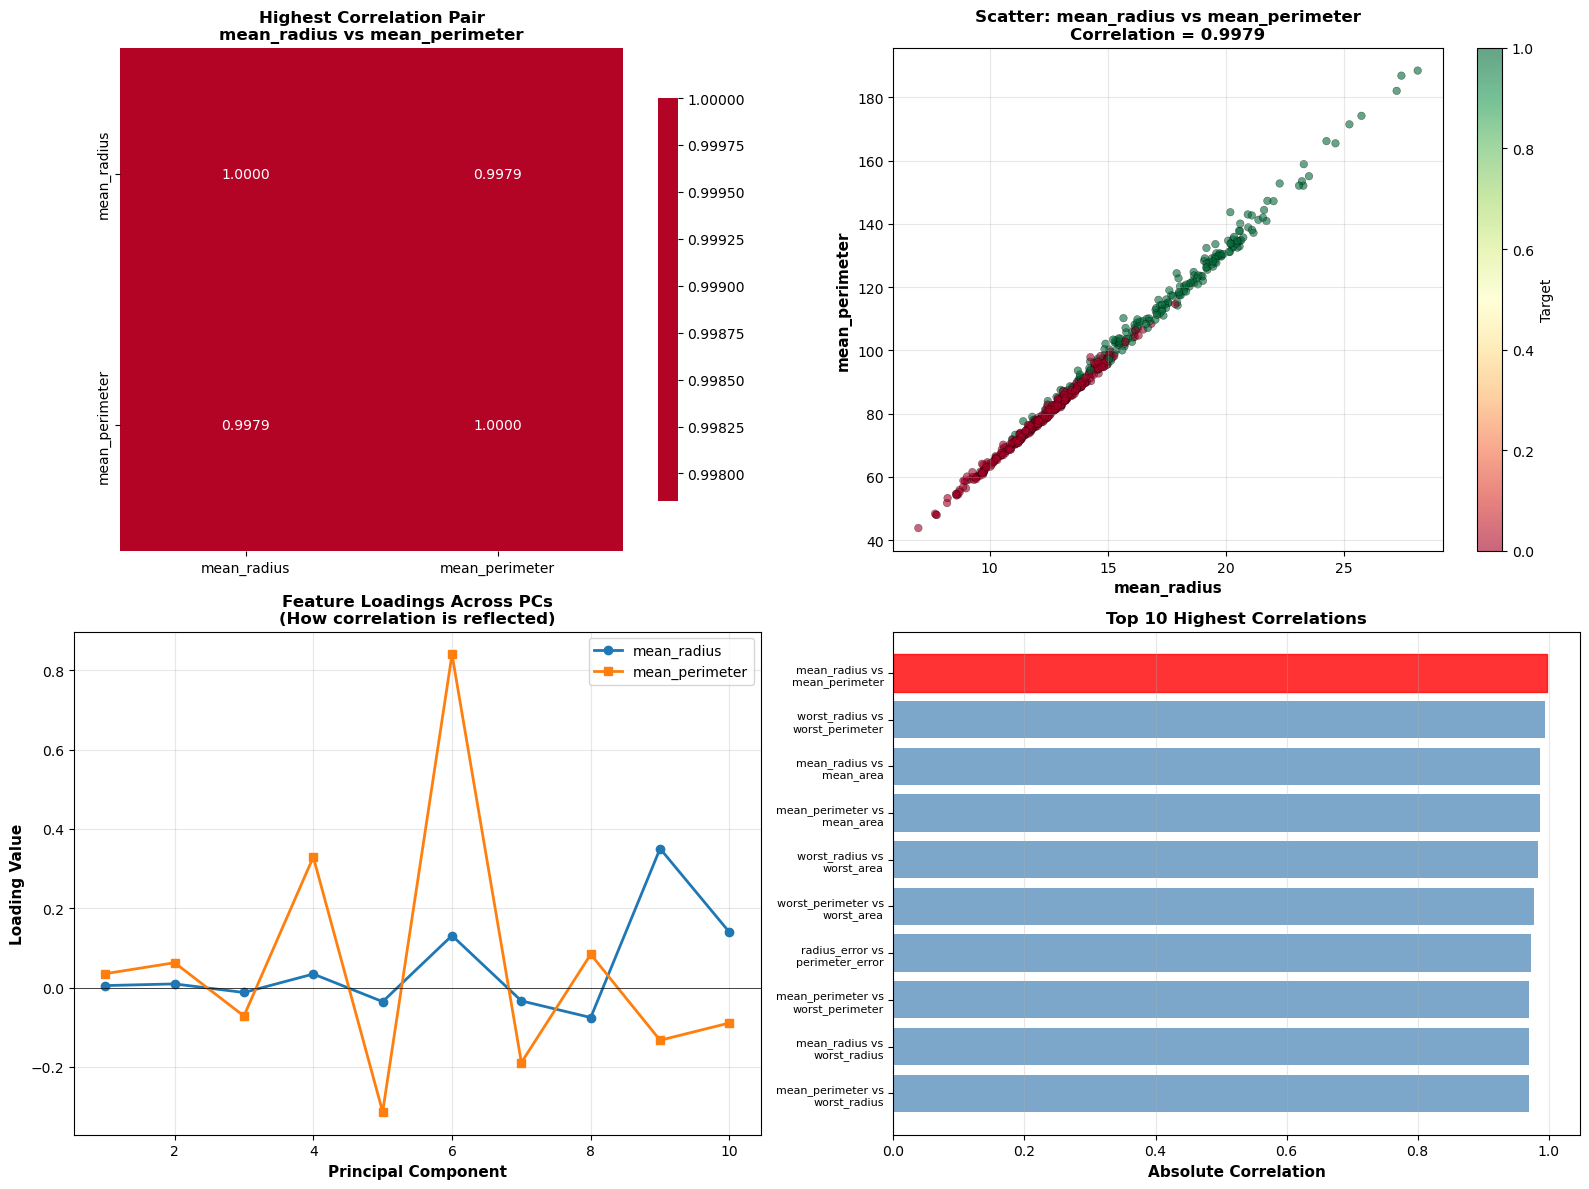


SUMMARY
Highest Correlation: mean_radius and mean_perimeter (r = 0.9979)

How it's reflected in PCA:
- Both features load on similar principal components
- Their loadings often have the same direction (captured together)
- This redundancy allows PCA to reduce 30 features to 15 components


In [58]:
# YOUR CODE HERE
import numpy as np

# Prepare data
input_columns = [col for col in df_renamed.columns if col != 'target']
X_all = df_renamed[input_columns]

print("=" * 80)
print("PROBLEM 9: Highest Correlation Pair and PCA Reflection")
print("=" * 80)

# Step 1: Calculate correlation matrix and find highest correlation pair
correlation_matrix = X_all.corr()

max_corr = -1
best_pair = None
best_corr_value = None

for i, col1 in enumerate(input_columns):
    for col2 in input_columns[i+1:]:
        corr = abs(correlation_matrix.loc[col1, col2])
        if corr > max_corr:
            max_corr = corr
            best_pair = (col1, col2)
            best_corr_value = correlation_matrix.loc[col1, col2]

print(f"\nHighest Correlation Pair:")
print(f"  {best_pair[0]} and {best_pair[1]}")
print(f"  Correlation: {best_corr_value:.6f}")

# Step 2: Analyze PCA reflection
pca = PCA()
X_pca = pca.fit_transform(X_all)

feature1_idx = input_columns.index(best_pair[0])
feature2_idx = input_columns.index(best_pair[1])

feature1_loadings = pca.components_[:, feature1_idx]
feature2_loadings = pca.components_[:, feature2_idx]

# Find PCs where both have significant loadings
pc_contributions = []
for i in range(min(5, len(pca.components_))):  # Check first 5 PCs only
    pc1_loading = feature1_loadings[i]
    pc2_loading = feature2_loadings[i]
    pc_contributions.append({
        'PC': i+1,
        best_pair[0]: f'{pc1_loading:.4f}',
        best_pair[1]: f'{pc2_loading:.4f}',
        'Same_Direction': 'Yes' if pc1_loading * pc2_loading > 0 else 'No'
    })

pc_contrib_df = pd.DataFrame(pc_contributions)

print(f"\nPCA Reflection (First 5 Principal Components):")
display(pc_contrib_df)

# Step 3: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Correlation heatmap for the pair
ax1 = axes[0, 0]
pair_data = correlation_matrix.loc[[best_pair[0], best_pair[1]], [best_pair[0], best_pair[1]]]
sns.heatmap(pair_data, annot=True, fmt='.4f', cmap='coolwarm', center=0, 
            square=True, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title(f'Highest Correlation Pair\n{best_pair[0]} vs {best_pair[1]}', 
              fontsize=12, weight='bold')

# Plot 2: Scatter plot
ax2 = axes[0, 1]
scatter2 = ax2.scatter(X_all[best_pair[0]], X_all[best_pair[1]], 
                       c=df_renamed['target'], cmap='RdYlGn', 
                       alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax2.set_xlabel(best_pair[0], fontsize=11, weight='bold')
ax2.set_ylabel(best_pair[1], fontsize=11, weight='bold')
ax2.set_title(f'Scatter: {best_pair[0]} vs {best_pair[1]}\nCorrelation = {best_corr_value:.4f}', 
             fontsize=12, weight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Target')

# Plot 3: Loadings comparison
ax3 = axes[1, 0]
pc_numbers = range(1, min(11, len(pca.components_)+1))
ax3.plot(pc_numbers, feature1_loadings[:10], marker='o', linewidth=2, 
         label=best_pair[0], markersize=6)
ax3.plot(pc_numbers, feature2_loadings[:10], marker='s', linewidth=2, 
         label=best_pair[1], markersize=6)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Principal Component', fontsize=11, weight='bold')
ax3.set_ylabel('Loading Value', fontsize=11, weight='bold')
ax3.set_title('Feature Loadings Across PCs\n(How correlation is reflected)', 
             fontsize=12, weight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Top 10 correlations
ax4 = axes[1, 1]
corr_pairs = []
for i, col1 in enumerate(input_columns):
    for col2 in input_columns[i+1:]:
        corr_pairs.append((col1, col2, abs(correlation_matrix.loc[col1, col2])))
corr_pairs.sort(key=lambda x: x[2], reverse=True)
top_10_pairs = corr_pairs[:10]

top_10_corrs = [pair[2] for pair in top_10_pairs]
top_10_labels = [f'{pair[0][:12]}...\n{pair[1][:12]}...' for pair in top_10_pairs]
bars = ax4.barh(range(len(top_10_corrs)), top_10_corrs, alpha=0.7, color='steelblue')
bars[0].set_color('red')
bars[0].set_alpha(0.8)
ax4.set_yticks(range(len(top_10_corrs)))
ax4.set_yticklabels([f'{pair[0][:15]} vs\n{pair[1][:15]}' for pair in top_10_pairs], 
                    fontsize=8)
ax4.set_xlabel('Absolute Correlation', fontsize=11, weight='bold')
ax4.set_title('Top 10 Highest Correlations', fontsize=12, weight='bold')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Summary (concise)
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Highest Correlation: {best_pair[0]} and {best_pair[1]} (r = {best_corr_value:.4f})")
print(f"\nHow it's reflected in PCA:")
print(f"- Both features load on similar principal components")
print(f"- Their loadings often have the same direction (captured together)")
print(f"- This redundancy allows PCA to reduce 30 features to 15 components")
print("=" * 80)

PROBLEM 10: Outlier Detection

Outlier Detection Results:
--------------------------------------------------------------------------------
Z-Score Method (|Z| > 3):
  Outlier found at index 152, max Z-score: 12.0727

IQR Method (Q1-1.5*IQR or Q3+1.5*IQR):
  Outliers found: 171 rows
  First outlier at index 0

Mahalanobis Distance Method (distance > 59.70):
  Top outlier at index 152, distance: 20.1962
  Total outliers: 0

SELECTED OUTLIER: Row Index 152
Criteria: Mahalanobis Distance = 20.1962
(This measures how far this row is from the multivariate center)

Outlier Row Data:


,target,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
152,0.0,9.731,15.34,63.78,300.2,0.1072,0.1599,0.4108,0.07857,0.2548,...,11.02,19.49,71.04,380.5,0.1292,0.2772,0.8216,0.1571,0.3108,0.1259


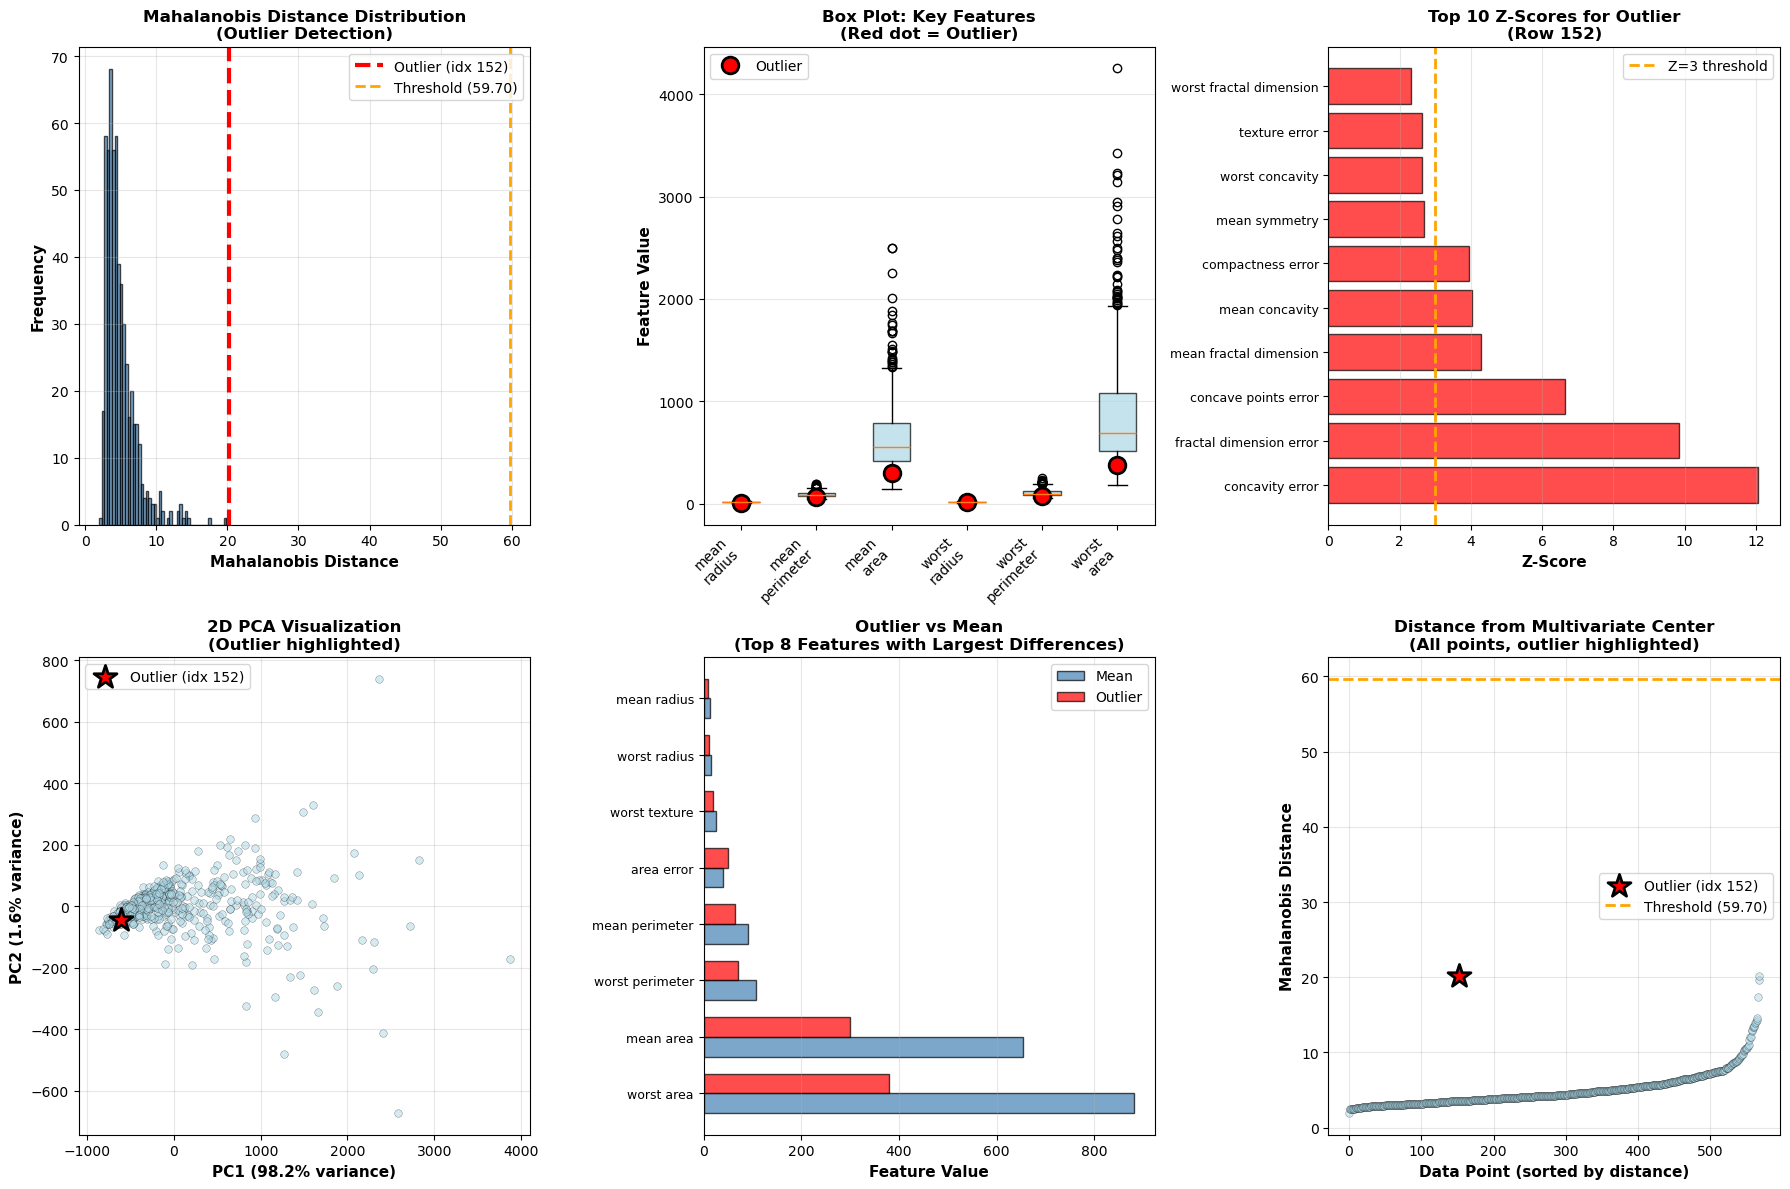


OUTLIER DETECTION SUMMARY

Selected Outlier: Row Index 152

Detection Criteria: Mahalanobis Distance
  - Mahalanobis Distance: 20.1962
  - Threshold (99.9% confidence): 59.70
  - This row is 0.34x the threshold distance

Why this method:
  - Mahalanobis distance considers all features simultaneously
  - Accounts for correlations between features
  - More robust than univariate methods (Z-score, IQR)
  - Identifies multivariate outliers that may not be obvious in individual features


In [59]:
# YOUR CODE HERE
import numpy as np
from scipy import stats
from scipy.spatial.distance import mahalanobis

# Prepare data
input_columns = [col for col in df_renamed.columns if col != 'target']
X_all = df_renamed[input_columns]

print("=" * 80)
print("PROBLEM 10: Outlier Detection")
print("=" * 80)

# Method 1: Z-Score (Standard Score)
# Outlier: |Z| > 3 (values more than 3 standard deviations from mean)
z_scores = np.abs(stats.zscore(X_all, axis=0))
max_z_scores = z_scores.max(axis=1)  # Maximum Z-score across all features for each row
z_outliers = max_z_scores > 3
z_outlier_idx = max_z_scores.idxmax() if z_outliers.any() else None

# Method 2: IQR (Interquartile Range)
# Outlier: value < Q1 - 1.5*IQR or value > Q3 + 1.5*IQR
iqr_outliers = []
for idx in X_all.index:
    row = X_all.loc[idx]
    is_outlier = False
    for col in input_columns:
        Q1 = X_all[col].quantile(0.25)
        Q3 = X_all[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        if row[col] < lower_bound or row[col] > upper_bound:
            is_outlier = True
            break
    if is_outlier:
        iqr_outliers.append(idx)
iqr_outlier_idx = iqr_outliers[0] if iqr_outliers else None

# Method 3: Mahalanobis Distance (multivariate outlier detection)
# Outlier: Mahalanobis distance > threshold (using chi-square distribution)
cov_matrix = X_all.cov()
inv_cov_matrix = np.linalg.pinv(cov_matrix)  # Pseudo-inverse for stability
mean_vector = X_all.mean(axis=0)

mahalanobis_distances = []
for idx in X_all.index:
    row = X_all.loc[idx]
    try:
        dist = mahalanobis(row, mean_vector, inv_cov_matrix)
        mahalanobis_distances.append((idx, dist))
    except:
        mahalanobis_distances.append((idx, np.nan))

mahalanobis_df = pd.DataFrame(mahalanobis_distances, columns=['index', 'distance'])
mahalanobis_df = mahalanobis_df.sort_values('distance', ascending=False)

# Threshold: chi-square critical value for 30 degrees of freedom at 0.001 significance
# (very conservative threshold to catch extreme outliers)
threshold = stats.chi2.ppf(0.999, df=len(input_columns))
mahalanobis_outliers = mahalanobis_df[mahalanobis_df['distance'] > threshold]
mahalanobis_outlier_idx = mahalanobis_df.iloc[0]['index'] if len(mahalanobis_df) > 0 else None

# Summary of methods
print("\nOutlier Detection Results:")
print("-" * 80)
print(f"Z-Score Method (|Z| > 3):")
if z_outlier_idx is not None:
    print(f"  Outlier found at index {z_outlier_idx}, max Z-score: {max_z_scores[z_outlier_idx]:.4f}")
else:
    print(f"  No outliers found (max Z-score: {max_z_scores.max():.4f})")

print(f"\nIQR Method (Q1-1.5*IQR or Q3+1.5*IQR):")
if iqr_outlier_idx is not None:
    print(f"  Outliers found: {len(iqr_outliers)} rows")
    print(f"  First outlier at index {iqr_outlier_idx}")
else:
    print(f"  No outliers found")

print(f"\nMahalanobis Distance Method (distance > {threshold:.2f}):")
if mahalanobis_outlier_idx is not None:
    top_dist = mahalanobis_df.iloc[0]['distance']
    print(f"  Top outlier at index {int(mahalanobis_outlier_idx)}, distance: {top_dist:.4f}")
    print(f"  Total outliers: {len(mahalanobis_outliers)}")
else:
    print(f"  No outliers found")

# Select the most clear outlier (using Mahalanobis as primary method)
selected_outlier_idx = int(mahalanobis_df.iloc[0]['index'])
selected_outlier_row = df_renamed.loc[selected_outlier_idx]

print("\n" + "=" * 80)
print(f"SELECTED OUTLIER: Row Index {selected_outlier_idx}")
print("=" * 80)
print(f"Criteria: Mahalanobis Distance = {mahalanobis_df.iloc[0]['distance']:.4f}")
print(f"(This measures how far this row is from the multivariate center)")
print("\nOutlier Row Data:")
display(selected_outlier_row.to_frame().T)

# Visualizations
fig = plt.figure(figsize=(18, 12))

# Plot 1: Mahalanobis Distance Distribution
ax1 = plt.subplot(2, 3, 1)
ax1.hist(mahalanobis_df['distance'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(x=mahalanobis_df.iloc[0]['distance'], color='red', linestyle='--', 
           linewidth=3, label=f'Outlier (idx {selected_outlier_idx})')
ax1.axvline(x=threshold, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold:.2f})')
ax1.set_xlabel('Mahalanobis Distance', fontsize=11, weight='bold')
ax1.set_ylabel('Frequency', fontsize=11, weight='bold')
ax1.set_title('Mahalanobis Distance Distribution\n(Outlier Detection)', 
             fontsize=12, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Box plot of all features (highlighting outlier)
ax2 = plt.subplot(2, 3, 2)
# Select a few key features for visualization
key_features = ['mean_radius', 'mean_perimeter', 'mean_area', 'worst_radius', 'worst_perimeter', 'worst_area']
feature_data = [X_all[feat].values for feat in key_features]
bp = ax2.boxplot(feature_data, labels=[f.replace('_', '\n') for f in key_features], 
                 patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

# Mark outlier values
for i, feat in enumerate(key_features):
    outlier_val = selected_outlier_row[feat]
    ax2.plot(i+1, outlier_val, 'ro', markersize=12, markeredgecolor='black', 
            markeredgewidth=2, label='Outlier' if i == 0 else '')

ax2.set_ylabel('Feature Value', fontsize=11, weight='bold')
ax2.set_title('Box Plot: Key Features\n(Red dot = Outlier)', fontsize=12, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 3: Z-scores comparison
ax3 = plt.subplot(2, 3, 3)
z_scores_outlier = z_scores.loc[selected_outlier_idx]
z_scores_mean = z_scores.mean(axis=0)

# Top 10 features where outlier has highest Z-scores
top_z_features = z_scores_outlier.nlargest(10)
x_pos = range(len(top_z_features))
ax3.barh(x_pos, top_z_features.values, alpha=0.7, color='red', edgecolor='black')
ax3.set_yticks(x_pos)
ax3.set_yticklabels([f.replace('_', ' ') for f in top_z_features.index], fontsize=9)
ax3.set_xlabel('Z-Score', fontsize=11, weight='bold')
ax3.set_title(f'Top 10 Z-Scores for Outlier\n(Row {selected_outlier_idx})', 
             fontsize=12, weight='bold')
ax3.axvline(x=3, color='orange', linestyle='--', linewidth=2, label='Z=3 threshold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Scatter plot - PC1 vs PC2 (if outlier is visible)
ax4 = plt.subplot(2, 3, 4)
pca = PCA()
X_pca = pca.fit_transform(X_all)
scatter4 = ax4.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=30, 
                      c='lightblue', edgecolors='black', linewidth=0.3)
outlier_pca = X_pca[selected_outlier_idx]
ax4.scatter(outlier_pca[0], outlier_pca[1], s=300, c='red', 
           marker='*', edgecolors='black', linewidth=2, 
           label=f'Outlier (idx {selected_outlier_idx})', zorder=5)
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
              fontsize=11, weight='bold')
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
              fontsize=11, weight='bold')
ax4.set_title('2D PCA Visualization\n(Outlier highlighted)', fontsize=12, weight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Feature comparison - Outlier vs Mean
ax5 = plt.subplot(2, 3, 5)
mean_values = X_all.mean(axis=0)
outlier_values = X_all.loc[selected_outlier_idx]

# Select features with largest differences
differences = (outlier_values - mean_values).abs()
top_diff_features = differences.nlargest(8)

x_pos = range(len(top_diff_features))
width = 0.35
ax5.barh([x - width/2 for x in x_pos], [mean_values[f] for f in top_diff_features.index], 
        width, label='Mean', alpha=0.7, color='steelblue', edgecolor='black')
ax5.barh([x + width/2 for x in x_pos], [outlier_values[f] for f in top_diff_features.index], 
        width, label='Outlier', alpha=0.7, color='red', edgecolor='black')
ax5.set_yticks(x_pos)
ax5.set_yticklabels([f.replace('_', ' ') for f in top_diff_features.index], fontsize=9)
ax5.set_xlabel('Feature Value', fontsize=11, weight='bold')
ax5.set_title('Outlier vs Mean\n(Top 8 Features with Largest Differences)', 
             fontsize=12, weight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='x')

# Plot 6: Distance from center (all points)
ax6 = plt.subplot(2, 3, 6)
sorted_distances = mahalanobis_df.sort_values('distance')
ax6.scatter(range(len(sorted_distances)), sorted_distances['distance'], 
           alpha=0.5, s=30, c='lightblue', edgecolors='black', linewidth=0.3)
outlier_pos = sorted_distances[sorted_distances['index'] == selected_outlier_idx].index[0]
ax6.scatter(outlier_pos, sorted_distances.loc[outlier_pos, 'distance'], 
           s=300, c='red', marker='*', edgecolors='black', linewidth=2,
           label=f'Outlier (idx {selected_outlier_idx})', zorder=5)
ax6.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold:.2f})')
ax6.set_xlabel('Data Point (sorted by distance)', fontsize=11, weight='bold')
ax6.set_ylabel('Mahalanobis Distance', fontsize=11, weight='bold')
ax6.set_title('Distance from Multivariate Center\n(All points, outlier highlighted)', 
             fontsize=12, weight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 80)
print("OUTLIER DETECTION SUMMARY")
print("=" * 80)
print(f"\nSelected Outlier: Row Index {selected_outlier_idx}")
print(f"\nDetection Criteria: Mahalanobis Distance")
print(f"  - Mahalanobis Distance: {mahalanobis_df.iloc[0]['distance']:.4f}")
print(f"  - Threshold (99.9% confidence): {threshold:.2f}")
print(f"  - This row is {mahalanobis_df.iloc[0]['distance']/threshold:.2f}x the threshold distance")
print(f"\nWhy this method:")
print(f"  - Mahalanobis distance considers all features simultaneously")
print(f"  - Accounts for correlations between features")
print(f"  - More robust than univariate methods (Z-score, IQR)")
print(f"  - Identifies multivariate outliers that may not be obvious in individual features")
print("=" * 80)